# Polymer Informatics Atlas

## Notebook 06 — Interpretation and Final Polymer Atlas

### Scientific objective

The preceding notebooks established:

- a curated and chemically audited polymer dataset;
- validated structural representations;
- property-specific predictive models;
- chemistry-aware generalization limits;
- shared-learning behaviour;
- and calibrated predictive-reliability information.

Notebook 06 integrates these results into a chemically interpretable Polymer Informatics Atlas.

The central question is no longer:

> **Which model gives the highest predictive score?**

Instead, this notebook asks:

> **What chemical and structural information drives polymer-property prediction, where in chemical space are these relationships expressed, and how reliably can they be used?**

The analysis therefore focuses on five complementary objectives.

### 1. Property-specific model interpretation

Determine which global polymer descriptors and local structural environments are associated with prediction of:

- glass-transition temperature (Tg);
- fractional free volume (FFV);
- thermal conductivity (Tc);
- Density;
- radius of gyration (Rg).

### 2. Representation-level interpretation

Determine whether each property depends primarily on:

- broad compositional and structural descriptors;
- local molecular environments;
- or a combination of both.

### 3. Chemical decoding of fingerprint features

Important Morgan fingerprint features are mapped back to representative atom-centred environments.

Because hashed fingerprints can map more than one chemical environment to the same feature index, interpretation explicitly quantifies feature ambiguity rather than assigning unsupported chemical labels.

### 4. Integrated polymer-property landscapes

Polymer chemical space is visualized together with:

- measured property values;
- prediction errors;
- chemical-domain support;
- and predictive uncertainty.

The resulting maps form the visual Polymer Informatics Atlas.

### 5. Cross-property design space

Where multiple properties are available for the same polymers, their relationships and trade-offs are examined without assuming that a single direction is universally desirable.

Illustrative multi-objective design analyses are therefore presented as application-dependent scenarios rather than universal rankings of polymer quality.

### Methodological principle

Notebook 06 is an interpretation and synthesis notebook.

The predictive model families, representations, hyperparameters, holdout decisions, chemistry-aware evaluations, and uncertainty procedures established in previous notebooks remain frozen.

Any model reconstruction performed here is solely for interpretation of already-selected models and is not used for further model selection.

In [ ]:
# ============================================================
# Upload frozen project artifacts
# ============================================================

from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")

for filename in uploaded:
    print(f"  {filename}")

Saving polymer_atlas_notebook05_outputs.zip to polymer_atlas_notebook05_outputs.zip
Saving polymer_atlas_notebook04_outputs.zip to polymer_atlas_notebook04_outputs.zip
Saving polymer_atlas_notebook03_outputs.zip to polymer_atlas_notebook03_outputs.zip
Saving polymer_atlas_notebook02_outputs.zip to polymer_atlas_notebook02_outputs.zip

Uploaded files:
  polymer_atlas_notebook05_outputs.zip
  polymer_atlas_notebook04_outputs.zip
  polymer_atlas_notebook03_outputs.zip
  polymer_atlas_notebook02_outputs.zip


In [ ]:
# ============================================================
# Extract Notebook 02–05 artifacts
# ============================================================

from pathlib import Path
import zipfile
import json
import numpy as np
import pandas as pd

BASE_DIR = Path("/content")

artifact_specs = {

    "nb02": {
        "zip":
            BASE_DIR
            / "polymer_atlas_notebook02_outputs.zip",

        "dir":
            BASE_DIR
            / "polymer_atlas_notebook02_outputs"
    },

    "nb03": {
        "zip":
            BASE_DIR
            / "polymer_atlas_notebook03_outputs.zip",

        "dir":
            BASE_DIR
            / "polymer_atlas_notebook03_outputs"
    },

    "nb04": {
        "zip":
            BASE_DIR
            / "polymer_atlas_notebook04_outputs.zip",

        "dir":
            BASE_DIR
            / "polymer_atlas_notebook04_outputs"
    },

    "nb05": {
        "zip":
            BASE_DIR
            / "polymer_atlas_notebook05_outputs.zip",

        "dir":
            BASE_DIR
            / "polymer_atlas_notebook05_outputs"
    }
}


for label, spec in artifact_specs.items():

    spec["dir"].mkdir(
        exist_ok=True
    )

    with zipfile.ZipFile(
        spec["zip"],
        "r"
    ) as z:

        z.extractall(
            spec["dir"]
        )

    print(
        f"{label.upper()} extracted -> "
        f"{spec['dir']}"
    )


NB02_DIR = artifact_specs["nb02"]["dir"]
NB03_DIR = artifact_specs["nb03"]["dir"]
NB04_DIR = artifact_specs["nb04"]["dir"]
NB05_DIR = artifact_specs["nb05"]["dir"]

NB02 extracted -> /content/polymer_atlas_notebook02_outputs
NB03 extracted -> /content/polymer_atlas_notebook03_outputs
NB04 extracted -> /content/polymer_atlas_notebook04_outputs
NB05 extracted -> /content/polymer_atlas_notebook05_outputs


In [ ]:
# ============================================================
# Load frozen Notebook 02 data
# ============================================================

X_interpretable = np.load(
    NB02_DIR
    / "X_interpretable.npy"
)

X_morgan = np.load(
    NB02_DIR
    / "X_morgan_count_r4.npy"
)

X_hybrid = np.load(
    NB02_DIR
    / "X_hybrid.npy"
)

metadata = pd.read_csv(
    NB02_DIR
    / "polymer_model_metadata.csv"
)


target_columns = [
    "Tg",
    "FFV",
    "Tc",
    "Density",
    "Rg"
]


print("CORE POLYMER DATA")
print("=" * 75)

print(
    f"Metadata:       {metadata.shape}"
)

print(
    f"Interpretable:  {X_interpretable.shape}"
)

print(
    f"Morgan r4:      {X_morgan.shape}"
)

print(
    f"Hybrid:         {X_hybrid.shape}"
)

CORE POLYMER DATA
Metadata:       (7973, 8)
Interpretable:  (7973, 36)
Morgan r4:      (7973, 2048)
Hybrid:         (7973, 2084)


In [ ]:
# ============================================================
# Load representation feature names
# ============================================================

interpretable_names_df = pd.read_csv(
    NB02_DIR
    / "interpretable_feature_names.csv"
)

morgan_names_df = pd.read_csv(
    NB02_DIR
    / "morgan_r4_feature_names.csv"
)

hybrid_names_df = pd.read_csv(
    NB02_DIR
    / "hybrid_feature_names.csv"
)


def extract_feature_names(
    dataframe
):

    preferred_columns = [
        "feature_name",
        "Feature",
        "feature",
        "name"
    ]

    for column in preferred_columns:

        if column in dataframe.columns:

            return (
                dataframe[column]
                .astype(str)
                .tolist()
            )

    # Fall back to the final column if
    # no expected label is present.
    return (
        dataframe.iloc[:, -1]
        .astype(str)
        .tolist()
    )


interpretable_feature_names = (
    extract_feature_names(
        interpretable_names_df
    )
)

morgan_feature_names = (
    extract_feature_names(
        morgan_names_df
    )
)

hybrid_feature_names = (
    extract_feature_names(
        hybrid_names_df
    )
)


print("FEATURE NAMES")
print("=" * 75)

print(
    f"Interpretable names: "
    f"{len(interpretable_feature_names)}"
)

print(
    f"Morgan names:        "
    f"{len(morgan_feature_names)}"
)

print(
    f"Hybrid names:        "
    f"{len(hybrid_feature_names)}"
)


assert (
    len(interpretable_feature_names)
    ==
    X_interpretable.shape[1]
)

assert (
    len(morgan_feature_names)
    ==
    X_morgan.shape[1]
)

assert (
    len(hybrid_feature_names)
    ==
    X_hybrid.shape[1]
)

print(
    "\nFeature-name alignment: PASSED"
)

FEATURE NAMES
Interpretable names: 36
Morgan names:        2048
Hybrid names:        2084

Feature-name alignment: PASSED


In [ ]:
interpretable_feature_table = pd.DataFrame({
    "Feature_index":
        np.arange(
            len(
                interpretable_feature_names
            )
        ),

    "Feature_name":
        interpretable_feature_names
})


display(
    interpretable_feature_table
)

,Feature_index,Feature_name
0,0,n_connection_points
1,1,n_heavy_atoms
2,2,n_C
3,3,n_N
4,4,n_O
5,5,n_S
6,6,n_halogen
7,7,n_hetero
8,8,n_aromatic
9,9,n_rings


In [ ]:
# ============================================================
# Notebook 03 — frozen predictive baselines
# ============================================================

final_holdout_results = pd.read_csv(
    NB03_DIR
    / "final_holdout_results.csv"
)

frozen_target_splits = pd.read_csv(
    NB03_DIR
    / "frozen_target_splits.csv"
)

holdout_residual_summary = pd.read_csv(
    NB03_DIR
    / "holdout_residual_summary.csv"
)

holdout_error_concentration = pd.read_csv(
    NB03_DIR
    / "holdout_error_concentration.csv"
)


with open(
    NB03_DIR
    / "notebook03_model_config.json",
    "r"
) as f:

    notebook03_config = json.load(f)


print("NOTEBOOK 03 EVIDENCE")
print("=" * 75)

display(
    final_holdout_results.round(4)
)

NOTEBOOK 03 EVIDENCE


,Target,Model,Representation,Train_n,Test_n,Test_R2,Test_MAE,Test_RMSE
0,Tg,ExtraTreesRegressor,Hybrid,408,103,0.6077,54.7176,69.0041
1,FFV,HistGradientBoostingRegressor,Hybrid,5624,1406,0.7036,0.0067,0.0164
2,Tc,HistGradientBoostingRegressor,Hybrid,589,148,0.8246,0.0249,0.0371
3,Density,Pipeline,Interpretable,490,123,0.9201,0.0275,0.0413
4,Rg,HistGradientBoostingRegressor,Morgan_r4,491,123,0.7026,1.6985,2.6170


In [ ]:
# ============================================================
# Notebook 04 — chemical generalization
# ============================================================

chemical_similarity_summary = pd.read_csv(
    NB04_DIR
    / "chemical_similarity_summary.csv"
)

novelty_generalization_penalty = pd.read_csv(
    NB04_DIR
    / "novelty_generalization_penalty.csv"
)

partial_similarity_error = pd.read_csv(
    NB04_DIR
    / "partial_similarity_error_correlations.csv"
)

random_vs_chemistry_performance = pd.read_csv(
    NB04_DIR
    / "random_vs_chemistry_performance.csv"
)

bootstrap_chemistry_performance = pd.read_csv(
    NB04_DIR
    / "bootstrap_performance_summary.csv"
)


print("NOTEBOOK 04 EVIDENCE")
print("=" * 75)

display(
    novelty_generalization_penalty
    .round(4)
)

NOTEBOOK 04 EVIDENCE


,Target,Novel_n,Familiar_n,Novel_Mean_NAE,Familiar_Mean_NAE,Novelty_Penalty_Ratio
0,Tg,65,9,0.4886,0.5920,0.8253
1,FFV,200,816,0.4220,0.1584,2.6647
2,Tc,25,70,0.4269,0.3066,1.3921
3,Density,28,48,0.2929,0.1095,2.6750
4,Rg,34,39,0.5671,0.2696,2.1033


In [ ]:
# ============================================================
# Notebook 05 — shared learning and reliability
# ============================================================

three_way_learning_summary = pd.read_csv(
    NB05_DIR
    / "three_way_learning_summary.csv"
)

paired_transfer_summary = pd.read_csv(
    NB05_DIR
    / "paired_transfer_robustness_summary.csv"
)

ensemble_point_performance = pd.read_csv(
    NB05_DIR
    / "ensemble_point_performance.csv"
)

uncertainty_error_summary = pd.read_csv(
    NB05_DIR
    / "ensemble_uncertainty_error_correlations.csv"
)

conformal_summary = pd.read_csv(
    NB05_DIR
    / "absolute_conformal_test_summary.csv"
)

reliability_signal_complementarity = pd.read_csv(
    NB05_DIR
    / "reliability_signal_complementarity.csv"
)

selective_prediction_gain = pd.read_csv(
    NB05_DIR
    / "selective_prediction_error_reduction.csv"
)

coverage_uncertainty = pd.read_csv(
    NB05_DIR
    / "conformal_coverage_uncertainty.csv"
)


print("NOTEBOOK 05 EVIDENCE")
print("=" * 75)

display(
    three_way_learning_summary
    .round(4)
)

NOTEBOOK 05 EVIDENCE


,Target,Learning,R2_mean,R2_std,MAE_mean,RMSE_mean
0,Density,CompleteCaseMultitask,0.5075,0.0361,0.0425,0.0958
1,Density,Multitask,0.5425,0.0459,0.0390,0.0922
2,Density,SingleTask,0.5298,0.0835,0.0386,0.0933
3,Rg,CompleteCaseMultitask,0.6840,0.0218,1.7838,2.7576
4,Rg,Multitask,0.7264,0.0146,1.6485,2.5664
5,Rg,SingleTask,0.7177,0.0094,1.6869,2.6074
6,Tc,CompleteCaseMultitask,0.7562,0.0115,0.0290,0.0412
7,Tc,Multitask,0.7739,0.0097,0.0278,0.0396
8,Tc,SingleTask,0.7728,0.0124,0.0280,0.0397


## Final Cross-Notebook Integrity Audit

Notebook 06 integrates outputs generated independently across several modelling stages.

Before interpretation begins, the project state is checked to ensure that:

- the polymer population remains unchanged;
- the frozen feature matrices retain their expected dimensions;
- polymer identifiers remain unique;
- target counts remain preserved;
- feature-name files align exactly with their matrices;
- and final Notebook 03–05 result tables are available.

Interpretation begins only after this cross-notebook integrity check passes.

In [ ]:
# ============================================================
# Final cross-notebook integrity audit
# ============================================================

expected_target_counts = {
    "Tg": 511,
    "FFV": 7030,
    "Tc": 737,
    "Density": 613,
    "Rg": 614
}


assert len(metadata) == 7973

assert metadata["id"].is_unique

assert X_interpretable.shape == (
    7973,
    36
)

assert X_morgan.shape == (
    7973,
    2048
)

assert X_hybrid.shape == (
    7973,
    2084
)

assert np.isfinite(
    X_interpretable
).all()

assert np.isfinite(
    X_morgan
).all()

assert np.isfinite(
    X_hybrid
).all()


for target, expected_count in (
    expected_target_counts.items()
):

    observed_count = int(
        metadata[target]
        .notna()
        .sum()
    )

    assert (
        observed_count
        ==
        expected_count
    )


assert len(
    interpretable_feature_names
) == 36

assert len(
    morgan_feature_names
) == 2048

assert len(
    hybrid_feature_names
) == 2084


print("NOTEBOOK 06 ENTRY AUDIT")
print("=" * 80)

print(
    "Polymer population:          "
    "7,973 — PASSED"
)

print(
    "Unique polymer IDs:          "
    "PASSED"
)

print(
    "Representation dimensions:   "
    "PASSED"
)

print(
    "Numerical feature integrity: "
    "PASSED"
)

print(
    "Target counts:               "
    "PASSED"
)

print(
    "Feature-name alignment:      "
    "PASSED"
)

print(
    "Cross-notebook evidence:     "
    "LOADED"
)

print(
    "\nNotebook 06 entry audit: PASSED"
)

NOTEBOOK 06 ENTRY AUDIT
Polymer population:          7,973 — PASSED
Unique polymer IDs:          PASSED
Representation dimensions:   PASSED
Numerical feature integrity: PASSED
Target counts:               PASSED
Feature-name alignment:      PASSED
Cross-notebook evidence:     LOADED

Notebook 06 entry audit: PASSED


## Integrated Property Evidence

Each polymer property has accumulated several forms of evidence across the previous notebooks.

These include:

- random-split predictive performance;
- preferred structural representation;
- chemistry-aware novelty effects;
- explicit chemistry-separated stress-test behaviour;
- and, where available, prediction-level reliability information.

The purpose of the following table is not to collapse these results into a single score.

Instead, it provides a compact evidence map showing that different polymer properties require different representations and different definitions of predictive reliability.

In [ ]:
# ============================================================
# Integrated property evidence table
# ============================================================

property_evidence_rows = []


for target in target_columns:

    nb03_row = (
        final_holdout_results[
            final_holdout_results[
                "Target"
            ] == target
        ]
        .iloc[0]
    )

    novelty_row = (
        novelty_generalization_penalty[
            novelty_generalization_penalty[
                "Target"
            ] == target
        ]
        .iloc[0]
    )

    partial_row = (
        partial_similarity_error[
            partial_similarity_error[
                "Target"
            ] == target
        ]
        .iloc[0]
    )

    chemistry_row = (
        random_vs_chemistry_performance[
            random_vs_chemistry_performance[
                "Target"
            ] == target
        ]
        .iloc[0]
    )


    row = {
        "Target":
            target,

        "Final_Model":
            nb03_row[
                "Model"
            ],

        "Representation":
            nb03_row[
                "Representation"
            ],

        "Random_Holdout_R2":
            nb03_row[
                "Test_R2"
            ],

        "Random_Holdout_MAE":
            nb03_row[
                "Test_MAE"
            ],

        "Novelty_Penalty":
            novelty_row[
                "Novelty_Penalty_Ratio"
            ],

        "Partial_Similarity_Error_Rho":
            partial_row[
                "Partial_Spearman_similarity_error"
            ],

        "Chemistry_Split_R2":
            chemistry_row[
                "Chemistry_R2"
            ]
    }


    # Reliability outputs exist only for
    # Tc, Density and Rg.
    if target in [
        "Tc",
        "Density",
        "Rg"
    ]:

        reliability_row = (
            uncertainty_error_summary[
                (
                    uncertainty_error_summary[
                        "Split"
                    ] == "Test"
                )
                &
                (
                    uncertainty_error_summary[
                        "Target"
                    ] == target
                )
            ]
            .iloc[0]
        )

        conformal_row = (
            conformal_summary[
                conformal_summary[
                    "Target"
                ] == target
            ]
            .iloc[0]
        )

        row[
            "Ensemble_Uncertainty_Error_Rho"
        ] = reliability_row[
            "Spearman_uncertainty_error"
        ]

        row[
            "Conformal_Coverage"
        ] = conformal_row[
            "Empirical_coverage"
        ]

    else:

        row[
            "Ensemble_Uncertainty_Error_Rho"
        ] = np.nan

        row[
            "Conformal_Coverage"
        ] = np.nan


    property_evidence_rows.append(
        row
    )


property_evidence = pd.DataFrame(
    property_evidence_rows
)


print(
    "INTEGRATED PROPERTY EVIDENCE"
)
print("=" * 130)

display(
    property_evidence.round(4)
)

INTEGRATED PROPERTY EVIDENCE


,Target,Final_Model,Representation,Random_Holdout_R2,Random_Holdout_MAE,Novelty_Penalty,Partial_Similarity_Error_Rho,Chemistry_Split_R2,Ensemble_Uncertainty_Error_Rho,Conformal_Coverage
0,Tg,ExtraTreesRegressor,Hybrid,0.6077,54.7176,0.8253,0.1062,0.6548,NaN,NaN
1,FFV,HistGradientBoostingRegressor,Hybrid,0.7036,0.0067,2.6647,-0.3038,0.7993,NaN,NaN
2,Tc,HistGradientBoostingRegressor,Hybrid,0.8246,0.0249,1.3921,0.0533,0.3259,0.3235,0.9571
3,Density,Pipeline,Interpretable,0.9201,0.0275,2.6750,-0.3437,0.8741,0.3496,0.9231
4,Rg,HistGradientBoostingRegressor,Morgan_r4,0.7026,1.6985,2.1033,-0.1994,0.6468,0.2244,0.9848


# Part B — Property-Specific Structure–Property Interpretation

##  Reconstruct the Frozen Property Models

Notebook 06 requires access to the fitted models in order to interpret their learned structure–property relationships.

The final Notebook 03 model configurations are therefore reconstructed exactly using:

- the same model families;
- the same molecular representations;
- the same hyperparameters;
- the same random state;
- and the same frozen target-specific training partitions.

No model selection, hyperparameter tuning, or test-set optimization is performed.

The reconstructed models are used only for post-hoc interpretation of the predictive systems already selected in Notebook 03.

In [11]:
# ============================================================
# Reconstruct exact frozen Notebook 03 models
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

RANDOM_STATE = 42

representation_matrices = {
    "Interpretable":
        X_interpretable,

    "Morgan_r4":
        X_morgan,

    "Hybrid":
        X_hybrid
}


final_model_specs = {

    "Tg": {
        "representation":
            "Hybrid",

        "model":
            ExtraTreesRegressor(
                n_estimators=300,
                max_features=1.0,
                min_samples_leaf=4,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
    },

    "FFV": {
        "representation":
            "Hybrid",

        "model":
            HistGradientBoostingRegressor(
                learning_rate=0.1,
                max_iter=250,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=RANDOM_STATE
            )
    },

    "Tc": {
        "representation":
            "Hybrid",

        "model":
            HistGradientBoostingRegressor(
                learning_rate=0.1,
                max_iter=250,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=RANDOM_STATE
            )
    },

    "Density": {
        "representation":
            "Interpretable",

        "model":
            Pipeline([
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "model",
                    Ridge(
                        alpha=10.0
                    )
                )
            ])
    },

    "Rg": {
        "representation":
            "Morgan_r4",

        "model":
            HistGradientBoostingRegressor(
                learning_rate=0.05,
                max_iter=250,
                max_leaf_nodes=15,
                l2_regularization=1.0,
                random_state=RANDOM_STATE
            )
    }
}

In [12]:
# ============================================================
# Reconstruct target-specific frozen partitions
# ============================================================

target_frozen_indices = {}

for target in target_columns:

    target_rows = (
        frozen_target_splits[
            frozen_target_splits[
                "Target"
            ] == target
        ]
    )

    train_idx_target = (
        target_rows.loc[
            target_rows[
                "Partition"
            ] == "train",
            "row_index"
        ]
        .astype(int)
        .to_numpy()
    )

    test_idx_target = (
        target_rows.loc[
            target_rows[
                "Partition"
            ] == "test",
            "row_index"
        ]
        .astype(int)
        .to_numpy()
    )

    target_frozen_indices[
        target
    ] = {
        "train_idx":
            train_idx_target,

        "test_idx":
            test_idx_target
    }


print("FROZEN NOTEBOOK 03 PARTITIONS")
print("=" * 80)

for target in target_columns:

    print(
        f"{target:8s} | "
        f"train = "
        f"{len(target_frozen_indices[target]['train_idx']):,} | "
        f"test = "
        f"{len(target_frozen_indices[target]['test_idx']):,}"
    )

FROZEN NOTEBOOK 03 PARTITIONS
Tg       | train = 408 | test = 103
FFV      | train = 5,624 | test = 1,406
Tc       | train = 589 | test = 148
Density  | train = 490 | test = 123
Rg       | train = 491 | test = 123


In [13]:
# ============================================================
# Fit reconstructed frozen models
# ============================================================

fitted_final_models = {}

for target, spec in (
    final_model_specs.items()
):

    representation = (
        spec["representation"]
    )

    model = spec["model"]

    train_idx_target = (
        target_frozen_indices[
            target
        ]["train_idx"]
    )

    X_train = (
        representation_matrices[
            representation
        ][
            train_idx_target
        ]
    )

    y_train = (
        metadata.loc[
            train_idx_target,
            target
        ]
        .to_numpy(
            dtype=float
        )
    )

    model.fit(
        X_train,
        y_train
    )

    fitted_final_models[
        target
    ] = model

    print(
        f"{target:8s} | "
        f"{type(model).__name__:28s} | "
        f"{representation}"
    )

Tg       | ExtraTreesRegressor          | Hybrid
FFV      | HistGradientBoostingRegressor | Hybrid
Tc       | HistGradientBoostingRegressor | Hybrid
Density  | Pipeline                     | Interpretable
Rg       | HistGradientBoostingRegressor | Morgan_r4


## Reconstruction Verification

Post-hoc interpretation is valid only if the reconstructed models reproduce the previously reported Notebook 03 holdout performance.

Each reconstructed model is therefore evaluated on its original frozen holdout partition and compared against the archived final result.

Small floating-point differences are acceptable, but substantial discrepancies would indicate an incorrect reconstruction.

In [14]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

reconstruction_rows = []

for target, spec in (
    final_model_specs.items()
):

    representation = (
        spec["representation"]
    )

    model = (
        fitted_final_models[
            target
        ]
    )

    test_idx_target = (
        target_frozen_indices[
            target
        ]["test_idx"]
    )

    X_test = (
        representation_matrices[
            representation
        ][
            test_idx_target
        ]
    )

    y_test = (
        metadata.loc[
            test_idx_target,
            target
        ]
        .to_numpy(
            dtype=float
        )
    )

    y_pred = model.predict(
        X_test
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    archived = (
        final_holdout_results[
            final_holdout_results[
                "Target"
            ] == target
        ]
        .iloc[0]
    )

    reconstruction_rows.append({
        "Target":
            target,

        "Reconstructed_R2":
            r2,

        "Archived_R2":
            archived[
                "Test_R2"
            ],

        "Abs_R2_Difference":
            abs(
                r2
                -
                archived[
                    "Test_R2"
                ]
            ),

        "Reconstructed_MAE":
            mae,

        "Archived_MAE":
            archived[
                "Test_MAE"
            ],

        "Reconstructed_RMSE":
            rmse,

        "Archived_RMSE":
            archived[
                "Test_RMSE"
            ]
    })


model_reconstruction_audit = (
    pd.DataFrame(
        reconstruction_rows
    )
)


print(
    "MODEL RECONSTRUCTION AUDIT"
)
print("=" * 120)

display(
    model_reconstruction_audit
    .round(6)
)

MODEL RECONSTRUCTION AUDIT


,Target,Reconstructed_R2,Archived_R2,Abs_R2_Difference,Reconstructed_MAE,Archived_MAE,Reconstructed_RMSE,Archived_RMSE
0,Tg,0.607684,0.607684,0.0,54.717581,54.717581,69.004122,69.004122
1,FFV,0.703561,0.703561,0.0,0.006652,0.006652,0.016402,0.016402
2,Tc,0.824556,0.824556,0.0,0.024889,0.024889,0.037123,0.037123
3,Density,0.920107,0.920107,0.0,0.027508,0.027508,0.041339,0.041339
4,Rg,0.702570,0.702570,0.0,1.698532,1.698532,2.616986,2.616986


In [15]:
assert (
    model_reconstruction_audit[
        "Abs_R2_Difference"
    ].max()
    < 1e-8
)

print(
    "Frozen model reconstruction: PASSED"
)

Frozen model reconstruction: PASSED


## Representation-Level Importance

Hybrid models combine two qualitatively different information sources:

- 36 global, interpretable descriptors;
- 2,048 local Morgan structural features.

To determine how strongly each information source contributes to a fitted Hybrid model, entire representation blocks are permuted across holdout polymers.

For a feature block $B$:

$$
I_B
=
R^2_{\mathrm{original}}
-
R^2_{\mathrm{permuted}(B)}
$$

A larger drop indicates greater dependence of the fitted model on that representation block.

Block permutation preserves the trained model and perturbs only the connection between the selected features and the target.

Because correlated information may exist across the two representation blocks, block-permutation importance should be interpreted as model dependence rather than a unique causal decomposition of predictive information.

In [16]:
# ============================================================
# Hybrid representation block permutation
# ============================================================

BLOCK_PERMUTATION_REPEATS = 30

rng = np.random.default_rng(
    42
)

hybrid_block_rows = []


for target in [
    "Tg",
    "FFV",
    "Tc"
]:

    model = (
        fitted_final_models[
            target
        ]
    )

    test_idx_target = (
        target_frozen_indices[
            target
        ]["test_idx"]
    )

    X_test = (
        X_hybrid[
            test_idx_target
        ]
        .copy()
    )

    y_test = (
        metadata.loc[
            test_idx_target,
            target
        ]
        .to_numpy(
            dtype=float
        )
    )

    baseline_prediction = (
        model.predict(
            X_test
        )
    )

    baseline_r2 = r2_score(
        y_test,
        baseline_prediction
    )


    blocks = {

        "Interpretable_36":
            np.arange(
                0,
                36
            ),

        "Morgan_2048":
            np.arange(
                36,
                2084
            )
    }


    for block_name, columns in (
        blocks.items()
    ):

        drops = []

        for repeat in range(
            BLOCK_PERMUTATION_REPEATS
        ):

            X_permuted = (
                X_test.copy()
            )

            permutation = (
                rng.permutation(
                    len(X_permuted)
                )
            )

            X_permuted[
                :,
                columns
            ] = (
                X_permuted[
                    permutation
                ][
                    :,
                    columns
                ]
            )

            permuted_r2 = r2_score(
                y_test,
                model.predict(
                    X_permuted
                )
            )

            drops.append(
                baseline_r2
                -
                permuted_r2
            )


        hybrid_block_rows.append({
            "Target":
                target,

            "Block":
                block_name,

            "Baseline_R2":
                baseline_r2,

            "Mean_R2_Drop":
                np.mean(
                    drops
                ),

            "Std_R2_Drop":
                np.std(
                    drops,
                    ddof=1
                )
        })


hybrid_block_importance = pd.DataFrame(
    hybrid_block_rows
)


print(
    "HYBRID REPRESENTATION BLOCK IMPORTANCE"
)
print("=" * 100)

display(
    hybrid_block_importance
    .round(4)
)

HYBRID REPRESENTATION BLOCK IMPORTANCE


,Target,Block,Baseline_R2,Mean_R2_Drop,Std_R2_Drop
0,Tg,Interpretable_36,0.6077,0.4053,0.0441
1,Tg,Morgan_2048,0.6077,0.3258,0.0552
2,FFV,Interpretable_36,0.7036,0.5798,0.0263
3,FFV,Morgan_2048,0.7036,0.8375,0.0316
4,Tc,Interpretable_36,0.8246,0.1935,0.0254
5,Tc,Morgan_2048,0.8246,1.5157,0.1509


## Density — Standardized Linear Structure–Property Interpretation

Density is predicted using a Ridge model trained exclusively on the 36 interpretable descriptors.

Because the descriptors are standardized within the fitted pipeline, the Ridge coefficients provide a direct comparison of model-associated effects across descriptors.

For standardized feature $x_j$:

$$
\hat{y}
=
\beta_0
+
\sum_j
\beta_j x_j
$$

A positive coefficient indicates that increasing the descriptor is associated with increasing predicted Density while other standardized descriptors are held fixed.

A negative coefficient indicates the opposite model association.

These coefficients describe the fitted predictive relationship and should not automatically be interpreted as independent causal physical effects because many polymer descriptors are correlated.

In [17]:
# ============================================================
# Density standardized Ridge coefficients
# ============================================================

density_pipeline = (
    fitted_final_models[
        "Density"
    ]
)

density_ridge = (
    density_pipeline.named_steps[
        "model"
    ]
)

density_coefficients = (
    density_ridge.coef_
)

density_coefficient_table = pd.DataFrame({
    "Feature":
        interpretable_feature_names,

    "Coefficient":
        density_coefficients,

    "Abs_Coefficient":
        np.abs(
            density_coefficients
        ),

    "Direction":
        np.where(
            density_coefficients > 0,
            "Positive",
            "Negative"
        )
})


density_coefficient_table = (
    density_coefficient_table
    .sort_values(
        "Abs_Coefficient",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "DENSITY — STANDARDIZED RIDGE COEFFICIENTS"
)
print("=" * 95)

display(
    density_coefficient_table
    .head(20)
    .round(5)
)

DENSITY — STANDARDIZED RIDGE COEFFICIENTS


,Feature,Coefficient,Abs_Coefficient,Direction
0,halogen_fraction,0.04675,0.04675,Positive
1,aromatic_fraction,0.04606,0.04606,Positive
2,carbon_fraction,-0.04381,0.04381,Negative
3,hetero_fraction,0.04381,0.04381,Positive
4,fg_c_f_bond,-0.03162,0.03162,Negative
5,n_halogen,0.02994,0.02994,Positive
6,density_c_f_bond,-0.02581,0.02581,Negative
7,ring_density,0.02527,0.02527,Positive
8,S_fraction,0.02513,0.02513,Positive
9,n_hetero,0.02178,0.02178,Positive


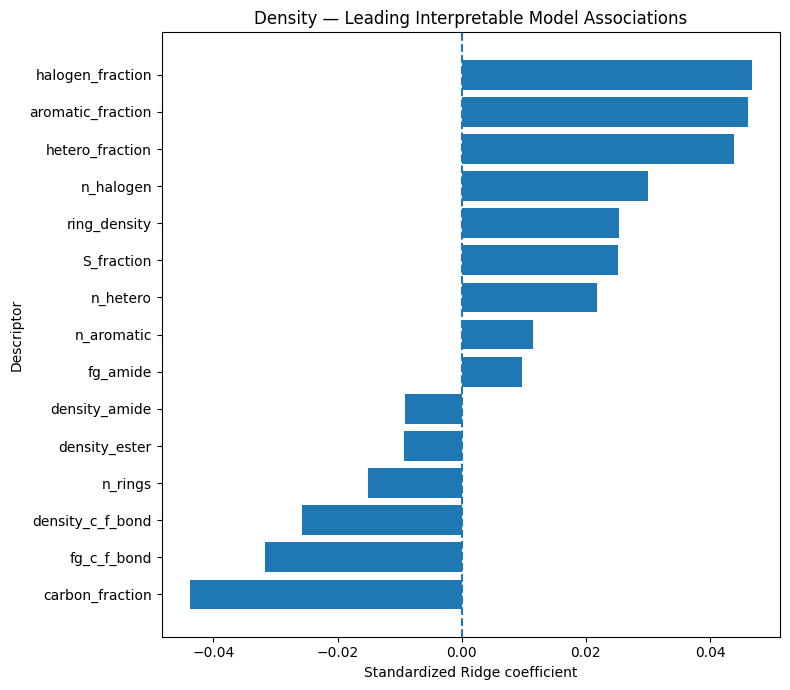

In [18]:
import matplotlib.pyplot as plt

top_density = (
    density_coefficient_table
    .head(15)
    .sort_values(
        "Coefficient"
    )
)

plt.figure(
    figsize=(8, 7)
)

plt.barh(
    top_density[
        "Feature"
    ],
    top_density[
        "Coefficient"
    ]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Standardized Ridge coefficient"
)

plt.ylabel(
    "Descriptor"
)

plt.title(
    "Density — Leading Interpretable Model Associations"
)

plt.tight_layout()
plt.show()

##  Global Descriptor Importance Across Properties

Permutation importance is used to quantify how strongly each fitted model depends on the interpretable descriptor set.

Each descriptor is independently permuted in the original frozen holdout set while all other features remain unchanged.

Importance is measured as the reduction in holdout R²:

$$
I_j
=
R^2_{\mathrm{baseline}}
-
R^2_{\mathrm{feature}\ j\ \mathrm{permuted}}
$$

The procedure is repeated multiple times to reduce dependence on a single random permutation.

Permutation importance measures predictive dependence of the fitted model.

It does not establish causality, and correlated descriptors can share or mask importance.

In [19]:
# ============================================================
# Interpretable-feature permutation importance
# ============================================================

from sklearn.inspection import (
    permutation_importance
)

INTERPRETABLE_PERMUTATION_REPEATS = 15

interpretable_importance_tables = {}


for target in [
    "Tg",
    "FFV",
    "Tc",
    "Density"
]:

    model = (
        fitted_final_models[
            target
        ]
    )

    representation = (
        final_model_specs[
            target
        ][
            "representation"
        ]
    )

    test_idx_target = (
        target_frozen_indices[
            target
        ]["test_idx"]
    )

    X_test_full = (
        representation_matrices[
            representation
        ][
            test_idx_target
        ]
    )

    y_test = (
        metadata.loc[
            test_idx_target,
            target
        ]
        .to_numpy(
            dtype=float
        )
    )


    if representation == "Interpretable":

        result = permutation_importance(
            model,
            X_test_full,
            y_test,
            scoring="r2",
            n_repeats=
                INTERPRETABLE_PERMUTATION_REPEATS,
            random_state=42,
            n_jobs=-1
        )

        importance_mean = (
            result.importances_mean
        )

        importance_std = (
            result.importances_std
        )


    else:

        # For Hybrid models, permute one of the
        # first 36 columns while leaving all
        # Morgan columns untouched.

        baseline_r2 = r2_score(
            y_test,
            model.predict(
                X_test_full
            )
        )

        means = []
        stds = []

        local_rng = np.random.default_rng(
            42
        )

        for column in range(
            36
        ):

            drops = []

            for repeat in range(
                INTERPRETABLE_PERMUTATION_REPEATS
            ):

                X_perm = (
                    X_test_full.copy()
                )

                permutation = (
                    local_rng.permutation(
                        len(X_perm)
                    )
                )

                X_perm[
                    :,
                    column
                ] = (
                    X_perm[
                        permutation,
                        column
                    ]
                )

                permuted_r2 = r2_score(
                    y_test,
                    model.predict(
                        X_perm
                    )
                )

                drops.append(
                    baseline_r2
                    -
                    permuted_r2
                )

            means.append(
                np.mean(
                    drops
                )
            )

            stds.append(
                np.std(
                    drops,
                    ddof=1
                )
            )

        importance_mean = np.array(
            means
        )

        importance_std = np.array(
            stds
        )


    table = pd.DataFrame({
        "Feature":
            interpretable_feature_names,

        "R2_Drop_Mean":
            importance_mean,

        "R2_Drop_Std":
            importance_std
    })

    table = (
        table
        .sort_values(
            "R2_Drop_Mean",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    interpretable_importance_tables[
        target
    ] = table


    print(
        "\n"
        + "=" * 95
    )

    print(
        f"{target} — TOP INTERPRETABLE DESCRIPTORS"
    )

    display(
        table
        .head(12)
        .round(5)
    )


Tg — TOP INTERPRETABLE DESCRIPTORS


,Feature,R2_Drop_Mean,R2_Drop_Std
0,ring_density,0.11283,0.02013
1,aromatic_fraction,0.03002,0.01089
2,n_rings,0.02477,0.01540
3,density_carbonyl,0.00306,0.00138
4,fg_ether,0.00277,0.00109
5,fg_ester,0.00255,0.00135
6,density_ether,0.00192,0.00070
7,n_O,0.00189,0.00162
8,n_aromatic,0.00173,0.00954
9,density_ester,0.00163,0.00074



FFV — TOP INTERPRETABLE DESCRIPTORS


,Feature,R2_Drop_Mean,R2_Drop_Std
0,O_fraction,0.22109,0.00993
1,density_carbonyl,0.02527,0.00420
2,density_c_f_bond,0.02233,0.00400
3,n_C,0.01410,0.00369
4,density_hydroxyl,0.01257,0.00182
5,ring_density,0.00971,0.00149
6,n_hetero,0.00840,0.00398
7,S_fraction,0.00461,0.00152
8,N_fraction,0.00432,0.00355
9,density_ether,0.00387,0.00151



Tc — TOP INTERPRETABLE DESCRIPTORS


,Feature,R2_Drop_Mean,R2_Drop_Std
0,n_halogen,0.04343,0.01125
1,n_heavy_atoms,0.01479,0.00436
2,hetero_fraction,0.01224,0.00686
3,n_aromatic,0.01115,0.00505
4,N_fraction,0.00983,0.00309
5,density_ester,0.00826,0.00694
6,O_fraction,0.00664,0.00713
7,n_hetero,0.00556,0.00379
8,density_c_c_double_bond,0.00556,0.00356
9,S_fraction,0.00543,0.00230



Density — TOP INTERPRETABLE DESCRIPTORS


,Feature,R2_Drop_Mean,R2_Drop_Std
0,halogen_fraction,0.30677,0.04289
1,carbon_fraction,0.21644,0.02168
2,hetero_fraction,0.21643,0.02168
3,aromatic_fraction,0.20346,0.01938
4,n_halogen,0.07076,0.01137
5,ring_density,0.05566,0.00700
6,n_hetero,0.04189,0.00710
7,S_fraction,0.02171,0.00542
8,n_rings,0.01773,0.00375
9,fg_c_f_bond,0.01738,0.00750


## Descriptor Direction in the Observed Data

Permutation importance quantifies predictive dependence but does not provide a direction of association.

To provide chemical context, each interpretable descriptor is also compared with the experimentally observed target using Spearman rank correlation.

This produces two distinct quantities:

- **model importance:** how strongly the fitted predictor depends on the descriptor;
- **observed association:** whether larger descriptor values tend to correspond to larger or smaller experimental property values.

These quantities should not be conflated.

A descriptor can be strongly predictive even when its marginal correlation is weak because nonlinear interactions or correlated features may carry its information.

In [21]:
# ============================================================
# Descriptor–target associations with constant-feature guard
# ============================================================

from scipy.stats import spearmanr

descriptor_target_associations = {}

for target in target_columns:

    available_idx = np.flatnonzero(
        metadata[target]
        .notna()
        .to_numpy()
    )

    y = (
        metadata.loc[
            available_idx,
            target
        ]
        .to_numpy(dtype=float)
    )

    rows = []

    for j, feature in enumerate(
        interpretable_feature_names
    ):

        x = (
            X_interpretable[
                available_idx,
                j
            ]
        )

        n_unique = np.unique(
            x
        ).size

        if n_unique < 2:

            rho = np.nan
            p_value = np.nan
            status = "Constant"

        else:

            rho, p_value = spearmanr(
                x,
                y
            )

            status = "Variable"

        rows.append({
            "Feature":
                feature,

            "n_unique":
                n_unique,

            "Status":
                status,

            "Spearman_rho":
                rho,

            "P_value":
                p_value
        })

    table = pd.DataFrame(
        rows
    )

    table[
        "Abs_rho"
    ] = np.abs(
        table[
            "Spearman_rho"
        ]
    )

    table = (
        table
        .sort_values(
            "Abs_rho",
            ascending=False,
            na_position="last"
        )
        .reset_index(
            drop=True
        )
    )

    descriptor_target_associations[
        target
    ] = table

    print(
        "\n"
        + "=" * 95
    )

    print(
        f"{target} — STRONGEST OBSERVED "
        f"DESCRIPTOR ASSOCIATIONS"
    )

    display(
        table[
            table["Status"]
            == "Variable"
        ]
        .head(12)
        .round(4)
    )


Tg — STRONGEST OBSERVED DESCRIPTOR ASSOCIATIONS


,Feature,n_unique,Status,Spearman_rho,P_value,Abs_rho
0,ring_density,114,Variable,0.6558,0.0,0.6558
1,aromatic_fraction,132,Variable,0.6267,0.0,0.6267
2,n_rings,14,Variable,0.5866,0.0,0.5866
3,n_aromatic,35,Variable,0.5746,0.0,0.5746
4,n_N,8,Variable,0.3288,0.0,0.3288
5,n_C,58,Variable,0.2983,0.0,0.2983
6,n_heavy_atoms,70,Variable,0.2773,0.0,0.2773
7,density_ester,67,Variable,-0.2766,0.0,0.2766
8,N_fraction,103,Variable,0.2614,0.0,0.2614
9,fg_ester,6,Variable,-0.2611,0.0,0.2611



FFV — STRONGEST OBSERVED DESCRIPTOR ASSOCIATIONS


,Feature,n_unique,Status,Spearman_rho,P_value,Abs_rho
0,carbon_fraction,620,Variable,0.4130,0.0,0.4130
1,hetero_fraction,620,Variable,-0.4130,0.0,0.4130
2,O_fraction,442,Variable,-0.3934,0.0,0.3934
3,density_carbonyl,251,Variable,-0.3568,0.0,0.3568
4,density_ester,155,Variable,-0.3187,0.0,0.3187
5,fg_ester,7,Variable,-0.3091,0.0,0.3091
6,n_rings,19,Variable,0.3009,0.0,0.3009
7,n_aromatic,68,Variable,0.2957,0.0,0.2957
8,n_C,99,Variable,0.2890,0.0,0.2890
9,ring_density,344,Variable,0.2703,0.0,0.2703



Tc — STRONGEST OBSERVED DESCRIPTOR ASSOCIATIONS


,Feature,n_unique,Status,Spearman_rho,P_value,Abs_rho
0,n_C,50,Variable,0.5985,0.0,0.5985
1,n_heavy_atoms,54,Variable,0.5190,0.0,0.5190
2,halogen_fraction,43,Variable,-0.4329,0.0,0.4329
3,n_halogen,18,Variable,-0.4294,0.0,0.4294
4,fg_amide,5,Variable,0.4048,0.0,0.4048
5,density_amide,38,Variable,0.3797,0.0,0.3797
6,density_ester,49,Variable,-0.3662,0.0,0.3662
7,ring_density,75,Variable,-0.3584,0.0,0.3584
8,n_N,9,Variable,0.3507,0.0,0.3507
9,density_c_f_bond,30,Variable,-0.3214,0.0,0.3214



Density — STRONGEST OBSERVED DESCRIPTOR ASSOCIATIONS


,Feature,n_unique,Status,Spearman_rho,P_value,Abs_rho
0,hetero_fraction,120,Variable,0.7057,0.0,0.7057
1,carbon_fraction,120,Variable,-0.7057,0.0,0.7057
2,n_hetero,19,Variable,0.5328,0.0,0.5328
3,O_fraction,91,Variable,0.4494,0.0,0.4494
4,aromatic_fraction,84,Variable,0.3913,0.0,0.3913
5,halogen_fraction,34,Variable,0.3813,0.0,0.3813
6,n_halogen,14,Variable,0.3787,0.0,0.3787
7,n_O,10,Variable,0.3762,0.0,0.3762
8,n_aromatic,23,Variable,0.3678,0.0,0.3678
9,n_rings,13,Variable,0.3032,0.0,0.3032



Rg — STRONGEST OBSERVED DESCRIPTOR ASSOCIATIONS


,Feature,n_unique,Status,Spearman_rho,P_value,Abs_rho
0,density_ester,47,Variable,-0.3990,0.0000,0.3990
1,fg_ester,3,Variable,-0.3705,0.0000,0.3705
2,fg_amide,4,Variable,0.3257,0.0000,0.3257
3,n_hetero,19,Variable,0.3034,0.0000,0.3034
4,density_amide,35,Variable,0.2993,0.0000,0.2993
5,n_N,9,Variable,0.2877,0.0000,0.2877
6,n_heavy_atoms,57,Variable,0.2869,0.0000,0.2869
7,n_C,52,Variable,0.2730,0.0000,0.2730
8,N_fraction,51,Variable,0.2278,0.0000,0.2278
9,n_S,4,Variable,0.1529,0.0001,0.1529


# Part C — Local Structural Environment Interpretation

##  Morgan Feature Interpretation Strategy

Morgan fingerprints provide detailed information about local atomic environments, but their hashed feature indices are not directly chemically interpretable.

A feature such as:

`Morgan bit 874`

does not by itself identify a unique functional group.

Two complications must be addressed.

### 1. Hashed-feature ambiguity

Different molecular environments can occasionally map to the same hashed fingerprint index.

Therefore, an important Morgan feature must be traced back to the actual molecular environments that generated it before assigning a chemical interpretation.

### 2. Large feature space

The final Morgan representation contains 2,048 count features.

Exhaustive high-repeat permutation analysis of every fingerprint dimension would be computationally inefficient.

A two-stage interpretation strategy is therefore used.

### Stage 1 — training-only candidate screening

Morgan features are screened using their association with the target within the frozen training partition only.

This identifies a manageable candidate set without examining holdout target values.

### Stage 2 — holdout permutation validation

Candidate Morgan features are then individually permuted within the frozen holdout set.

The resulting decrease in R² measures how strongly the already-fitted final model depends on each candidate feature.

Only features demonstrating meaningful holdout model dependence are carried forward for chemical decoding.

### Chemical decoding

Selected feature indices are regenerated from the original polymer SMILES using the exact Notebook 02 Morgan configuration:

- count fingerprint;
- radius = 4;
- fingerprint size = 2,048;
- chirality enabled;
- polymer wildcard atoms retained.

RDKit atom-environment information is collected for every occurrence of each selected bit.

Distinct fragment environments, occurrence frequencies, and hashing ambiguity are then reported explicitly.

In [22]:
# ============================================================
# Training-only Morgan feature screening
# ============================================================

MORGAN_SCREEN_TOP_K = 60

morgan_training_screen = {}

for target in [
    "Tg",
    "FFV",
    "Tc",
    "Rg"
]:

    train_idx_target = (
        target_frozen_indices[
            target
        ]["train_idx"]
    )

    y_train = (
        metadata.loc[
            train_idx_target,
            target
        ]
        .to_numpy(dtype=float)
    )

    X_train_morgan = (
        X_morgan[
            train_idx_target
        ]
    )

    rows = []

    for bit_idx in range(
        X_train_morgan.shape[1]
    ):

        x = (
            X_train_morgan[
                :,
                bit_idx
            ]
        )

        if np.unique(x).size < 2:

            continue

        rho, p_value = spearmanr(
            x,
            y_train
        )

        rows.append({
            "Morgan_index":
                bit_idx,

            "Feature_name":
                morgan_feature_names[
                    bit_idx
                ],

            "Spearman_rho_train":
                rho,

            "P_value_train":
                p_value,

            "Abs_rho_train":
                abs(rho),

            "Training_occurrence":
                int(
                    np.sum(
                        x > 0
                    )
                ),

            "Training_mean_count":
                float(
                    np.mean(x)
                )
        })

    table = pd.DataFrame(
        rows
    )

    table = (
        table
        .sort_values(
            "Abs_rho_train",
            ascending=False
        )
        .reset_index(drop=True)
    )

    morgan_training_screen[
        target
    ] = table

    print(
        "\n"
        + "=" * 105
    )

    print(
        f"{target} — TRAINING-ONLY "
        f"MORGAN CANDIDATES"
    )

    display(
        table
        .head(15)
        .round(4)
    )


Tg — TRAINING-ONLY MORGAN CANDIDATES


,Morgan_index,Feature_name,Spearman_rho_train,P_value_train,Abs_rho_train,Training_occurrence,Training_mean_count
0,1380,morgan_r4_1380,0.5999,0.0,0.5999,305,5.4191
1,80,morgan_r4_80,-0.5869,0.0,0.5869,264,4.6397
2,1873,morgan_r4_1873,0.5351,0.0,0.5351,299,6.9167
3,1750,morgan_r4_1750,0.4890,0.0,0.4890,277,5.4118
4,1911,morgan_r4_1911,-0.4887,0.0,0.4887,161,2.5539
5,247,morgan_r4_247,-0.4496,0.0,0.4496,161,0.4020
6,891,morgan_r4_891,0.4489,0.0,0.4489,92,0.3799
7,1143,morgan_r4_1143,-0.4187,0.0,0.4187,124,1.5000
8,1117,morgan_r4_1117,-0.4041,0.0,0.4041,94,0.2402
9,587,morgan_r4_587,0.4033,0.0,0.4033,154,0.4583



FFV — TRAINING-ONLY MORGAN CANDIDATES


,Morgan_index,Feature_name,Spearman_rho_train,P_value_train,Abs_rho_train,Training_occurrence,Training_mean_count
0,587,morgan_r4_587,0.4003,0.0,0.4003,2086,0.4401
1,1917,morgan_r4_1917,-0.3907,0.0,0.3907,3010,1.0519
2,807,morgan_r4_807,-0.3819,0.0,0.3819,3236,1.1559
3,1152,morgan_r4_1152,-0.3520,0.0,0.3520,2130,0.8017
4,891,morgan_r4_891,0.3348,0.0,0.3348,1596,0.4628
5,1380,morgan_r4_1380,0.3013,0.0,0.3013,4736,8.1716
6,1522,morgan_r4_1522,0.2814,0.0,0.2814,1941,0.3743
7,1625,morgan_r4_1625,0.2728,0.0,0.2728,1027,0.1851
8,147,morgan_r4_147,-0.2713,0.0,0.2713,1127,0.2978
9,378,morgan_r4_378,0.2643,0.0,0.2643,921,0.3369



Tc — TRAINING-ONLY MORGAN CANDIDATES


,Morgan_index,Feature_name,Spearman_rho_train,P_value_train,Abs_rho_train,Training_occurrence,Training_mean_count
0,1143,morgan_r4_1143,0.8199,0.0,0.8199,264,4.4720
1,1911,morgan_r4_1911,0.8142,0.0,0.8142,316,6.0900
2,784,morgan_r4_784,0.7864,0.0,0.7864,230,3.2003
3,80,morgan_r4_80,0.7547,0.0,0.7547,544,8.9440
4,876,morgan_r4_876,0.7453,0.0,0.7453,196,2.2224
5,1117,morgan_r4_1117,0.5649,0.0,0.5649,203,0.3548
6,1299,morgan_r4_1299,0.5562,0.0,0.5562,181,0.3090
7,1842,morgan_r4_1842,0.5225,0.0,0.5225,148,0.2513
8,114,morgan_r4_114,-0.5213,0.0,0.5213,136,0.3497
9,2029,morgan_r4_2029,0.5125,0.0,0.5125,128,0.2190



Rg — TRAINING-ONLY MORGAN CANDIDATES


,Morgan_index,Feature_name,Spearman_rho_train,P_value_train,Abs_rho_train,Training_occurrence,Training_mean_count
0,1117,morgan_r4_1117,0.5762,0.0,0.5762,145,0.3035
1,1299,morgan_r4_1299,0.5319,0.0,0.5319,124,0.2525
2,1057,morgan_r4_1057,-0.5286,0.0,0.5286,271,1.0163
3,1842,morgan_r4_1842,0.5014,0.0,0.5014,101,0.2057
4,2029,morgan_r4_2029,0.4881,0.0,0.4881,90,0.1833
5,145,morgan_r4_145,0.4840,0.0,0.4840,123,0.2566
6,1175,morgan_r4_1175,0.4824,0.0,0.4824,89,0.1853
7,969,morgan_r4_969,-0.4736,0.0,0.4736,150,0.3075
8,1564,morgan_r4_1564,0.4516,0.0,0.4516,102,0.3870
9,998,morgan_r4_998,-0.4392,0.0,0.4392,97,0.2016


##  Holdout Validation of Important Morgan Features

Marginal association with the target does not guarantee that a fingerprint feature is important to the fitted predictive model.

The top training-derived Morgan candidates are therefore validated by permutation on the frozen Notebook 03 holdout set.

For each selected Morgan feature:

$$
I_j
=
R^2_{\mathrm{baseline}}
-
R^2_{\mathrm{permuted}\ j}
$$

The permutation is repeated 20 times.

This separates:

- fingerprints that are merely correlated with the target;
- from fingerprints on which the final predictive model actually depends.

In [23]:
# ============================================================
# Candidate Morgan permutation validation
# ============================================================

MORGAN_PERMUTATION_REPEATS = 20

morgan_permutation_importance = {}

for target in [
    "Tg",
    "FFV",
    "Tc",
    "Rg"
]:

    model = (
        fitted_final_models[
            target
        ]
    )

    representation = (
        final_model_specs[
            target
        ][
            "representation"
        ]
    )

    test_idx_target = (
        target_frozen_indices[
            target
        ]["test_idx"]
    )

    X_test = (
        representation_matrices[
            representation
        ][
            test_idx_target
        ]
        .copy()
    )

    y_test = (
        metadata.loc[
            test_idx_target,
            target
        ]
        .to_numpy(dtype=float)
    )

    baseline_r2 = r2_score(
        y_test,
        model.predict(
            X_test
        )
    )

    candidate_table = (
        morgan_training_screen[
            target
        ]
        .head(
            MORGAN_SCREEN_TOP_K
        )
        .copy()
    )

    rows = []

    rng_local = np.random.default_rng(
        4200
        + target_columns.index(
            target
        )
    )

    for _, candidate in (
        candidate_table.iterrows()
    ):

        bit_idx = int(
            candidate[
                "Morgan_index"
            ]
        )

        # In Hybrid models the Morgan block starts
        # after the 36 interpretable descriptors.
        if representation == "Hybrid":

            model_column = (
                36
                + bit_idx
            )

        elif representation == "Morgan_r4":

            model_column = (
                bit_idx
            )

        else:

            continue

        drops = []

        for repeat in range(
            MORGAN_PERMUTATION_REPEATS
        ):

            X_perm = (
                X_test.copy()
            )

            permutation = (
                rng_local.permutation(
                    len(X_perm)
                )
            )

            X_perm[
                :,
                model_column
            ] = (
                X_perm[
                    permutation,
                    model_column
                ]
            )

            permuted_r2 = r2_score(
                y_test,
                model.predict(
                    X_perm
                )
            )

            drops.append(
                baseline_r2
                -
                permuted_r2
            )

        rows.append({
            "Morgan_index":
                bit_idx,

            "Feature_name":
                candidate[
                    "Feature_name"
                ],

            "Train_Spearman_rho":
                candidate[
                    "Spearman_rho_train"
                ],

            "Training_occurrence":
                candidate[
                    "Training_occurrence"
                ],

            "Holdout_R2_Drop_Mean":
                np.mean(
                    drops
                ),

            "Holdout_R2_Drop_Std":
                np.std(
                    drops,
                    ddof=1
                )
        })

    result_table = (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "Holdout_R2_Drop_Mean",
            ascending=False
        )
        .reset_index(drop=True)
    )

    morgan_permutation_importance[
        target
    ] = result_table

    print(
        "\n"
        + "=" * 105
    )

    print(
        f"{target} — VALIDATED MORGAN "
        f"FEATURE IMPORTANCE"
    )

    display(
        result_table
        .head(15)
        .round(5)
    )


Tg — VALIDATED MORGAN FEATURE IMPORTANCE


,Morgan_index,Feature_name,Train_Spearman_rho,Training_occurrence,Holdout_R2_Drop_Mean,Holdout_R2_Drop_Std
0,80,morgan_r4_80,-0.58692,264,0.05961,0.01495
1,1380,morgan_r4_1380,0.59995,305,0.02003,0.01326
2,1911,morgan_r4_1911,-0.48870,161,0.01607,0.00686
3,247,morgan_r4_247,-0.44964,161,0.00598,0.00694
4,1143,morgan_r4_1143,-0.41873,124,0.00346,0.00260
5,587,morgan_r4_587,0.40330,154,0.00324,0.00236
6,964,morgan_r4_964,0.30886,54,0.00159,0.00079
7,145,morgan_r4_145,-0.23022,99,0.00124,0.00118
8,1564,morgan_r4_1564,-0.31283,76,0.00119,0.00274
9,13,morgan_r4_13,-0.32155,95,0.00118,0.00097



FFV — VALIDATED MORGAN FEATURE IMPORTANCE


,Morgan_index,Feature_name,Train_Spearman_rho,Training_occurrence,Holdout_R2_Drop_Mean,Holdout_R2_Drop_Std
0,1152,morgan_r4_1152,-0.35199,2130,0.24337,0.01255
1,1057,morgan_r4_1057,0.24063,2658,0.05356,0.00541
2,80,morgan_r4_80,-0.22372,3152,0.02817,0.00354
3,1831,morgan_r4_1831,-0.21440,1205,0.02232,0.00241
4,587,morgan_r4_587,0.40029,2086,0.02055,0.00438
5,1873,morgan_r4_1873,0.25770,4641,0.01073,0.00186
6,807,morgan_r4_807,-0.38185,3236,0.00806,0.00268
7,294,morgan_r4_294,0.16145,791,0.00783,0.00201
8,1380,morgan_r4_1380,0.30132,4736,0.00405,0.00088
9,1097,morgan_r4_1097,0.14600,460,0.00400,0.00096



Tc — VALIDATED MORGAN FEATURE IMPORTANCE


,Morgan_index,Feature_name,Train_Spearman_rho,Training_occurrence,Holdout_R2_Drop_Mean,Holdout_R2_Drop_Std
0,1143,morgan_r4_1143,0.81988,264,0.63390,0.05836
1,1117,morgan_r4_1117,0.56494,203,0.01306,0.00417
2,80,morgan_r4_80,0.75467,544,0.01091,0.00394
3,876,morgan_r4_876,0.74533,196,0.00702,0.00637
4,1275,morgan_r4_1275,0.32439,80,0.00690,0.00135
5,1299,morgan_r4_1299,0.55623,181,0.00549,0.00260
6,1911,morgan_r4_1911,0.81418,316,0.00501,0.00484
7,592,morgan_r4_592,0.40504,101,0.00188,0.00159
8,1718,morgan_r4_1718,0.38866,96,0.00178,0.00094
9,998,morgan_r4_998,-0.39650,104,0.00135,0.00194



Rg — VALIDATED MORGAN FEATURE IMPORTANCE


,Morgan_index,Feature_name,Train_Spearman_rho,Training_occurrence,Holdout_R2_Drop_Mean,Holdout_R2_Drop_Std
0,1117,morgan_r4_1117,0.57625,145,0.21846,0.03455
1,1057,morgan_r4_1057,-0.52863,271,0.19922,0.03527
2,969,morgan_r4_969,-0.47356,150,0.03902,0.01258
3,170,morgan_r4_170,-0.43574,161,0.01846,0.00707
4,1267,morgan_r4_1267,0.43166,98,0.00911,0.00199
5,294,morgan_r4_294,-0.35176,137,0.00755,0.00213
6,1143,morgan_r4_1143,0.38142,202,0.00625,0.00609
7,1911,morgan_r4_1911,0.35674,236,0.00617,0.00476
8,998,morgan_r4_998,-0.43915,97,0.00574,0.00269
9,1,morgan_r4_1,-0.42907,186,0.00400,0.00277


In [24]:
# ============================================================
# Select top validated Morgan bits for decoding
# ============================================================

TOP_MORGAN_BITS_PER_TARGET = 10

selected_morgan_rows = []

for target in [
    "Tg",
    "FFV",
    "Tc",
    "Rg"
]:

    table = (
        morgan_permutation_importance[
            target
        ]
    )

    positive_table = (
        table[
            table[
                "Holdout_R2_Drop_Mean"
            ] > 0
        ]
        .head(
            TOP_MORGAN_BITS_PER_TARGET
        )
    )

    for _, row in (
        positive_table.iterrows()
    ):

        selected_morgan_rows.append({
            "Target":
                target,

            "Morgan_index":
                int(
                    row[
                        "Morgan_index"
                    ]
                ),

            "Train_Spearman_rho":
                row[
                    "Train_Spearman_rho"
                ],

            "Holdout_R2_Drop_Mean":
                row[
                    "Holdout_R2_Drop_Mean"
                ],

            "Holdout_R2_Drop_Std":
                row[
                    "Holdout_R2_Drop_Std"
                ]
        })


selected_morgan_features = pd.DataFrame(
    selected_morgan_rows
)

unique_selected_morgan_bits = sorted(
    selected_morgan_features[
        "Morgan_index"
    ]
    .unique()
)


print(
    "SELECTED MORGAN FEATURES FOR CHEMICAL DECODING"
)
print("=" * 100)

display(
    selected_morgan_features
    .sort_values(
        [
            "Target",
            "Holdout_R2_Drop_Mean"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(5)
)

print(
    f"\nUnique Morgan bits to decode: "
    f"{len(unique_selected_morgan_bits)}"
)

SELECTED MORGAN FEATURES FOR CHEMICAL DECODING


,Target,Morgan_index,Train_Spearman_rho,Holdout_R2_Drop_Mean,Holdout_R2_Drop_Std
10,FFV,1152,-0.35199,0.24337,0.01255
11,FFV,1057,0.24063,0.05356,0.00541
12,FFV,80,-0.22372,0.02817,0.00354
13,FFV,1831,-0.21440,0.02232,0.00241
14,FFV,587,0.40029,0.02055,0.00438
15,FFV,1873,0.25770,0.01073,0.00186
16,FFV,807,-0.38185,0.00806,0.00268
17,FFV,294,0.16145,0.00783,0.00201
18,FFV,1380,0.30132,0.00405,0.00088
19,FFV,1097,0.14600,0.00400,0.00096



Unique Morgan bits to decode: 28


In [25]:
%pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 20.5 MB/s eta 0:00:00


In [26]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

morgan_generator = (
    rdFingerprintGenerator
    .GetMorganGenerator(
        radius=4,
        fpSize=2048,
        includeChirality=True
    )
)

print(
    "RDKit Morgan generator configured."
)

RDKit Morgan generator configured.


##  Fingerprint-Regeneration Audit

Chemical decoding requires the Morgan fingerprints regenerated in Notebook 06 to be identical to the frozen Notebook 02 representation.

A random subset of polymers is therefore re-fingerprinted using the documented radius, size, chirality, and wildcard configuration.

The regenerated count vectors must match the archived Notebook 02 matrix exactly before atom-environment interpretation proceeds.

In [27]:
# ============================================================
# Exact Morgan regeneration check
# ============================================================

fingerprint_check_rng = (
    np.random.default_rng(
        42
    )
)

fingerprint_check_indices = (
    fingerprint_check_rng.choice(
        len(metadata),
        size=100,
        replace=False
    )
)

fingerprint_mismatches = []


for idx in fingerprint_check_indices:

    smiles = (
        metadata.loc[
            idx,
            "SMILES"
        ]
    )

    mol = Chem.MolFromSmiles(
        smiles
    )

    if mol is None:

        fingerprint_mismatches.append(
            int(idx)
        )

        continue

    fp = (
        morgan_generator
        .GetCountFingerprint(
            mol
        )
    )

    regenerated = np.zeros(
        2048,
        dtype=np.int32
    )

    DataStructs.ConvertToNumpyArray(
        fp,
        regenerated
    )

    archived = (
        X_morgan[
            idx
        ]
        .astype(
            np.int32
        )
    )

    if not np.array_equal(
        regenerated,
        archived
    ):

        fingerprint_mismatches.append(
            int(idx)
        )


print(
    "MORGAN REGENERATION AUDIT"
)
print("=" * 80)

print(
    f"Polymers checked: "
    f"{len(fingerprint_check_indices)}"
)

print(
    f"Mismatches:       "
    f"{len(fingerprint_mismatches)}"
)

if len(
    fingerprint_mismatches
) == 0:

    print(
        "Exact fingerprint regeneration: PASSED"
    )

else:

    print(
        "Mismatch rows:",
        fingerprint_mismatches[
            :10
        ]
    )

MORGAN REGENERATION AUDIT
Polymers checked: 100
Mismatches:       0
Exact fingerprint regeneration: PASSED


## Recovery of Morgan Atomic Environments

The selected Morgan indices are now traced back to the atomic environments that generated them.

RDKit's Morgan `AdditionalOutput` functionality records, for each hashed fingerprint index, the central atom and radius of every contributing environment.

For each selected fingerprint feature, the analysis records:

- polymer identity;
- centre atom;
- Morgan radius;
- local atom set;
- local bond set;
- and a rooted fragment SMILES describing the environment.

The central atom is temporarily assigned atom-map number 1 in the fragment representation so that environments centred at different atoms can be distinguished even when they contain similar collections of atoms.

The original polymer molecule and the archived fingerprint representation are not modified.

Because Morgan features are hashed, multiple distinct atom-centred environments may map to the same 2,048-dimensional index.

The environment-recovery stage therefore explicitly preserves every observed environment rather than assuming one fingerprint index corresponds to one unique chemical motif.

In [28]:
# ============================================================
# Recover atom-centred environments for selected Morgan bits
# ============================================================

from collections import Counter

selected_bit_set = set(
    int(x)
    for x in unique_selected_morgan_bits
)


def recover_environment(
    mol,
    center_atom,
    radius
):
    """
    Recover atom and bond indices defining a Morgan environment
    and create a rooted fragment SMILES with the centre atom
    explicitly marked using atom-map number 1.
    """

    center_atom = int(
        center_atom
    )

    radius = int(
        radius
    )

    # Radius-0 environments contain the
    # central atom but no bonds.
    if radius == 0:

        bond_indices = []

        atom_indices = [
            center_atom
        ]

    else:

        bond_indices = list(
            Chem.FindAtomEnvironmentOfRadiusN(
                mol,
                radius,
                center_atom
            )
        )

        atom_set = {
            center_atom
        }

        for bond_idx in bond_indices:

            bond = mol.GetBondWithIdx(
                int(bond_idx)
            )

            atom_set.add(
                bond.GetBeginAtomIdx()
            )

            atom_set.add(
                bond.GetEndAtomIdx()
            )

        atom_indices = sorted(
            atom_set
        )


    # Copy only for display/encoding.
    # The original molecule is untouched.
    marked_mol = Chem.Mol(
        mol
    )

    for atom in marked_mol.GetAtoms():

        atom.SetAtomMapNum(
            0
        )

    marked_mol.GetAtomWithIdx(
        center_atom
    ).SetAtomMapNum(
        1
    )


    fragment_smiles = (
        Chem.MolFragmentToSmiles(
            marked_mol,
            atomsToUse=atom_indices,
            bondsToUse=bond_indices,
            rootedAtAtom=center_atom,
            canonical=True,
            isomericSmiles=True
        )
    )


    center = mol.GetAtomWithIdx(
        center_atom
    )


    return {
        "Fragment_SMILES":
            fragment_smiles,

        "Center_symbol":
            center.GetSymbol(),

        "Center_atomic_number":
            center.GetAtomicNum(),

        "Radius":
            radius,

        "Atom_count":
            len(
                atom_indices
            ),

        "Bond_count":
            len(
                bond_indices
            ),

        "Atom_indices":
            tuple(
                atom_indices
            ),

        "Bond_indices":
            tuple(
                int(x)
                for x in bond_indices
            )
    }

In [29]:
# ============================================================
# Collect every occurrence of every selected Morgan bit
# ============================================================

morgan_environment_rows = []

bitinfo_count_mismatches = []


for row_idx in range(
    len(metadata)
):

    smiles = metadata.loc[
        row_idx,
        "SMILES"
    ]

    mol = Chem.MolFromSmiles(
        smiles
    )

    if mol is None:

        raise ValueError(
            f"Unexpected invalid SMILES "
            f"at row {row_idx}"
        )


    additional_output = (
        rdFingerprintGenerator
        .AdditionalOutput()
    )

    additional_output.AllocateBitInfoMap()


    # Generate the exact count fingerprint
    # while collecting bit information.
    _ = (
        morgan_generator
        .GetCountFingerprint(
            mol,
            additionalOutput=
                additional_output
        )
    )


    bit_info = (
        additional_output
        .GetBitInfoMap()
    )


    present_selected_bits = (
        selected_bit_set
        .intersection(
            bit_info.keys()
        )
    )


    for bit_idx in (
        present_selected_bits
    ):

        occurrences = (
            bit_info[
                bit_idx
            ]
        )

        archived_count = int(
            X_morgan[
                row_idx,
                bit_idx
            ]
        )


        # Strong consistency check:
        # the count stored in Notebook 02
        # should equal the number of
        # recovered environments.
        if (
            archived_count
            !=
            len(occurrences)
        ):

            bitinfo_count_mismatches.append({
                "row_index":
                    row_idx,

                "Morgan_index":
                    int(
                        bit_idx
                    ),

                "Archived_count":
                    archived_count,

                "Recovered_count":
                    len(
                        occurrences
                    )
            })


        for occurrence_number, (
            center_atom,
            radius
        ) in enumerate(
            occurrences
        ):

            environment = (
                recover_environment(
                    mol,
                    center_atom,
                    radius
                )
            )

            environment_signature = (
                f"r{environment['Radius']}|"
                f"{environment['Fragment_SMILES']}"
            )


            morgan_environment_rows.append({

                "row_index":
                    row_idx,

                "id":
                    metadata.loc[
                        row_idx,
                        "id"
                    ],

                "SMILES":
                    smiles,

                "Morgan_index":
                    int(
                        bit_idx
                    ),

                "Occurrence_number":
                    occurrence_number,

                "Center_atom_index":
                    int(
                        center_atom
                    ),

                "Center_symbol":
                    environment[
                        "Center_symbol"
                    ],

                "Center_atomic_number":
                    environment[
                        "Center_atomic_number"
                    ],

                "Radius":
                    environment[
                        "Radius"
                    ],

                "Atom_count":
                    environment[
                        "Atom_count"
                    ],

                "Bond_count":
                    environment[
                        "Bond_count"
                    ],

                "Fragment_SMILES":
                    environment[
                        "Fragment_SMILES"
                    ],

                "Environment_signature":
                    environment_signature,

                "Atom_indices":
                    environment[
                        "Atom_indices"
                    ],

                "Bond_indices":
                    environment[
                        "Bond_indices"
                    ]
            })


    if (
        (row_idx + 1) % 1000 == 0
        or
        row_idx + 1 == len(metadata)
    ):

        print(
            f"Processed "
            f"{row_idx + 1:,}/"
            f"{len(metadata):,}"
        )


morgan_environment_occurrences = (
    pd.DataFrame(
        morgan_environment_rows
    )
)


print(
    "\nMORGAN ENVIRONMENT RECOVERY"
)

print(
    "=" * 90
)

print(
    f"Selected bits:           "
    f"{len(selected_bit_set)}"
)

print(
    f"Recovered occurrences:   "
    f"{len(morgan_environment_occurrences):,}"
)

print(
    f"Count mismatches:        "
    f"{len(bitinfo_count_mismatches):,}"
)

Processed 1,000/7,973
Processed 2,000/7,973
Processed 3,000/7,973
Processed 4,000/7,973
Processed 5,000/7,973
Processed 6,000/7,973
Processed 7,000/7,973
Processed 7,973/7,973

MORGAN ENVIRONMENT RECOVERY
Selected bits:           28
Recovered occurrences:   261,846
Count mismatches:        0


In [30]:
assert (
    len(
        bitinfo_count_mismatches
    )
    == 0
)

print(
    "Fingerprint-count / environment-count "
    "consistency: PASSED"
)

Fingerprint-count / environment-count consistency: PASSED


##  Hashed-Feature Ambiguity Audit

A 2,048-dimensional hashed Morgan fingerprint can map several different underlying molecular environments to the same feature index.

Chemical interpretation therefore requires quantifying the degree of ambiguity associated with each selected bit.

For each bit, the following quantities are calculated:

- number of polymers containing the feature;
- total number of recovered feature occurrences;
- number of distinct atom-centred environment signatures;
- most frequent environment;
- fraction of all occurrences represented by the dominant environment.

A feature with one recovered environment is structurally unambiguous within this dataset.

For features with several environments, the dominant-environment fraction indicates whether one chemical interpretation remains representative.

The ambiguity classes used below are descriptive project labels rather than universal chemical definitions.

In [31]:
# ============================================================
# Summarize environment ambiguity for each selected Morgan bit
# ============================================================

bit_environment_rows = []


for bit_idx in sorted(
    selected_bit_set
):

    subset = (
        morgan_environment_occurrences[
            morgan_environment_occurrences[
                "Morgan_index"
            ]
            == bit_idx
        ]
    )

    environment_counts = (
        subset[
            "Environment_signature"
        ]
        .value_counts()
    )

    n_distinct = (
        len(
            environment_counts
        )
    )

    dominant_signature = (
        environment_counts.index[
            0
        ]
    )

    dominant_count = int(
        environment_counts.iloc[
            0
        ]
    )

    total_occurrences = (
        len(
            subset
        )
    )

    dominant_share = (
        dominant_count
        /
        total_occurrences
    )

    dominant_row = (
        subset[
            subset[
                "Environment_signature"
            ]
            == dominant_signature
        ]
        .iloc[0]
    )


    if n_distinct == 1:

        ambiguity_class = (
            "Unique environment"
        )

    elif dominant_share >= 0.90:

        ambiguity_class = (
            "Low ambiguity"
        )

    elif dominant_share >= 0.60:

        ambiguity_class = (
            "Moderate ambiguity"
        )

    else:

        ambiguity_class = (
            "High ambiguity"
        )


    bit_environment_rows.append({

        "Morgan_index":
            bit_idx,

        "Polymers_with_bit":
            subset[
                "row_index"
            ]
            .nunique(),

        "Total_occurrences":
            total_occurrences,

        "Distinct_environment_signatures":
            n_distinct,

        "Dominant_environment_share":
            dominant_share,

        "Dominant_radius":
            int(
                dominant_row[
                    "Radius"
                ]
            ),

        "Dominant_center":
            dominant_row[
                "Center_symbol"
            ],

        "Dominant_fragment":
            dominant_row[
                "Fragment_SMILES"
            ],

        "Ambiguity_class":
            ambiguity_class
    })


bit_environment_summary = (
    pd.DataFrame(
        bit_environment_rows
    )
    .sort_values(
        [
            "Ambiguity_class",
            "Dominant_environment_share"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "MORGAN HASH-AMBIGUITY AUDIT"
)
print("=" * 140)

display(
    bit_environment_summary
    .round(4)
)

MORGAN HASH-AMBIGUITY AUDIT


,Morgan_index,Polymers_with_bit,Total_occurrences,Distinct_environment_signatures,Dominant_environment_share,Dominant_radius,Dominant_center,Dominant_fragment,Ambiguity_class
0,1097,608,1197,36,0.5313,1,C,[c:1](c)(c)n,High ambiguity
1,80,4635,30782,28,0.9977,0,C,[CH2:1],Low ambiguity
2,1911,2366,15907,33,0.9935,1,C,[CH2:1](C)C,Low ambiguity
3,1143,1732,9871,30,0.9883,2,C,[CH2:1](CC)CC,Low ambiguity
4,1873,6330,84650,40,0.9860,0,C,[cH:1],Low ambiguity
5,13,1611,3569,37,0.9689,1,C,[CH2:1](C)O,Low ambiguity
6,1831,1713,2843,32,0.9669,1,*,[*:1]N,Low ambiguity
7,587,2863,3431,37,0.9528,1,*,[*:1]c,Low ambiguity
8,1057,3734,9026,40,0.9487,0,C,[CH3:1],Low ambiguity
9,1,1600,2163,30,0.9422,0,C,[CH:1],Low ambiguity


In [32]:
ambiguity_class_summary = (
    bit_environment_summary[
        "Ambiguity_class"
    ]
    .value_counts()
    .rename_axis(
        "Ambiguity_class"
    )
    .reset_index(
        name="Count"
    )
)


print(
    "SELECTED-BIT AMBIGUITY SUMMARY"
)
print("=" * 75)

display(
    ambiguity_class_summary
)

SELECTED-BIT AMBIGUITY SUMMARY


,Ambiguity_class,Count
0,Low ambiguity,16
1,Moderate ambiguity,11
2,High ambiguity,1


##  Cross-Property Morgan Motif Atlas

The validated model-dependence results are joined to the chemical-environment decoding.

For each target–feature pair, the final motif atlas reports:

- fingerprint index;
- holdout permutation importance;
- training-set direction of association;
- dominant chemical environment;
- radius;
- prevalence;
- and hashing ambiguity.

The training Spearman coefficient is used only as a directional descriptor.

A positive coefficient indicates that larger counts of the feature were associated with larger target values in the frozen training set.

It does not imply that inserting the fragment into a polymer would causally increase that property.

In [33]:
# ============================================================
# Join validated importance with decoded environments
# ============================================================

morgan_motif_atlas = (
    selected_morgan_features
    .merge(
        bit_environment_summary,
        on="Morgan_index",
        how="left",
        validate="many_to_one"
    )
)


morgan_motif_atlas[
    "Association_direction"
] = np.where(
    morgan_motif_atlas[
        "Train_Spearman_rho"
    ] > 0,
    "Higher count -> higher target",
    "Higher count -> lower target"
)


# Importance normalized relative to
# the strongest selected Morgan feature
# within each target.
morgan_motif_atlas[
    "Relative_importance_to_target_max"
] = (
    morgan_motif_atlas[
        "Holdout_R2_Drop_Mean"
    ]
    /
    morgan_motif_atlas
    .groupby(
        "Target"
    )[
        "Holdout_R2_Drop_Mean"
    ]
    .transform(
        "max"
    )
)


morgan_motif_atlas = (
    morgan_motif_atlas
    .sort_values(
        [
            "Target",
            "Holdout_R2_Drop_Mean"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "CROSS-PROPERTY MORGAN MOTIF ATLAS"
)
print("=" * 160)


for target in [
    "Tg",
    "FFV",
    "Tc",
    "Rg"
]:

    print(
        "\n"
        + "=" * 140
    )

    print(
        target
    )

    display(
        morgan_motif_atlas[
            morgan_motif_atlas[
                "Target"
            ] == target
        ][
            [
                "Morgan_index",
                "Holdout_R2_Drop_Mean",
                "Relative_importance_to_target_max",
                "Train_Spearman_rho",
                "Association_direction",
                "Polymers_with_bit",
                "Dominant_radius",
                "Dominant_center",
                "Dominant_fragment",
                "Dominant_environment_share",
                "Ambiguity_class"
            ]
        ]
        .round(4)
    )

CROSS-PROPERTY MORGAN MOTIF ATLAS

Tg


,Morgan_index,Holdout_R2_Drop_Mean,Relative_importance_to_target_max,Train_Spearman_rho,Association_direction,Polymers_with_bit,Dominant_radius,Dominant_center,Dominant_fragment,Dominant_environment_share,Ambiguity_class
30,80,0.0596,1.0000,-0.5869,Higher count -> lower target,4635,0,C,[CH2:1],0.9977,Low ambiguity
31,1380,0.0200,0.3360,0.5999,Higher count -> higher target,6454,0,C,[c:1],0.8946,Moderate ambiguity
32,1911,0.0161,0.2696,-0.4887,Higher count -> lower target,2366,1,C,[CH2:1](C)C,0.9935,Low ambiguity
33,247,0.0060,0.1002,-0.4496,Higher count -> lower target,2956,1,*,[*:1]C,0.9006,Low ambiguity
34,1143,0.0035,0.0580,-0.4187,Higher count -> lower target,1732,2,C,[CH2:1](CC)CC,0.9883,Low ambiguity
35,587,0.0032,0.0543,0.4033,Higher count -> higher target,2863,1,*,[*:1]c,0.9528,Low ambiguity
36,964,0.0016,0.0267,0.3089,Higher count -> higher target,1374,3,C,[c:1]1(*)ccccc1,0.9122,Low ambiguity
37,145,0.0012,0.0208,-0.2302,Higher count -> lower target,1556,1,C,[C:1](c)(=O)O,0.6110,Moderate ambiguity
38,1564,0.0012,0.0200,-0.3128,Higher count -> lower target,910,1,C,[CH2:1](C)C,0.9324,Low ambiguity
39,13,0.0012,0.0199,-0.3216,Higher count -> lower target,1611,1,C,[CH2:1](C)O,0.9689,Low ambiguity



FFV


,Morgan_index,Holdout_R2_Drop_Mean,Relative_importance_to_target_max,Train_Spearman_rho,Association_direction,Polymers_with_bit,Dominant_radius,Dominant_center,Dominant_fragment,Dominant_environment_share,Ambiguity_class
0,1152,0.2434,1.0000,-0.3520,Higher count -> lower target,2964,0,N,[NH:1],0.9317,Low ambiguity
1,1057,0.0536,0.2201,0.2406,Higher count -> higher target,3734,0,C,[CH3:1],0.9487,Low ambiguity
2,80,0.0282,0.1158,-0.2237,Higher count -> lower target,4635,0,C,[CH2:1],0.9977,Low ambiguity
3,1831,0.0223,0.0917,-0.2144,Higher count -> lower target,1713,1,*,[*:1]N,0.9669,Low ambiguity
4,587,0.0205,0.0844,0.4003,Higher count -> higher target,2863,1,*,[*:1]c,0.9528,Low ambiguity
5,1873,0.0107,0.0441,0.2577,Higher count -> higher target,6330,0,C,[cH:1],0.9860,Low ambiguity
6,807,0.0081,0.0331,-0.3819,Higher count -> lower target,4594,0,C,[C:1],0.9287,Low ambiguity
7,294,0.0078,0.0322,0.1615,Higher count -> higher target,1199,1,C,[CH3:1]C,0.8758,Moderate ambiguity
8,1380,0.0041,0.0167,0.3013,Higher count -> higher target,6454,0,C,[c:1],0.8946,Moderate ambiguity
9,1097,0.0040,0.0164,0.1460,Higher count -> higher target,608,1,C,[c:1](c)(c)n,0.5313,High ambiguity



Tc


,Morgan_index,Holdout_R2_Drop_Mean,Relative_importance_to_target_max,Train_Spearman_rho,Association_direction,Polymers_with_bit,Dominant_radius,Dominant_center,Dominant_fragment,Dominant_environment_share,Ambiguity_class
20,1143,0.6339,1.0000,0.8199,Higher count -> higher target,1732,2,C,[CH2:1](CC)CC,0.9883,Low ambiguity
21,1117,0.0131,0.0206,0.5649,Higher count -> higher target,1359,1,C,[CH2:1](*)C,0.8922,Moderate ambiguity
22,80,0.0109,0.0172,0.7547,Higher count -> higher target,4635,0,C,[CH2:1],0.9977,Low ambiguity
23,876,0.0070,0.0111,0.7453,Higher count -> higher target,890,4,C,[CH2:1](CCCC)CCCC,0.9052,Low ambiguity
24,1275,0.0069,0.0109,0.3244,Higher count -> higher target,404,4,C,[CH2:1](CCC)CCCC,0.7611,Moderate ambiguity
25,1299,0.0055,0.0087,0.5562,Higher count -> higher target,1159,2,C,[CH2:1](*)CC,0.6464,Moderate ambiguity
26,1911,0.0050,0.0079,0.8142,Higher count -> higher target,2366,1,C,[CH2:1](C)C,0.9935,Low ambiguity
27,592,0.0019,0.0030,0.4050,Higher count -> higher target,450,2,C,[CH2:1](CC)CN,0.7256,Moderate ambiguity
28,1718,0.0018,0.0028,0.3887,Higher count -> higher target,452,2,C,[CH2:1](CC)C(N)=O,0.7702,Moderate ambiguity
29,998,0.0014,0.0021,-0.3965,Higher count -> lower target,591,1,C,[CH2:1](*)C,0.8987,Moderate ambiguity



Rg


,Morgan_index,Holdout_R2_Drop_Mean,Relative_importance_to_target_max,Train_Spearman_rho,Association_direction,Polymers_with_bit,Dominant_radius,Dominant_center,Dominant_fragment,Dominant_environment_share,Ambiguity_class
10,1117,0.2185,1.0000,0.5762,Higher count -> higher target,1359,1,C,[CH2:1](*)C,0.8922,Moderate ambiguity
11,1057,0.1992,0.9119,-0.5286,Higher count -> lower target,3734,0,C,[CH3:1],0.9487,Low ambiguity
12,969,0.0390,0.1786,-0.4736,Higher count -> lower target,892,1,C,[CH2:1](*)C,0.8568,Moderate ambiguity
13,170,0.0185,0.0845,-0.4357,Higher count -> lower target,796,1,*,[*:1]C,0.8244,Moderate ambiguity
14,1267,0.0091,0.0417,0.4317,Higher count -> higher target,680,2,C,[CH2:1](CC)CC,0.9098,Low ambiguity
15,294,0.0075,0.0346,-0.3518,Higher count -> lower target,1199,1,C,[CH3:1]C,0.8758,Moderate ambiguity
16,1143,0.0062,0.0286,0.3814,Higher count -> higher target,1732,2,C,[CH2:1](CC)CC,0.9883,Low ambiguity
17,1911,0.0062,0.0282,0.3567,Higher count -> higher target,2366,1,C,[CH2:1](C)C,0.9935,Low ambiguity
18,998,0.0057,0.0263,-0.4392,Higher count -> lower target,591,1,C,[CH2:1](*)C,0.8987,Moderate ambiguity
19,1,0.0040,0.0183,-0.4291,Higher count -> lower target,1600,0,C,[CH:1],0.9422,Low ambiguity


##  Shared Morgan Features Across Polymer Properties

Some validated Morgan environments contribute to more than one property model.

These shared structural features are particularly informative because they may represent common polymer-design axes or property trade-offs.

For each Morgan feature appearing among the selected features of multiple targets, its property-specific:

- importance;
- association direction;
- and chemical environment

are compared.

Opposite directions across different targets may indicate a potential structural trade-off.

Such relationships remain statistical structure–property associations and are not interpreted as experimental causal effects.

In [34]:
# ============================================================
# Cross-property shared Morgan features
# ============================================================

bit_target_counts = (
    selected_morgan_features
    .groupby(
        "Morgan_index"
    )[
        "Target"
    ]
    .nunique()
)


shared_bit_indices = (
    bit_target_counts[
        bit_target_counts > 1
    ]
    .index
    .tolist()
)


shared_morgan_features = (
    morgan_motif_atlas[
        morgan_motif_atlas[
            "Morgan_index"
        ]
        .isin(
            shared_bit_indices
        )
    ]
    .copy()
)


print(
    "SHARED VALIDATED MORGAN FEATURES"
)
print("=" * 150)

print(
    f"Shared Morgan bits: "
    f"{len(shared_bit_indices)}"
)

display(
    shared_morgan_features[
        [
            "Morgan_index",
            "Target",
            "Holdout_R2_Drop_Mean",
            "Train_Spearman_rho",
            "Association_direction",
            "Dominant_fragment",
            "Dominant_environment_share",
            "Ambiguity_class"
        ]
    ]
    .sort_values(
        [
            "Morgan_index",
            "Target"
        ]
    )
    .round(4)
)

SHARED VALIDATED MORGAN FEATURES
Shared Morgan bits: 9


,Morgan_index,Target,Holdout_R2_Drop_Mean,Train_Spearman_rho,Association_direction,Dominant_fragment,Dominant_environment_share,Ambiguity_class
2,80,FFV,0.0282,-0.2237,Higher count -> lower target,[CH2:1],0.9977,Low ambiguity
22,80,Tc,0.0109,0.7547,Higher count -> higher target,[CH2:1],0.9977,Low ambiguity
30,80,Tg,0.0596,-0.5869,Higher count -> lower target,[CH2:1],0.9977,Low ambiguity
7,294,FFV,0.0078,0.1615,Higher count -> higher target,[CH3:1]C,0.8758,Moderate ambiguity
15,294,Rg,0.0075,-0.3518,Higher count -> lower target,[CH3:1]C,0.8758,Moderate ambiguity
4,587,FFV,0.0205,0.4003,Higher count -> higher target,[*:1]c,0.9528,Low ambiguity
35,587,Tg,0.0032,0.4033,Higher count -> higher target,[*:1]c,0.9528,Low ambiguity
18,998,Rg,0.0057,-0.4392,Higher count -> lower target,[CH2:1](*)C,0.8987,Moderate ambiguity
29,998,Tc,0.0014,-0.3965,Higher count -> lower target,[CH2:1](*)C,0.8987,Moderate ambiguity
1,1057,FFV,0.0536,0.2406,Higher count -> higher target,[CH3:1],0.9487,Low ambiguity


In [35]:
shared_direction_matrix = (
    shared_morgan_features
    .pivot_table(
        index="Morgan_index",
        columns="Target",
        values="Train_Spearman_rho"
    )
)


print(
    "SHARED-MOTIF DIRECTION MATRIX"
)
print("=" * 100)

display(
    shared_direction_matrix
    .round(3)
)

SHARED-MOTIF DIRECTION MATRIX


Target,FFV,Rg,Tc,Tg
Morgan_index,,,,
80,-0.224,NaN,0.755,-0.587
294,0.161,-0.352,NaN,NaN
587,0.400,NaN,NaN,0.403
998,NaN,-0.439,-0.397,NaN
1057,0.241,-0.529,NaN,NaN
1117,NaN,0.576,0.565,NaN
1143,NaN,0.381,0.820,-0.419
1380,0.301,NaN,NaN,0.600
1911,NaN,0.357,0.814,-0.489


##  Representative Chemical Environments

The leading validated Morgan features are visualized within representative polymer repeat units.

For each selected feature:

1. the dominant recovered environment is identified;
2. one polymer containing that exact environment is selected;
3. the corresponding atoms and bonds are highlighted in the complete repeat-unit structure.

These drawings illustrate representative occurrences of the fingerprint feature.

They should not be interpreted as implying that every occurrence of an ambiguous hashed bit has exactly the same local chemistry.

In [36]:
# ============================================================
# Representative highlighted Morgan environments
# ============================================================

from rdkit.Chem import Draw
from IPython.display import display


TOP_VISUAL_BITS_PER_TARGET = 4


def get_environment_atoms_bonds(
    mol,
    center_atom,
    radius
):

    center_atom = int(
        center_atom
    )

    radius = int(
        radius
    )

    if radius == 0:

        return (
            [center_atom],
            []
        )

    bonds = list(
        Chem.FindAtomEnvironmentOfRadiusN(
            mol,
            radius,
            center_atom
        )
    )

    atom_set = {
        center_atom
    }

    for bond_idx in bonds:

        bond = mol.GetBondWithIdx(
            int(bond_idx)
        )

        atom_set.add(
            bond.GetBeginAtomIdx()
        )

        atom_set.add(
            bond.GetEndAtomIdx()
        )

    return (
        sorted(
            atom_set
        ),
        [
            int(x)
            for x in bonds
        ]
    )


Tg — REPRESENTATIVE IMPORTANT MORGAN ENVIRONMENTS


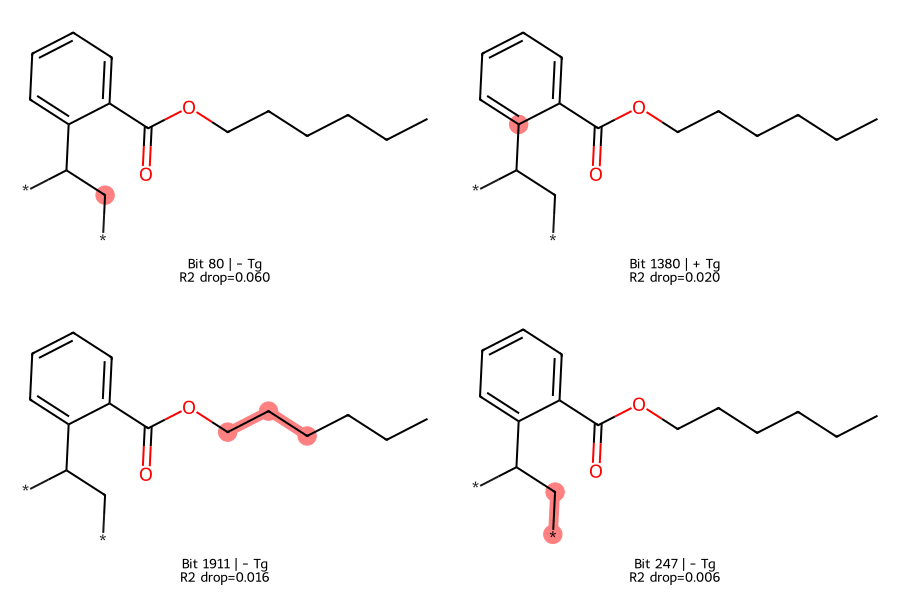


FFV — REPRESENTATIVE IMPORTANT MORGAN ENVIRONMENTS


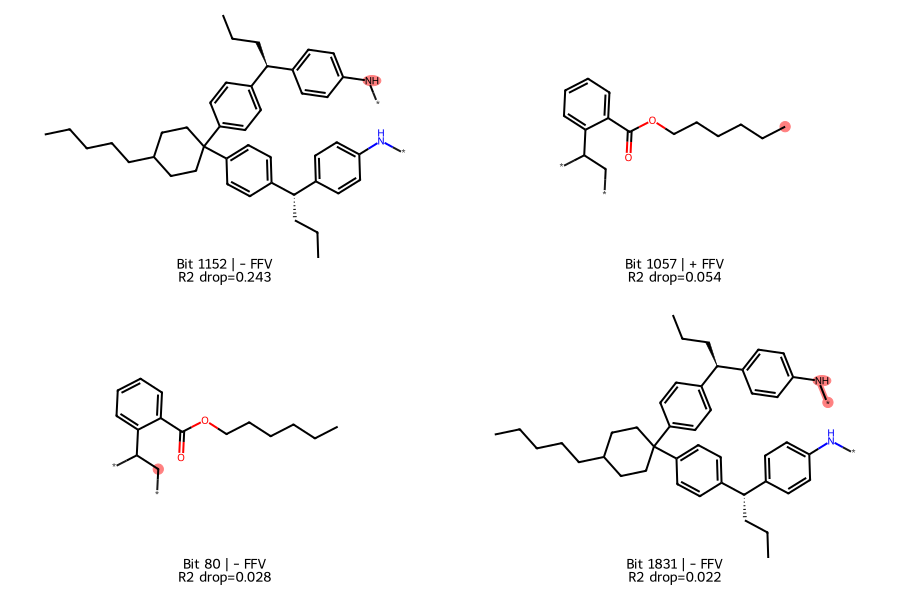


Tc — REPRESENTATIVE IMPORTANT MORGAN ENVIRONMENTS


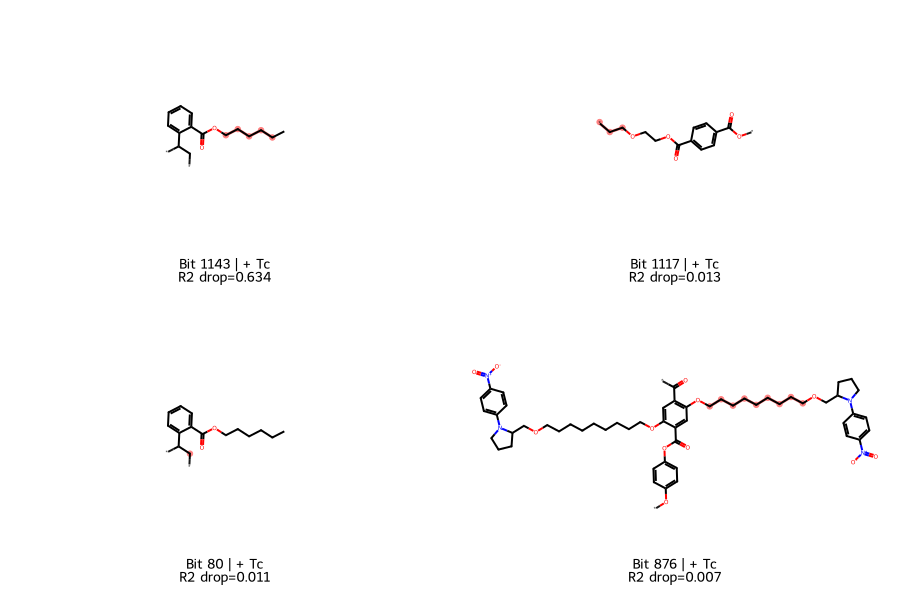


Rg — REPRESENTATIVE IMPORTANT MORGAN ENVIRONMENTS


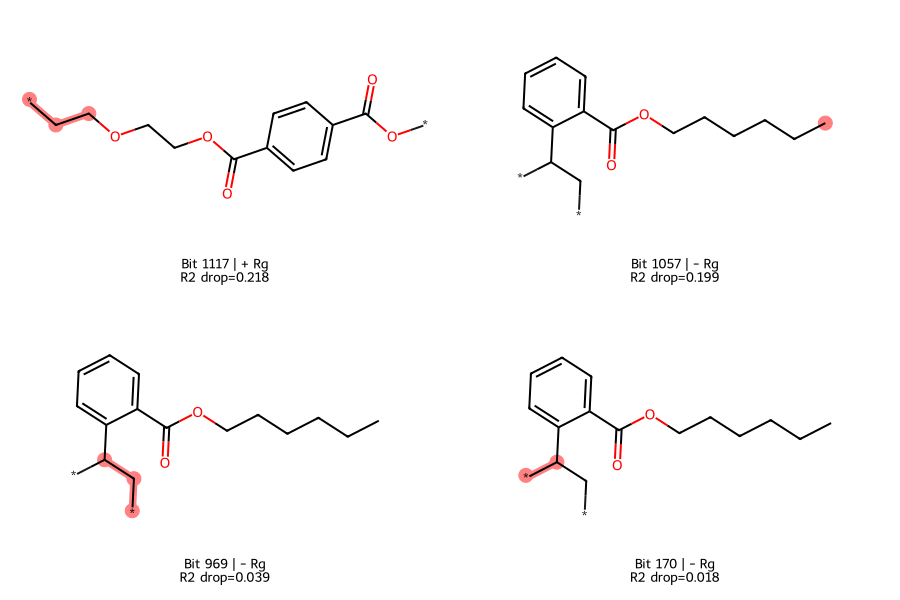

In [37]:
for target in [
    "Tg",
    "FFV",
    "Tc",
    "Rg"
]:

    print(
        "\n"
        + "=" * 100
    )

    print(
        f"{target} — REPRESENTATIVE "
        f"IMPORTANT MORGAN ENVIRONMENTS"
    )


    target_features = (
        morgan_motif_atlas[
            morgan_motif_atlas[
                "Target"
            ] == target
        ]
        .head(
            TOP_VISUAL_BITS_PER_TARGET
        )
    )


    mols = []
    legends = []
    highlight_atoms = []
    highlight_bonds = []


    for _, feature_row in (
        target_features.iterrows()
    ):

        bit_idx = int(
            feature_row[
                "Morgan_index"
            ]
        )

        dominant_fragment = (
            feature_row[
                "Dominant_fragment"
            ]
        )

        dominant_radius = int(
            feature_row[
                "Dominant_radius"
            ]
        )


        occurrence = (
            morgan_environment_occurrences[
                (
                    morgan_environment_occurrences[
                        "Morgan_index"
                    ]
                    == bit_idx
                )
                &
                (
                    morgan_environment_occurrences[
                        "Fragment_SMILES"
                    ]
                    == dominant_fragment
                )
                &
                (
                    morgan_environment_occurrences[
                        "Radius"
                    ]
                    == dominant_radius
                )
            ]
            .iloc[0]
        )


        mol = Chem.MolFromSmiles(
            occurrence[
                "SMILES"
            ]
        )


        atoms, bonds = (
            get_environment_atoms_bonds(
                mol,
                occurrence[
                    "Center_atom_index"
                ],
                occurrence[
                    "Radius"
                ]
            )
        )


        direction_symbol = (
            "+"
            if feature_row[
                "Train_Spearman_rho"
            ] > 0
            else "-"
        )


        legend = (
            f"Bit {bit_idx} | "
            f"{direction_symbol} {target}\n"
            f"R2 drop="
            f"{feature_row['Holdout_R2_Drop_Mean']:.3f}"
        )


        mols.append(
            mol
        )

        legends.append(
            legend
        )

        highlight_atoms.append(
            atoms
        )

        highlight_bonds.append(
            bonds
        )


    image = Draw.MolsToGridImage(
        mols,
        molsPerRow=2,
        subImgSize=(
            450,
            300
        ),
        legends=legends,
        highlightAtomLists=
            highlight_atoms,
        highlightBondLists=
            highlight_bonds,
        useSVG=False
    )


    display(
        image
    )

# Part D — Final Polymer Informatics Atlas

##  Integrated Chemical-Space Representation

A common two-dimensional chemical-space map is constructed for all 7,973 polymers.

The map is intended for visualization and synthesis rather than predictive model fitting.

Two complementary information sources are combined:

- the 36 global interpretable descriptors;
- a compressed representation of the 2,048 count-Morgan structural features.

The Morgan block is reduced using TruncatedSVD.

The two feature blocks are standardized independently before combination so that differences in dimensionality and numerical scale do not allow one representation family to dominate solely because it contains more columns.

The resulting integrated representation is embedded into two dimensions using UMAP.

No property values, prediction errors, uncertainty values, or target labels are used to construct the embedding.

Consequently, property and reliability overlays can be interpreted as post-hoc organization of an independently constructed structural map.

UMAP coordinates are used only as a visualization of neighborhood structure. Distances on the two-dimensional map should not be interpreted as exact quantitative chemical similarities.

In [38]:
%pip install -q umap-learn

In [39]:
# ============================================================
# Integrated unsupervised atlas representation
# ============================================================

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

ATLAS_MORGAN_COMPONENTS = 64

atlas_morgan_svd = TruncatedSVD(
    n_components=ATLAS_MORGAN_COMPONENTS,
    random_state=42
)

X_atlas_morgan = (
    atlas_morgan_svd.fit_transform(
        X_morgan
    )
)


atlas_interpretable_scaler = (
    StandardScaler()
)

atlas_morgan_scaler = (
    StandardScaler()
)


X_atlas_interpretable = (
    atlas_interpretable_scaler
    .fit_transform(
        X_interpretable
    )
)

X_atlas_morgan_scaled = (
    atlas_morgan_scaler
    .fit_transform(
        X_atlas_morgan
    )
)


# Equalize average block contribution.
X_atlas_interpretable *= (
    1
    /
    np.sqrt(
        X_atlas_interpretable.shape[1]
    )
)

X_atlas_morgan_scaled *= (
    1
    /
    np.sqrt(
        X_atlas_morgan_scaled.shape[1]
    )
)


X_atlas_integrated = np.hstack([
    X_atlas_interpretable,
    X_atlas_morgan_scaled
])


print("INTEGRATED ATLAS REPRESENTATION")
print("=" * 85)

print(
    f"Interpretable block: "
    f"{X_atlas_interpretable.shape}"
)

print(
    f"Morgan latent block: "
    f"{X_atlas_morgan_scaled.shape}"
)

print(
    f"Integrated matrix:   "
    f"{X_atlas_integrated.shape}"
)

print(
    f"Morgan SVD variance retained: "
    f"{atlas_morgan_svd.explained_variance_ratio_.sum():.4f}"
)

print(
    f"NaN values: "
    f"{np.isnan(X_atlas_integrated).sum()}"
)

print(
    f"Infinite values: "
    f"{np.isinf(X_atlas_integrated).sum()}"
)

INTEGRATED ATLAS REPRESENTATION
Interpretable block: (7973, 36)
Morgan latent block: (7973, 64)
Integrated matrix:   (7973, 100)
Morgan SVD variance retained: 0.8574
NaN values: 0
Infinite values: 0


In [40]:
# ============================================================
# UMAP embedding
# ============================================================

atlas_umap = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.10,
    metric="euclidean",
    random_state=42
)

atlas_coordinates = (
    atlas_umap.fit_transform(
        X_atlas_integrated
    )
)


atlas_table = pd.DataFrame({
    "row_index":
        np.arange(
            len(metadata)
        ),

    "id":
        metadata["id"].to_numpy(),

    "SMILES":
        metadata["SMILES"].to_numpy(),

    "Atlas_1":
        atlas_coordinates[:, 0],

    "Atlas_2":
        atlas_coordinates[:, 1]
})


print("FINAL POLYMER ATLAS")
print("=" * 80)

print(
    f"Polymers mapped: "
    f"{len(atlas_table):,}"
)

print(
    f"Atlas dimensions: "
    f"{atlas_coordinates.shape}"
)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


FINAL POLYMER ATLAS
Polymers mapped: 7,973
Atlas dimensions: (7973, 2)


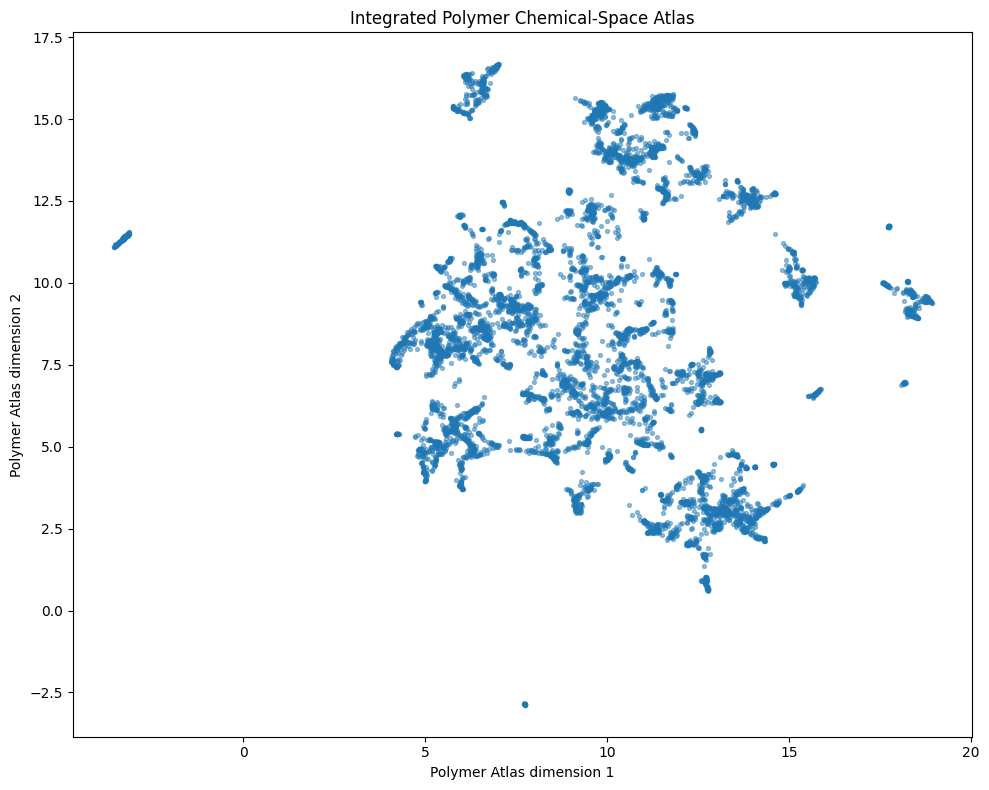

In [41]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(10, 8)
)

plt.scatter(
    atlas_table["Atlas_1"],
    atlas_table["Atlas_2"],
    s=8,
    alpha=0.45
)

plt.xlabel(
    "Polymer Atlas dimension 1"
)

plt.ylabel(
    "Polymer Atlas dimension 2"
)

plt.title(
    "Integrated Polymer Chemical-Space Atlas"
)

plt.tight_layout()
plt.show()

## Polymer-Property Landscapes

Experimental property measurements are projected onto the common unsupervised chemical-space embedding.

Only polymers with an observed value for the displayed property are colored.

The coordinates remain identical across all five panels.

This allows property organization to be compared against the same underlying representation of polymer chemistry.

Because target measurements are sparse and strongly property dependent, differences in visible coverage across panels reflect the original experimental availability rather than missing atlas coordinates.

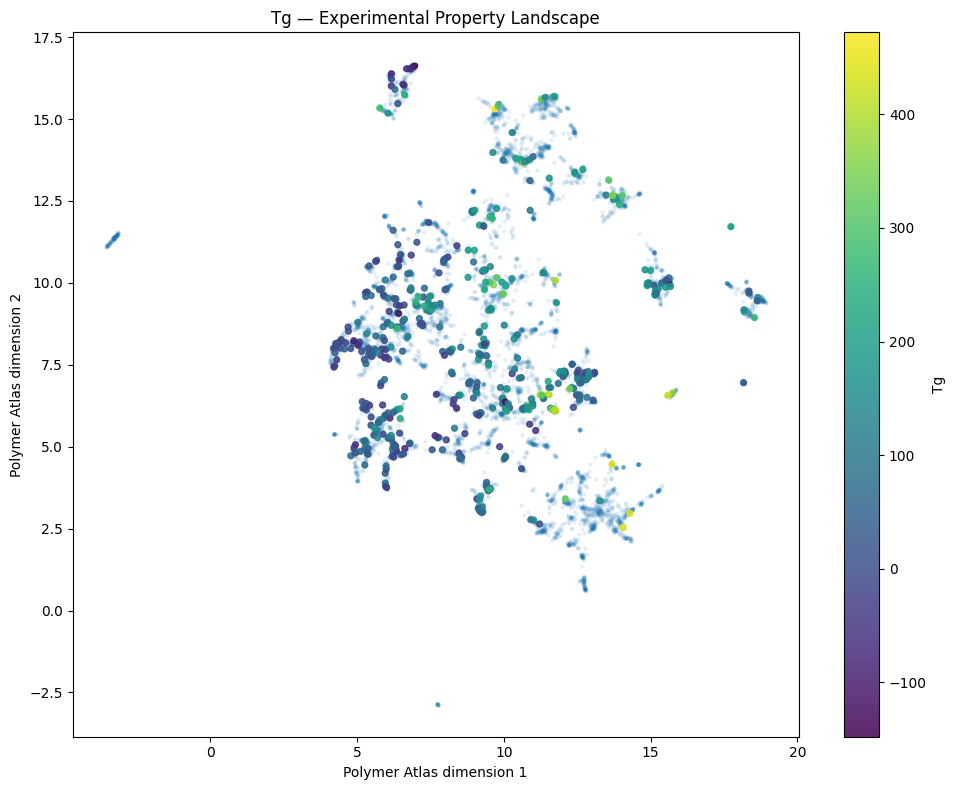

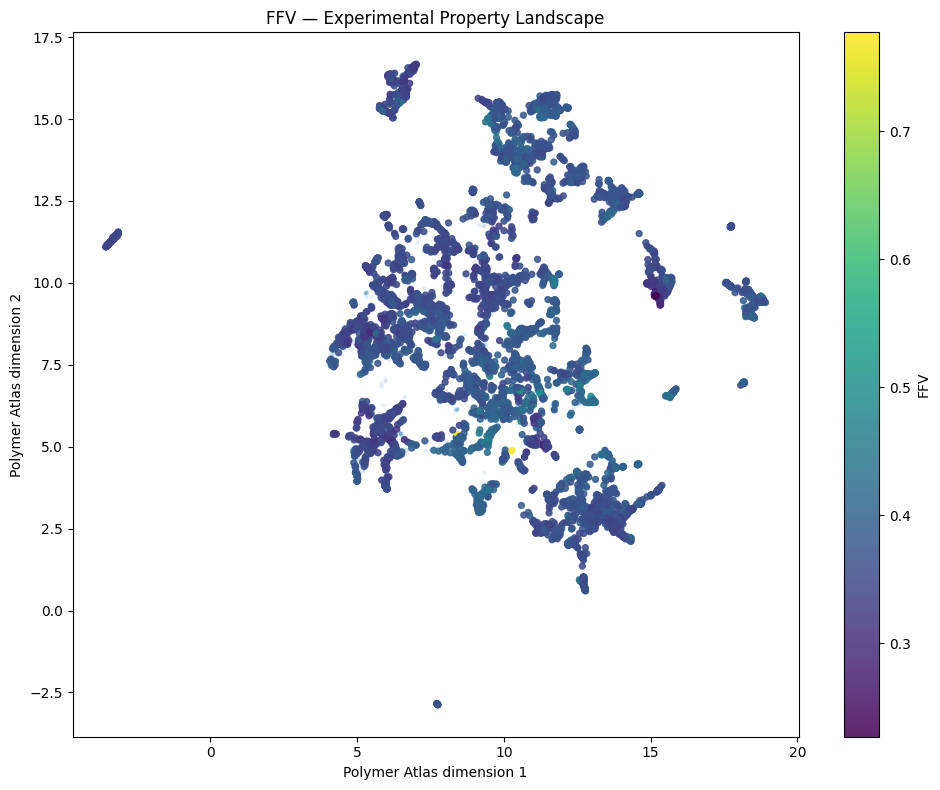

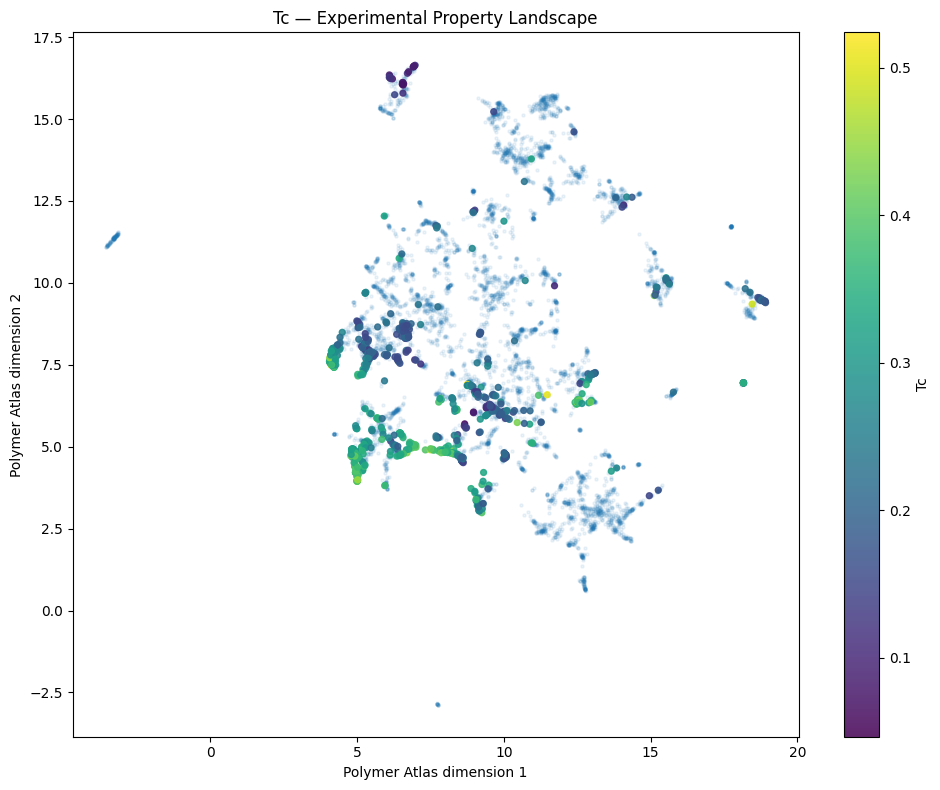

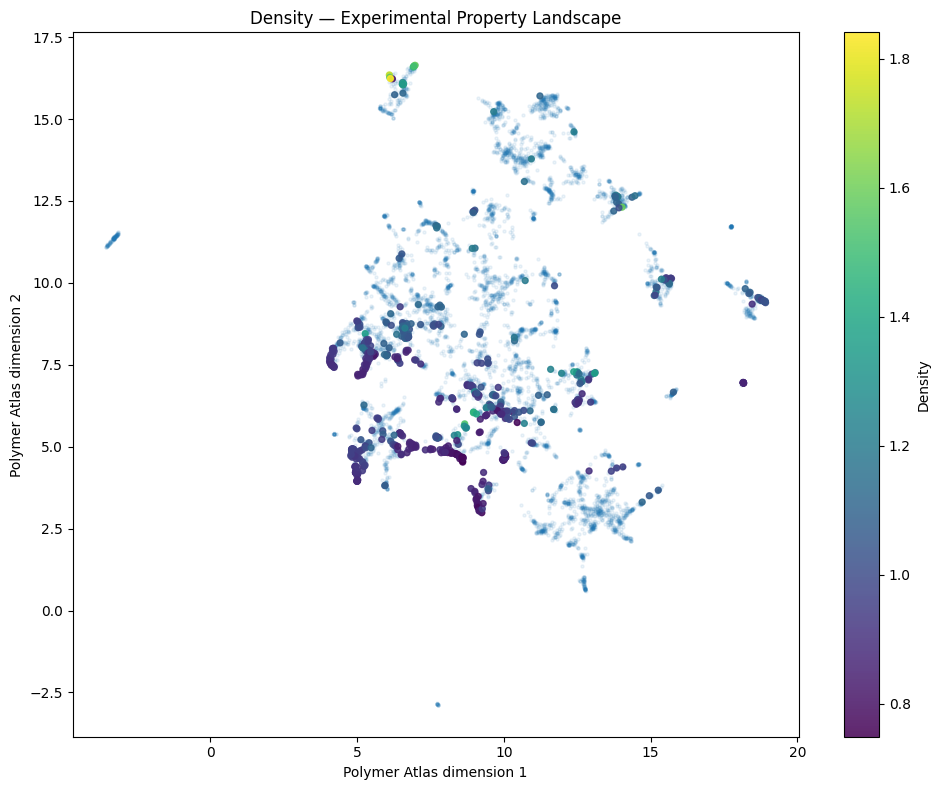

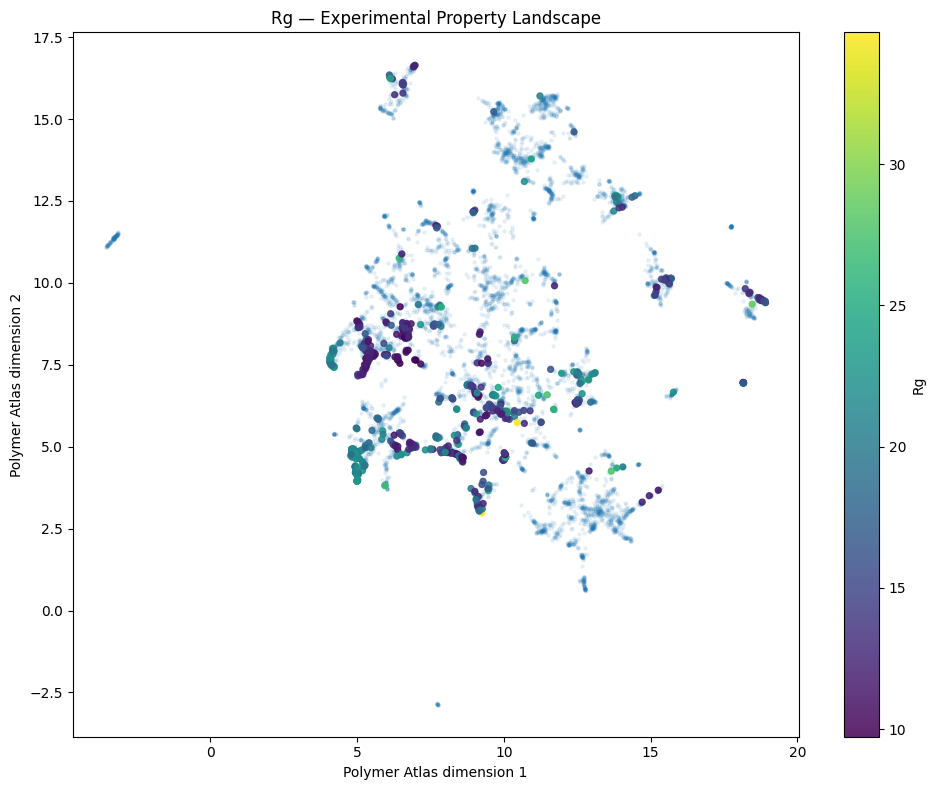

In [42]:
# ============================================================
# Five measured-property atlas maps
# ============================================================

for target in target_columns:

    available = (
        metadata[target]
        .notna()
        .to_numpy()
    )

    values = (
        metadata.loc[
            available,
            target
        ]
        .to_numpy(dtype=float)
    )

    coordinates = (
        atlas_coordinates[
            available
        ]
    )


    plt.figure(
        figsize=(10, 8)
    )

    plt.scatter(
        atlas_coordinates[:, 0],
        atlas_coordinates[:, 1],
        s=5,
        alpha=0.08
    )

    points = plt.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=values,
        s=18,
        alpha=0.85
    )

    plt.colorbar(
        points,
        label=target
    )

    plt.xlabel(
        "Polymer Atlas dimension 1"
    )

    plt.ylabel(
        "Polymer Atlas dimension 2"
    )

    plt.title(
        f"{target} — Experimental Property Landscape"
    )

    plt.tight_layout()
    plt.show()

In [43]:
# ============================================================
# Load Notebook 03 holdout predictions
# ============================================================

nb03_holdout_prediction_tables = {}

for target in target_columns:

    table = pd.read_csv(
        NB03_DIR
        / f"{target}_holdout_predictions.csv"
    )

    nb03_holdout_prediction_tables[
        target
    ] = table

    print(
        f"{target:8s}: "
        f"{len(table):,} predictions"
    )

Tg      : 103 predictions
FFV     : 1,406 predictions
Tc      : 148 predictions
Density : 123 predictions
Rg      : 123 predictions


In [44]:
for target, table in (
    nb03_holdout_prediction_tables.items()
):

    print(
        target,
        list(table.columns)
    )

Tg ['row_index', 'id', 'SMILES', 'Observed', 'Predicted', 'Residual', 'Absolute_Error']
FFV ['row_index', 'id', 'SMILES', 'Observed', 'Predicted', 'Residual', 'Absolute_Error']
Tc ['row_index', 'id', 'SMILES', 'Observed', 'Predicted', 'Residual', 'Absolute_Error']
Density ['row_index', 'id', 'SMILES', 'Observed', 'Predicted', 'Residual', 'Absolute_Error']
Rg ['row_index', 'id', 'SMILES', 'Observed', 'Predicted', 'Residual', 'Absolute_Error']


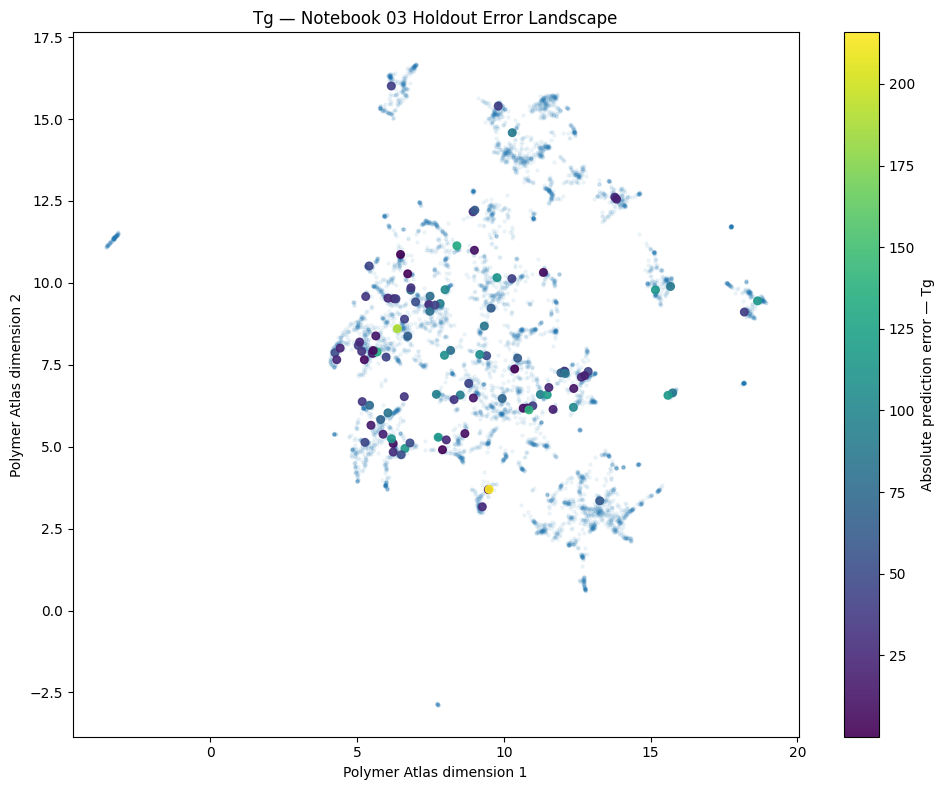

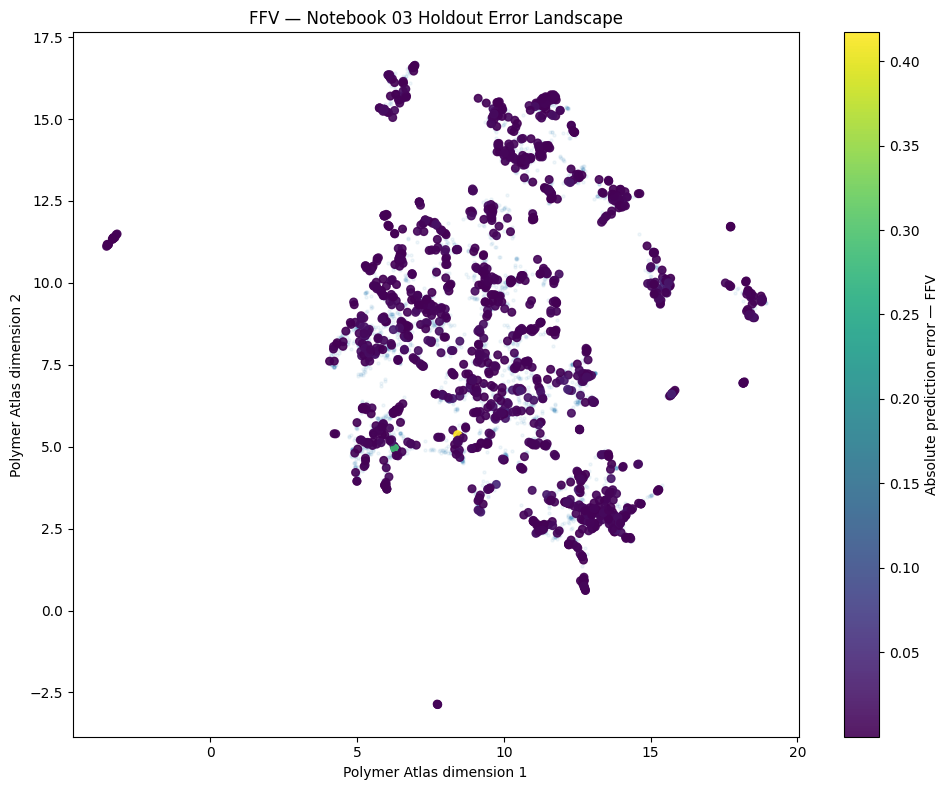

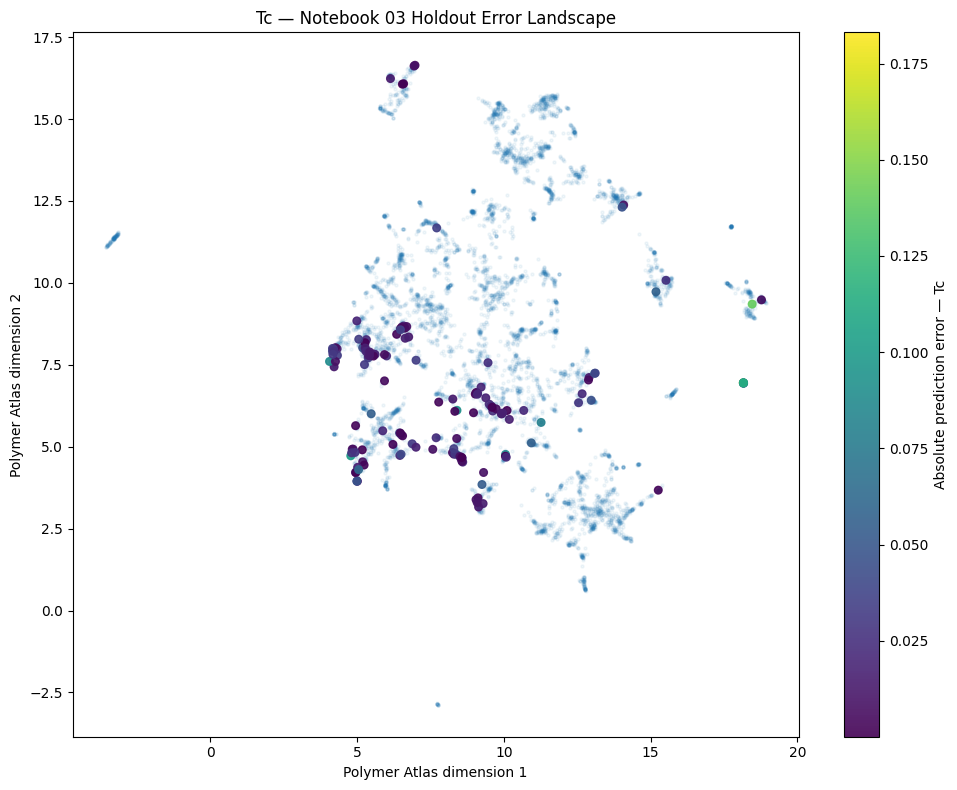

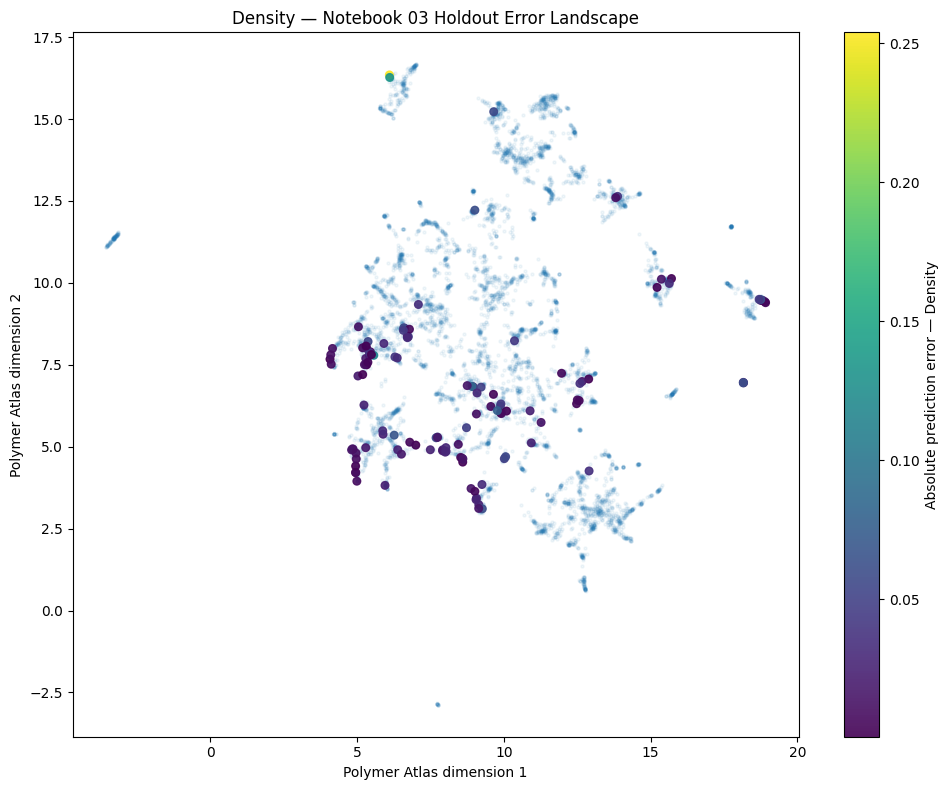

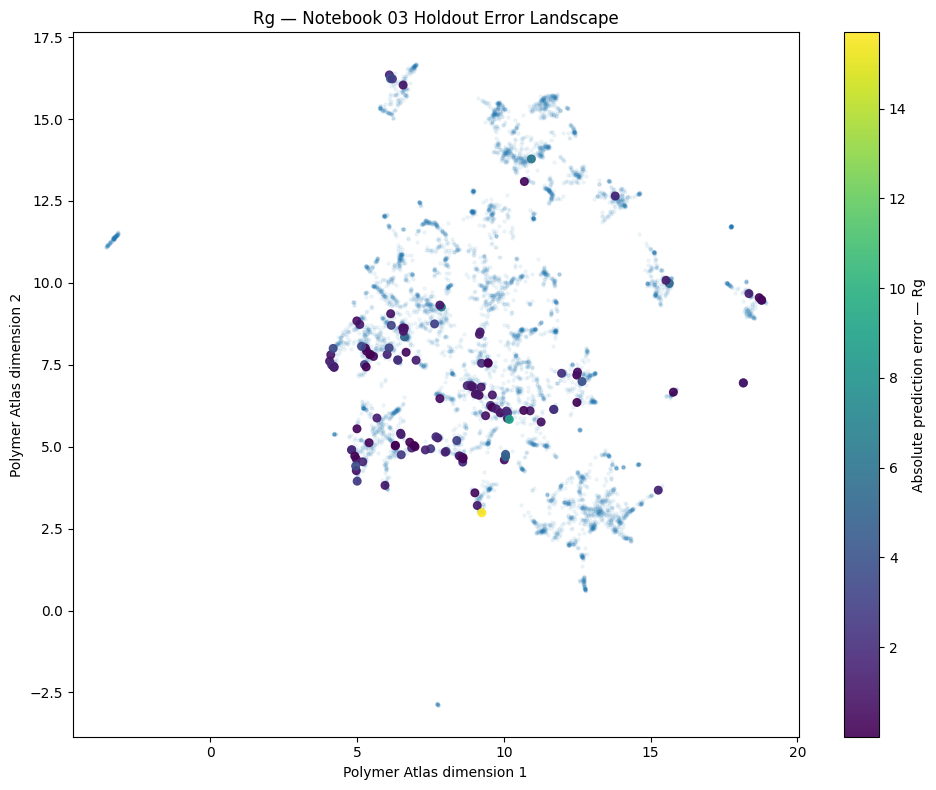

In [45]:
# ============================================================
# Prediction-error landscapes
# ============================================================

atlas_error_tables = {}

for target in target_columns:

    prediction_table = (
        nb03_holdout_prediction_tables[
            target
        ]
        .copy()
    )

    combined = prediction_table.merge(
        atlas_table[
            [
                "id",
                "Atlas_1",
                "Atlas_2"
            ]
        ],
        on="id",
        how="left",
        validate="one_to_one"
    )

    atlas_error_tables[
        target
    ] = combined


    plt.figure(
        figsize=(10, 8)
    )

    plt.scatter(
        atlas_table["Atlas_1"],
        atlas_table["Atlas_2"],
        s=5,
        alpha=0.06
    )

    points = plt.scatter(
        combined["Atlas_1"],
        combined["Atlas_2"],
        c=combined["Absolute_Error"],
        s=30,
        alpha=0.90
    )

    plt.colorbar(
        points,
        label=f"Absolute prediction error — {target}"
    )

    plt.xlabel(
        "Polymer Atlas dimension 1"
    )

    plt.ylabel(
        "Polymer Atlas dimension 2"
    )

    plt.title(
        f"{target} — Notebook 03 Holdout Error Landscape"
    )

    plt.tight_layout()
    plt.show()

In [46]:
# ============================================================
# Load Notebook 04 chemical-support tables
# ============================================================

nb04_chemistry_tables = {}

for target in target_columns:

    table = pd.read_csv(
        NB04_DIR
        / f"{target}_chemistry_aware_holdout.csv"
    )

    nb04_chemistry_tables[
        target
    ] = table

    print(
        f"{target:8s}: "
        f"{len(table):,} polymers"
    )

Tg      : 103 polymers
FFV     : 1,406 polymers
Tc      : 148 polymers
Density : 123 polymers
Rg      : 123 polymers


In [47]:
print(
    nb04_chemistry_tables[
        "Density"
    ].columns.tolist()
)

['row_index', 'id', 'SMILES', 'Observed', 'Predicted', 'Residual', 'Absolute_Error', 'max_train_similarity', 'top5_mean_similarity', 'n_train_sim_ge_0_5', 'n_train_sim_ge_0_7', 'n_train_sim_ge_0_8', 'Similarity_Regime', 'Normalized_Absolute_Error', 'Property_Extremeness']


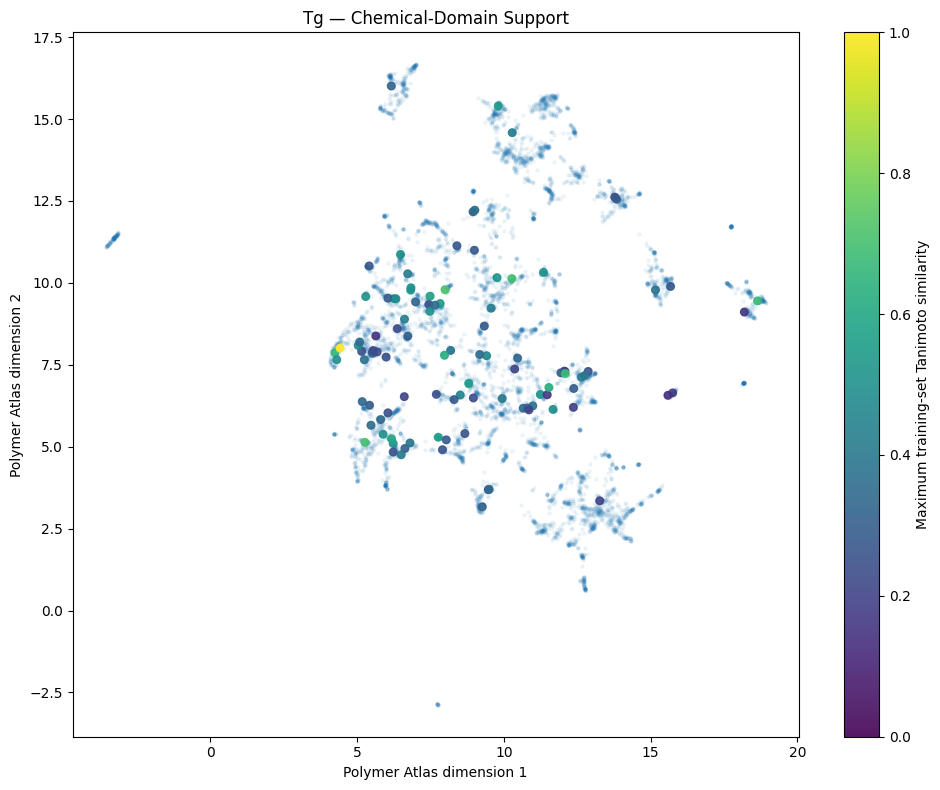

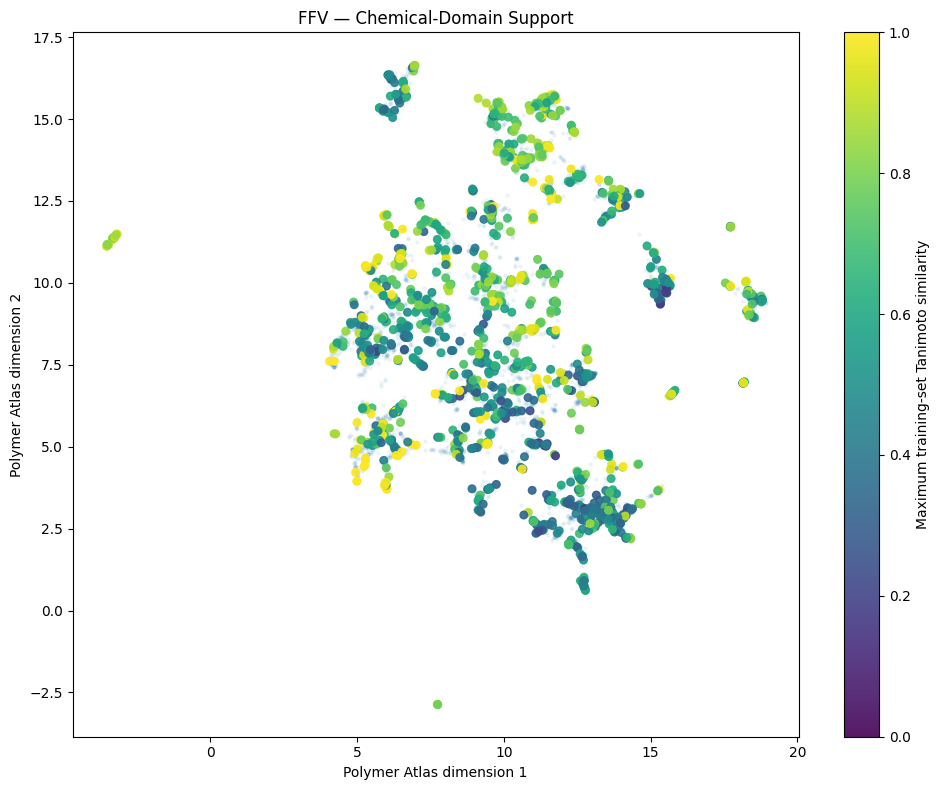

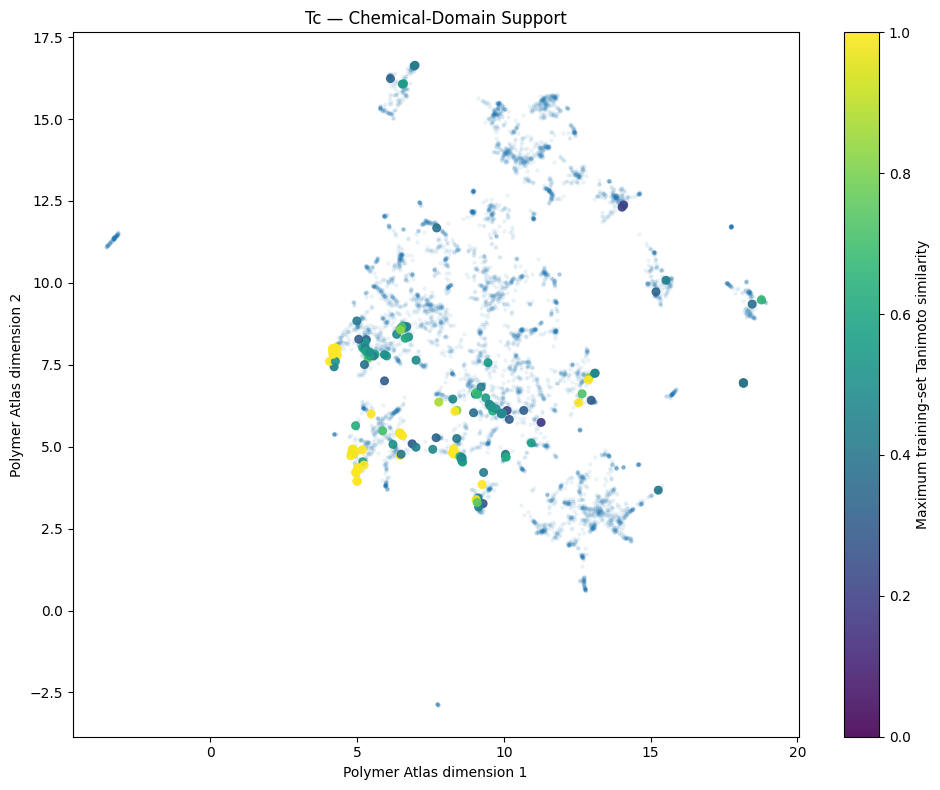

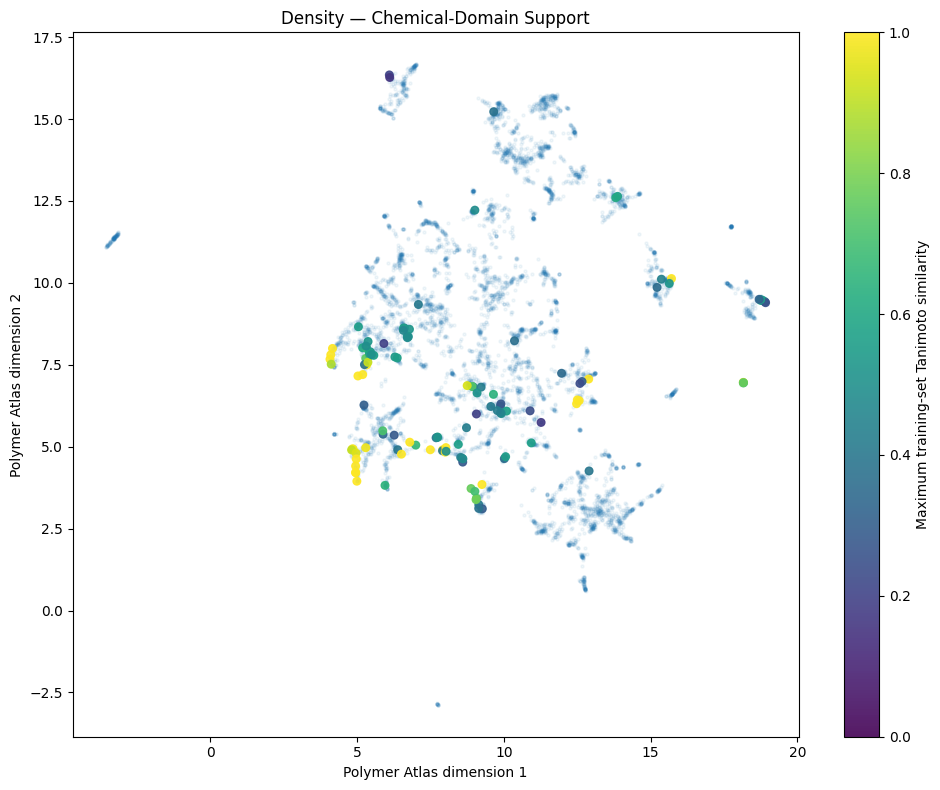

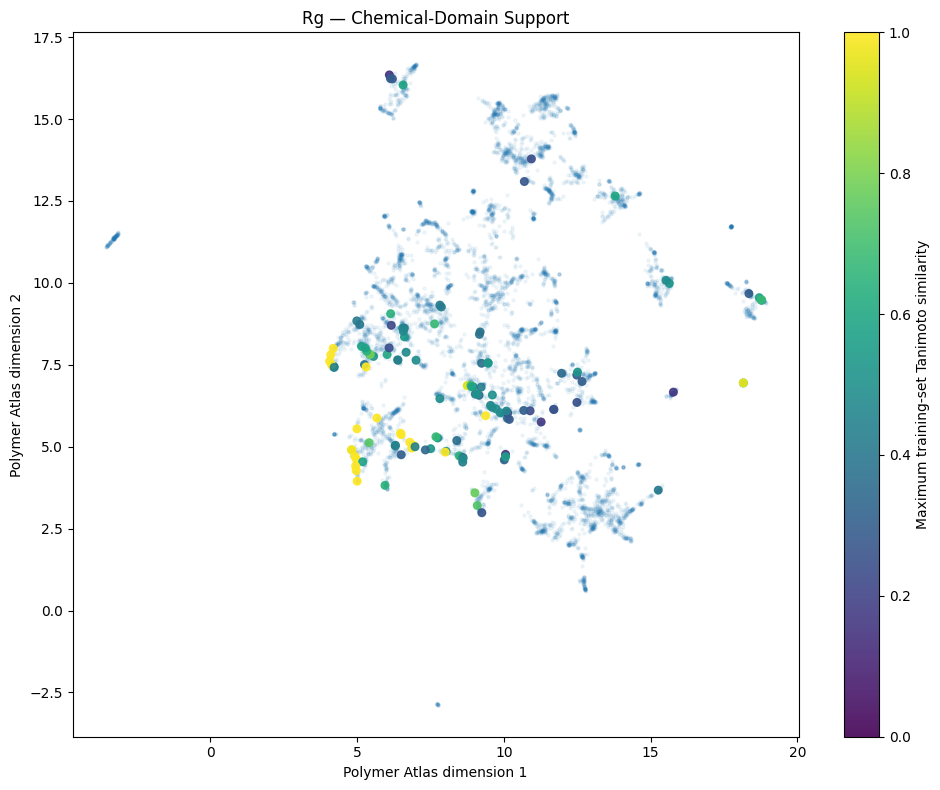

In [48]:
# ============================================================
# Chemical-support landscapes
# ============================================================

for target in target_columns:

    table = (
        nb04_chemistry_tables[
            target
        ]
        .copy()
    )

    combined = table.merge(
        atlas_table[
            [
                "id",
                "Atlas_1",
                "Atlas_2"
            ]
        ],
        on="id",
        how="left",
        validate="one_to_one"
    )

    plt.figure(
        figsize=(10, 8)
    )

    plt.scatter(
        atlas_table["Atlas_1"],
        atlas_table["Atlas_2"],
        s=5,
        alpha=0.06
    )

    points = plt.scatter(
        combined["Atlas_1"],
        combined["Atlas_2"],
        c=combined[
            "max_train_similarity"
        ],
        s=30,
        alpha=0.90,
        vmin=0,
        vmax=1
    )

    plt.colorbar(
        points,
        label="Maximum training-set Tanimoto similarity"
    )

    plt.xlabel(
        "Polymer Atlas dimension 1"
    )

    plt.ylabel(
        "Polymer Atlas dimension 2"
    )

    plt.title(
        f"{target} — Chemical-Domain Support"
    )

    plt.tight_layout()
    plt.show()

In [49]:
# ============================================================
# Notebook 05 reliability-test predictions
# ============================================================

nb05_reliability_tables = {}

for target in [
    "Tc",
    "Density",
    "Rg"
]:

    table = pd.read_csv(
        NB05_DIR
        / f"{target}_chemistry_reliability_test.csv"
    )

    nb05_reliability_tables[
        target
    ] = table

    print(
        f"{target:8s}: "
        f"{len(table):,}"
    )

Tc      : 70
Density : 65
Rg      : 66


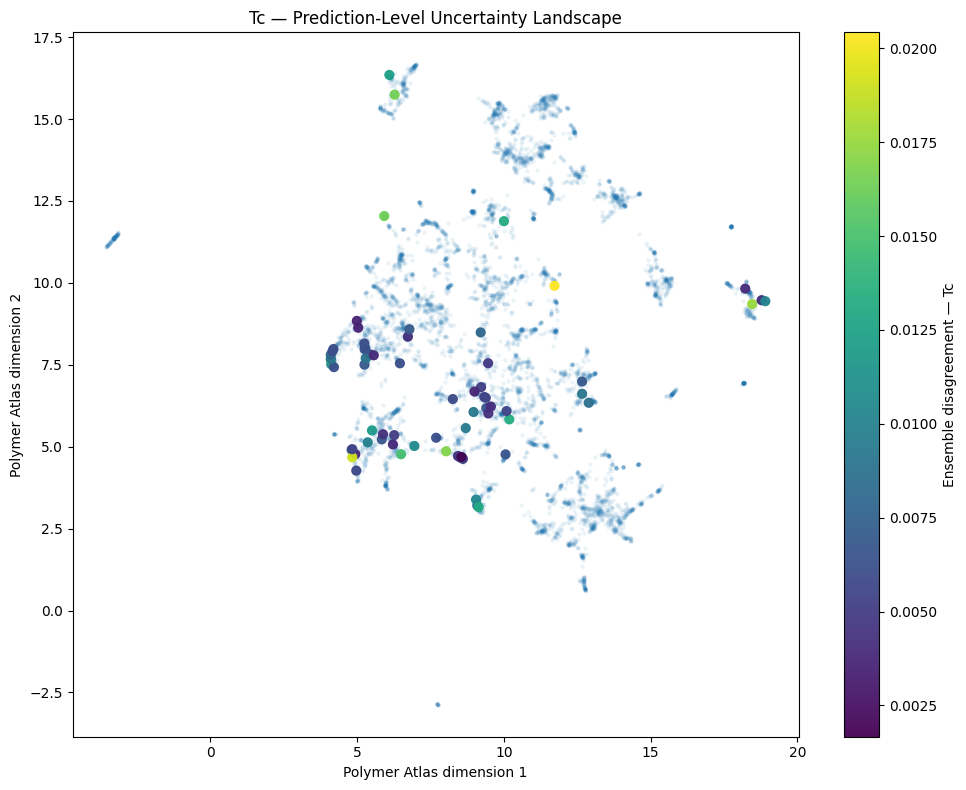

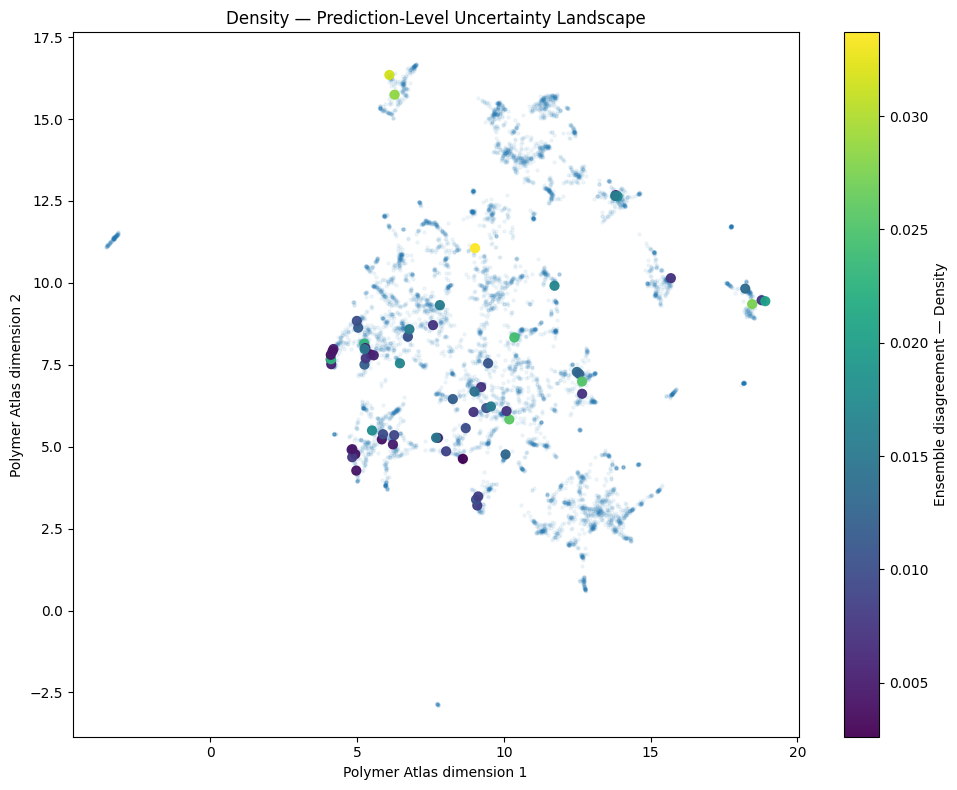

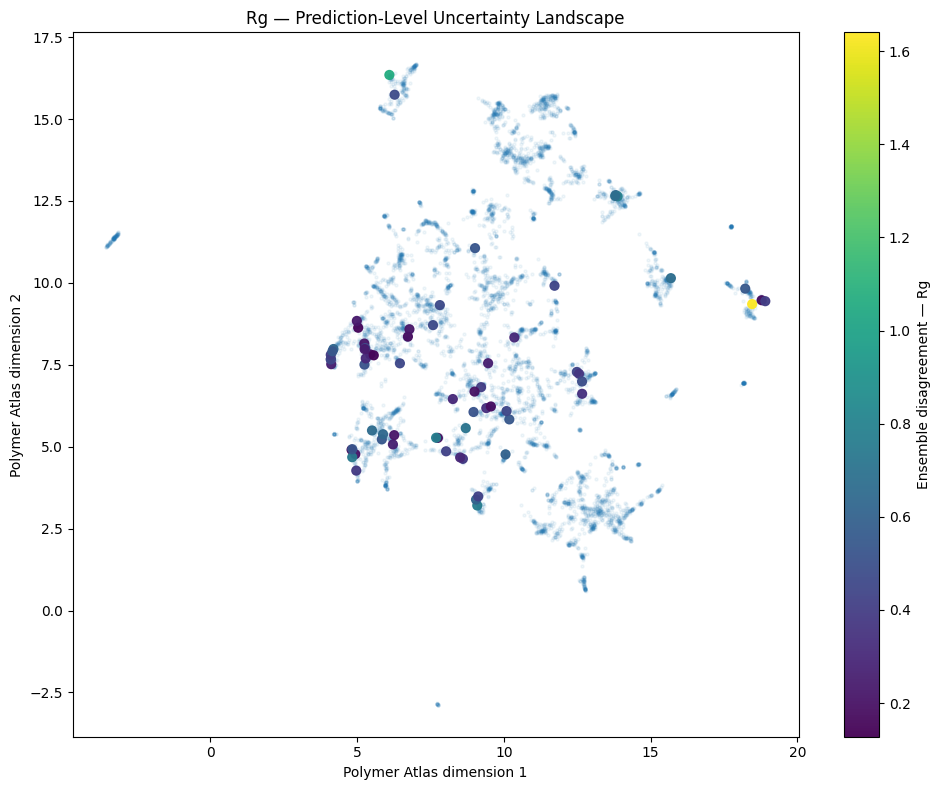

In [50]:
# ============================================================
# Ensemble-disagreement landscapes
# ============================================================

for target in [
    "Tc",
    "Density",
    "Rg"
]:

    table = (
        nb05_reliability_tables[
            target
        ]
        .copy()
    )

    combined = table.merge(
        atlas_table[
            [
                "row_index",
                "Atlas_1",
                "Atlas_2"
            ]
        ],
        on="row_index",
        how="left",
        validate="one_to_one"
    )


    plt.figure(
        figsize=(10, 8)
    )

    plt.scatter(
        atlas_table["Atlas_1"],
        atlas_table["Atlas_2"],
        s=5,
        alpha=0.06
    )

    points = plt.scatter(
        combined["Atlas_1"],
        combined["Atlas_2"],
        c=combined["Ensemble_Std"],
        s=40,
        alpha=0.95
    )

    plt.colorbar(
        points,
        label=f"Ensemble disagreement — {target}"
    )

    plt.xlabel(
        "Polymer Atlas dimension 1"
    )

    plt.ylabel(
        "Polymer Atlas dimension 2"
    )

    plt.title(
        f"{target} — Prediction-Level Uncertainty Landscape"
    )

    plt.tight_layout()
    plt.show()

##  Integrated Reliability Regimes

Chemical-domain support and neural-ensemble disagreement describe different aspects of predictive reliability.

For the Notebook 05 reliability-test polymers, both quantities are therefore considered jointly.

Each prediction is classified according to:

- lower versus higher chemical support;
- lower versus higher neural disagreement.

The ensemble-disagreement threshold is property specific and defined by the median test-set ensemble standard deviation.

This produces four descriptive reliability regimes:

1. high support / low disagreement;
2. high support / high disagreement;
3. low support / low disagreement;
4. low support / high disagreement.

These categories are descriptive and are not themselves calibrated uncertainty probabilities.

In [51]:
# ============================================================
# Integrated chemical-support / ensemble-reliability regimes
# ============================================================

integrated_reliability_tables = {}


for target in [
    "Tc",
    "Density",
    "Rg"
]:

    table = (
        nb05_reliability_tables[
            target
        ]
        .copy()
    )

    uncertainty_threshold = (
        table[
            "Ensemble_Std"
        ]
        .median()
    )

    table[
        "Chemical_Support"
    ] = np.where(
        table[
            "Max_Train_Similarity"
        ] >= 0.6,
        "Higher support",
        "Lower support"
    )

    table[
        "Model_Disagreement"
    ] = np.where(
        table[
            "Ensemble_Std"
        ]
        <= uncertainty_threshold,
        "Lower disagreement",
        "Higher disagreement"
    )

    table[
        "Reliability_Regime"
    ] = (
        table[
            "Chemical_Support"
        ]
        +
        " / "
        +
        table[
            "Model_Disagreement"
        ]
    )


    integrated_reliability_tables[
        target
    ] = table


    summary = (
        table
        .groupby(
            "Reliability_Regime",
            as_index=False
        )
        .agg(
            n=(
                "Absolute_Error",
                "size"
            ),

            Mean_similarity=(
                "Max_Train_Similarity",
                "mean"
            ),

            Mean_uncertainty=(
                "Ensemble_Std",
                "mean"
            ),

            Mean_absolute_error=(
                "Absolute_Error",
                "mean"
            )
        )
    )


    print(
        "\n"
        + "=" * 110
    )

    print(
        f"{target} — INTEGRATED "
        f"RELIABILITY REGIMES"
    )

    display(
        summary.round(4)
    )


Tc — INTEGRATED RELIABILITY REGIMES


,Reliability_Regime,n,Mean_similarity,Mean_uncertainty,Mean_absolute_error
0,Higher support / Higher disagreement,14,0.8658,0.0113,0.0438
1,Higher support / Lower disagreement,11,0.8771,0.0052,0.0206
2,Lower support / Higher disagreement,21,0.3972,0.0112,0.0280
3,Lower support / Lower disagreement,24,0.4695,0.0049,0.0174



Density — INTEGRATED RELIABILITY REGIMES


,Reliability_Regime,n,Mean_similarity,Mean_uncertainty,Mean_absolute_error
0,Higher support / Higher disagreement,6,0.8194,0.0179,0.0365
1,Higher support / Lower disagreement,19,0.8542,0.0063,0.0103
2,Lower support / Higher disagreement,26,0.4244,0.0177,0.0339
3,Lower support / Lower disagreement,14,0.4365,0.0069,0.0273



Rg — INTEGRATED RELIABILITY REGIMES


,Reliability_Regime,n,Mean_similarity,Mean_uncertainty,Mean_absolute_error
0,Higher support / Higher disagreement,14,0.8457,0.6755,2.2811
1,Higher support / Lower disagreement,11,0.8461,0.2752,0.6978
2,Lower support / Higher disagreement,19,0.3958,0.5796,1.7355
3,Lower support / Lower disagreement,22,0.4632,0.2782,2.0346


# Part E — Polymer Archetypes and Cross-Property Design Space

##  Representative Property Archetypes

Extreme experimental values can be scientifically interesting, but the single most extreme observation may be atypical, noisy, or chemically unusual.

Property archetypes are therefore defined using the upper and lower 10% of each measured property.

For each property and direction:

1. polymers belonging to the relevant decile are identified;
2. their centroid is calculated in the integrated 100-dimensional Atlas representation;
3. the polymer nearest to that centroid is selected as the representative archetype.

The resulting structures represent characteristic high- and low-property regions rather than individual numerical extremes.

These archetypes summarize the observed dataset and should not be interpreted as universally optimal polymer structures.

In [52]:
# ============================================================
# Representative high/low property archetypes
# ============================================================

from sklearn.metrics import pairwise_distances

property_archetype_rows = []

for target in target_columns:

    available_idx = np.flatnonzero(
        metadata[target]
        .notna()
        .to_numpy()
    )

    values = (
        metadata.loc[
            available_idx,
            target
        ]
        .to_numpy(dtype=float)
    )

    lower_threshold = np.quantile(
        values,
        0.10
    )

    upper_threshold = np.quantile(
        values,
        0.90
    )

    groups = {
        "Low":
            available_idx[
                values <= lower_threshold
            ],

        "High":
            available_idx[
                values >= upper_threshold
            ]
    }

    for direction, group_idx in (
        groups.items()
    ):

        X_group = (
            X_atlas_integrated[
                group_idx
            ]
        )

        centroid = (
            X_group.mean(
                axis=0,
                keepdims=True
            )
        )

        distances = (
            pairwise_distances(
                X_group,
                centroid,
                metric="euclidean"
            )
            .ravel()
        )

        representative_position = int(
            np.argmin(
                distances
            )
        )

        representative_idx = int(
            group_idx[
                representative_position
            ]
        )

        property_archetype_rows.append({
            "Target":
                target,

            "Archetype":
                direction,

            "row_index":
                representative_idx,

            "id":
                metadata.loc[
                    representative_idx,
                    "id"
                ],

            "Observed_value":
                metadata.loc[
                    representative_idx,
                    target
                ],

            "Decile_threshold":
                (
                    lower_threshold
                    if direction == "Low"
                    else upper_threshold
                ),

            "Group_n":
                len(
                    group_idx
                ),

            "Distance_to_group_centroid":
                distances[
                    representative_position
                ],

            "SMILES":
                metadata.loc[
                    representative_idx,
                    "SMILES"
                ]
        })


property_archetypes = pd.DataFrame(
    property_archetype_rows
)


print(
    "REPRESENTATIVE PROPERTY ARCHETYPES"
)

print(
    "=" * 120
)

display(
    property_archetypes[
        [
            "Target",
            "Archetype",
            "row_index",
            "Observed_value",
            "Decile_threshold",
            "Group_n",
            "Distance_to_group_centroid",
            "SMILES"
        ]
    ]
    .round(4)
)

REPRESENTATIVE PROPERTY ARCHETYPES


,Target,Archetype,row_index,Observed_value,Decile_threshold,Group_n,Distance_to_group_centroid,SMILES
0,Tg,Low,5391,-65.0854,-26.7583,52,0.7211,*CCCCCCCCCCOC(=O)C(=O)O*
1,Tg,High,1907,256.5965,245.2415,52,0.7045,*c1ccc(-c2ccc(-c3ccc(*)n3C)n2C)cn1
2,FFV,Low,1653,0.3272,0.3369,703,0.5668,*NC(CCC(=O)OCc1ccc(F)cc1)C(*)=O
3,FFV,High,7789,0.4294,0.4015,703,0.6487,*c1ccc(-c2nc3cc(C)ccc3o2)c(*)c1
4,Tc,Low,6614,0.1140,0.1525,75,0.5612,*CC(*)(C)C(=O)OC(C)C(F)(F)F
5,Tc,High,5193,0.3890,0.3801,74,0.3755,*CCCCCCCCCCCCCCC(=O)N*
6,Density,Low,7588,0.8045,0.8441,62,0.3804,*CCC([2H])C(*)([2H])C
7,Density,High,2959,1.3236,1.1546,62,0.6459,*CC(*)C(=O)Oc1ccc(Cl)cc1Cl
8,Rg,Low,2121,11.1619,11.3749,62,0.4074,*CC(*)(C)C(=O)OCC(CC)CCCC
9,Rg,High,5193,23.0093,22.4329,62,0.4964,*CCCCCCCCCCCCCCC(=O)N*


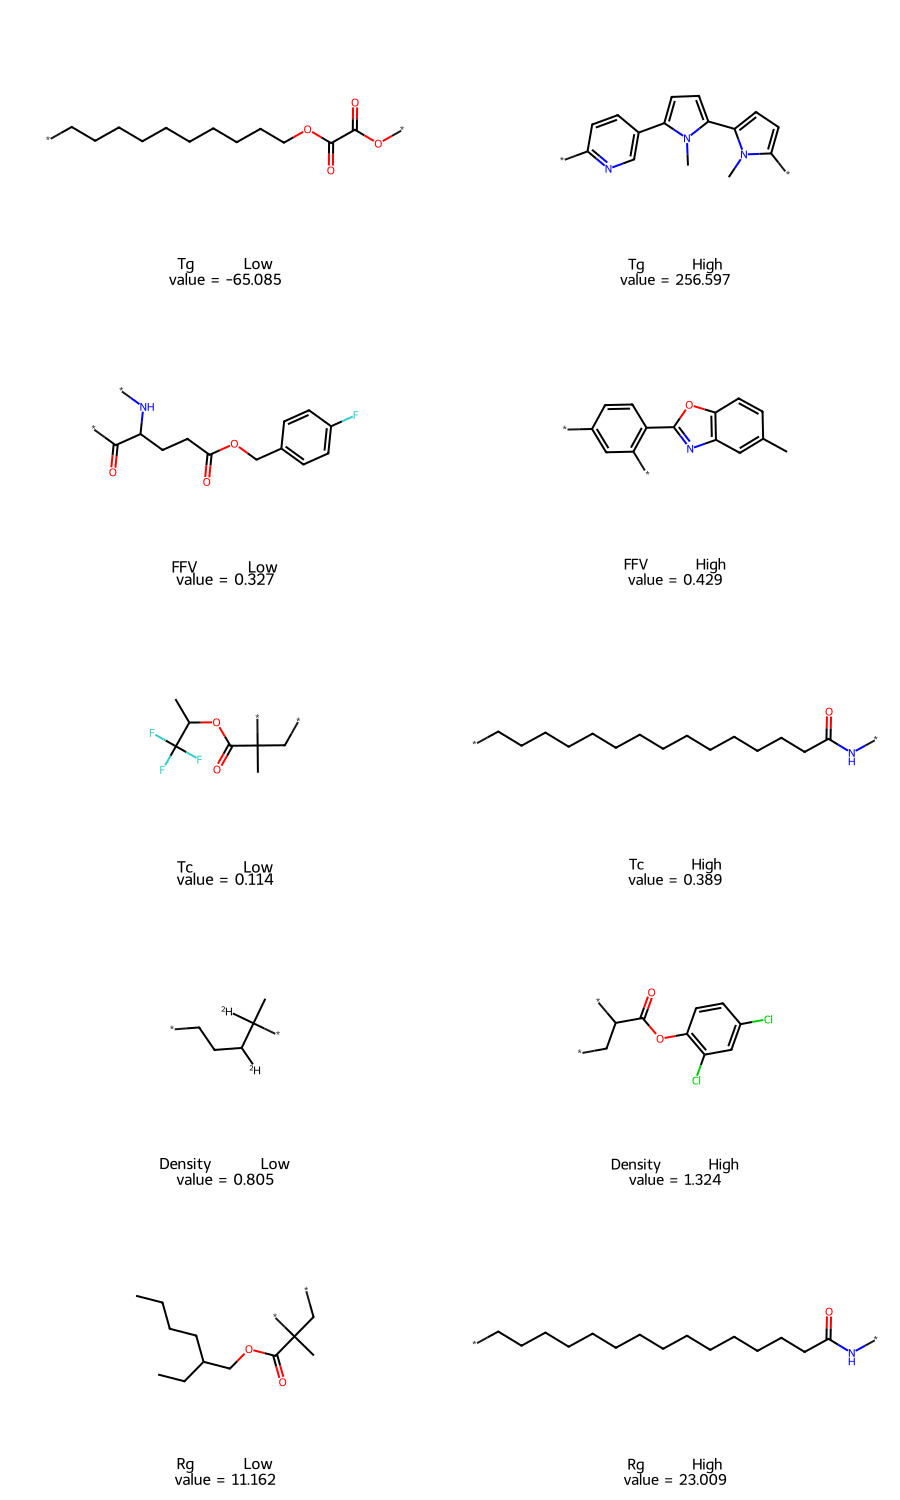

In [53]:
# ============================================================
# Draw representative property archetypes
# ============================================================

archetype_mols = []
archetype_legends = []

for _, row in (
    property_archetypes
    .iterrows()
):

    mol = Chem.MolFromSmiles(
        row["SMILES"]
    )

    archetype_mols.append(
        mol
    )

    archetype_legends.append(
        f"{row['Target']} — "
        f"{row['Archetype']}\n"
        f"value = "
        f"{row['Observed_value']:.3f}"
    )


archetype_image = (
    Draw.MolsToGridImage(
        archetype_mols,
        molsPerRow=2,
        subImgSize=(
            450,
            300
        ),
        legends=
            archetype_legends,
        useSVG=False
    )
)


display(
    archetype_image
)

##  Chemical Profiles of Property Archetypes

The representative high- and low-property polymers are compared using selected interpretable structural descriptors.

This provides a chemically readable summary of the structural differences represented by each pair of archetypes.

The profiles are descriptive rather than causal.

They complement the model-specific importance analyses from Parts B and C.

In [54]:
# ============================================================
# Archetype descriptor profiles
# ============================================================

archetype_profile_features = [
    "n_heavy_atoms",
    "hetero_fraction",
    "aromatic_fraction",
    "carbon_fraction",
    "N_fraction",
    "O_fraction",
    "S_fraction",
    "halogen_fraction",
    "ring_density",
    "density_carbonyl",
    "density_ester",
    "density_amide",
    "density_ether"
]


archetype_feature_indices = [
    interpretable_feature_names.index(
        feature
    )
    for feature in archetype_profile_features
]


archetype_profile_rows = []

for _, row in (
    property_archetypes
    .iterrows()
):

    idx = int(
        row["row_index"]
    )

    profile = {
        "Target":
            row["Target"],

        "Archetype":
            row["Archetype"],

        "Observed_value":
            row[
                "Observed_value"
            ]
    }

    for feature, j in zip(
        archetype_profile_features,
        archetype_feature_indices
    ):

        profile[
            feature
        ] = (
            X_interpretable[
                idx,
                j
            ]
        )

    archetype_profile_rows.append(
        profile
    )


archetype_profiles = pd.DataFrame(
    archetype_profile_rows
)


print(
    "PROPERTY ARCHETYPE CHEMICAL PROFILES"
)

print(
    "=" * 140
)

display(
    archetype_profiles.round(4)
)

PROPERTY ARCHETYPE CHEMICAL PROFILES


,Target,Archetype,Observed_value,n_heavy_atoms,hetero_fraction,aromatic_fraction,carbon_fraction,N_fraction,O_fraction,S_fraction,halogen_fraction,ring_density,density_carbonyl,density_ester,density_amide,density_ether
0,Tg,Low,-65.0854,16.0,0.2500,0.0000,0.7500,0.0000,0.2500,0.0,0.0000,0.0000,0.1250,0.0625,0.0000,0.0
1,Tg,High,256.5965,18.0,0.1667,0.8889,0.8333,0.1667,0.0000,0.0,0.0000,0.1667,0.0000,0.0000,0.0000,0.0
2,FFV,Low,0.3272,17.0,0.2941,0.3529,0.7059,0.0588,0.1765,0.0,0.0588,0.0588,0.1176,0.0588,0.0000,0.0
3,FFV,High,0.4294,16.0,0.1250,0.9375,0.8750,0.0625,0.0625,0.0,0.0000,0.1875,0.0000,0.0000,0.0000,0.0
4,Tc,Low,0.1140,12.0,0.4167,0.0000,0.5833,0.0000,0.1667,0.0,0.2500,0.0000,0.0833,0.0833,0.0000,0.0
5,Tc,High,0.3890,17.0,0.1176,0.0000,0.8824,0.0588,0.0588,0.0,0.0000,0.0000,0.0588,0.0000,0.0588,0.0
6,Density,Low,0.8045,5.0,0.0000,0.0000,1.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0
7,Density,High,1.3236,13.0,0.3077,0.4615,0.6923,0.0000,0.1538,0.0,0.1538,0.0769,0.0769,0.0769,0.0000,0.0
8,Rg,Low,11.1619,14.0,0.1429,0.0000,0.8571,0.0000,0.1429,0.0,0.0000,0.0000,0.0714,0.0714,0.0000,0.0
9,Rg,High,23.0093,17.0,0.1176,0.0000,0.8824,0.0588,0.0588,0.0,0.0000,0.0000,0.0588,0.0000,0.0588,0.0


##  Cross-Property Relationships

Tc, Density, and Rg have 531 polymers with complete measurements for all three properties.

This subset allows direct comparison of property relationships without mixing different polymer populations.

Pearson correlation is reported for approximately linear relationships, while Spearman correlation captures monotonic relationships.

These relationships are observational and should not be interpreted as causal coupling.

In [55]:
# ============================================================
# Complete Tc–Density–Rg property block
# ============================================================

complete_core_mask = (
    metadata[
        [
            "Tc",
            "Density",
            "Rg"
        ]
    ]
    .notna()
    .all(axis=1)
)

complete_core_idx = np.flatnonzero(
    complete_core_mask
    .to_numpy()
)


complete_core = (
    metadata.loc[
        complete_core_idx,
        [
            "id",
            "SMILES",
            "Tc",
            "Density",
            "Rg"
        ]
    ]
    .copy()
)


print(
    "COMPLETE Tc–Density–Rg BLOCK"
)

print(
    "=" * 80
)

print(
    f"Complete polymers: "
    f"{len(complete_core):,}"
)


print(
    "\nPearson correlation:"
)

display(
    complete_core[
        [
            "Tc",
            "Density",
            "Rg"
        ]
    ]
    .corr(
        method="pearson"
    )
    .round(4)
)


print(
    "\nSpearman correlation:"
)

display(
    complete_core[
        [
            "Tc",
            "Density",
            "Rg"
        ]
    ]
    .corr(
        method="spearman"
    )
    .round(4)
)

COMPLETE Tc–Density–Rg BLOCK
Complete polymers: 531

Pearson correlation:


,Tc,Density,Rg
Tc,1.0000,-0.4885,0.5530
Density,-0.4885,1.0000,0.0211
Rg,0.5530,0.0211,1.0000



Spearman correlation:


,Tc,Density,Rg
Tc,1.0000,-0.4538,0.5030
Density,-0.4538,1.0000,0.1166
Rg,0.5030,0.1166,1.0000


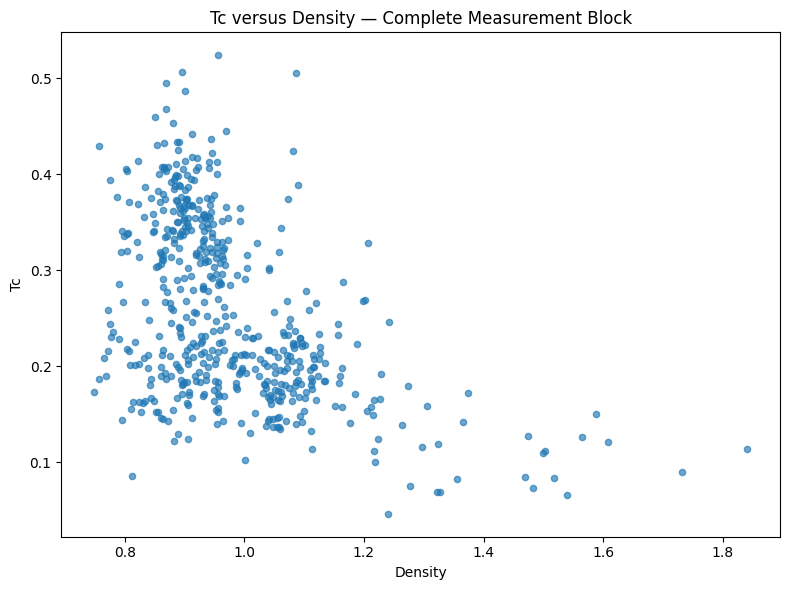

In [56]:
# ============================================================
# Tc vs Density
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    complete_core["Density"],
    complete_core["Tc"],
    s=20,
    alpha=0.65
)

plt.xlabel(
    "Density"
)

plt.ylabel(
    "Tc"
)

plt.title(
    "Tc versus Density — Complete Measurement Block"
)

plt.tight_layout()
plt.show()

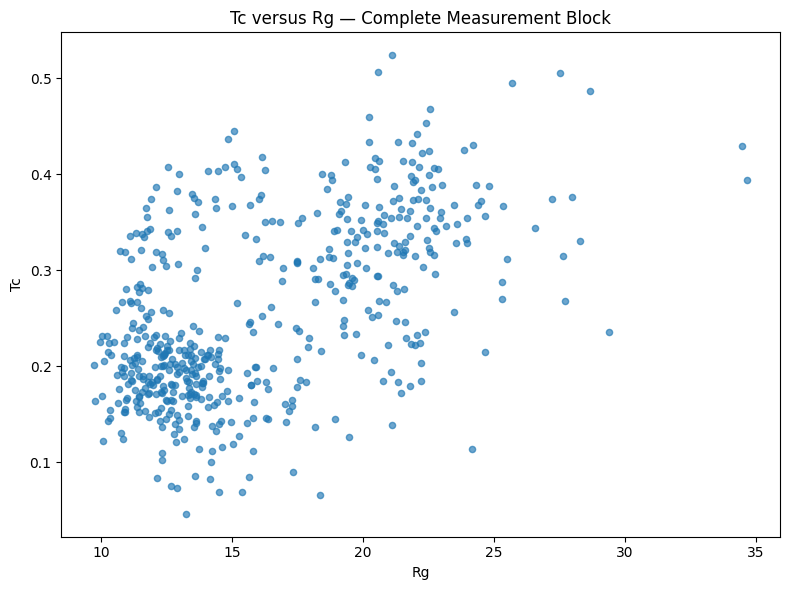

In [57]:
# ============================================================
# Tc vs Rg
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    complete_core["Rg"],
    complete_core["Tc"],
    s=20,
    alpha=0.65
)

plt.xlabel(
    "Rg"
)

plt.ylabel(
    "Tc"
)

plt.title(
    "Tc versus Rg — Complete Measurement Block"
)

plt.tight_layout()
plt.show()

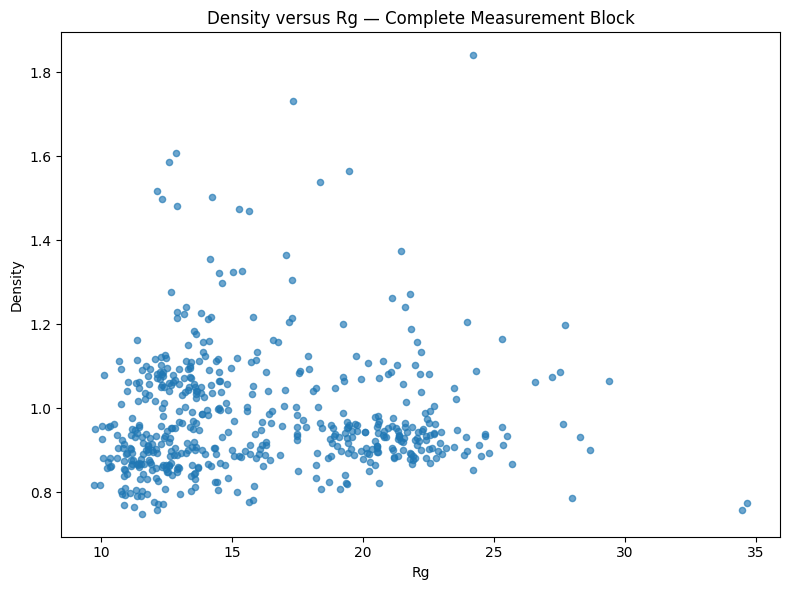

In [58]:
# ============================================================
# Density vs Rg
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    complete_core["Rg"],
    complete_core["Density"],
    s=20,
    alpha=0.65
)

plt.xlabel(
    "Rg"
)

plt.ylabel(
    "Density"
)

plt.title(
    "Density versus Rg — Complete Measurement Block"
)

plt.tight_layout()
plt.show()

##  Illustrative Multi-Objective Design Scenario

A Polymer Informatics Atlas can also be used to identify trade-offs between desirable property combinations.

Because the preferred direction of many polymer properties depends on application, no universal multi-objective ranking is imposed.

One illustrative scenario is considered:

> **maximize Tc while minimizing Density**

This corresponds conceptually to a lightweight polymer with comparatively high thermal transport.

A polymer is Pareto optimal under this scenario if no other measured polymer has:

- equal or higher Tc;
- and equal or lower Density;

with at least one strict improvement.

The resulting Pareto front represents observed trade-offs within the available dataset rather than experimentally validated optimal materials.

In [59]:
# ============================================================
# Pareto front: maximize Tc, minimize Density
# ============================================================

pareto_data = (
    complete_core[
        [
            "id",
            "SMILES",
            "Tc",
            "Density",
            "Rg"
        ]
    ]
    .reset_index(
        drop=True
    )
)


tc_values = (
    pareto_data[
        "Tc"
    ]
    .to_numpy()
)

density_values = (
    pareto_data[
        "Density"
    ]
    .to_numpy()
)


is_pareto = np.ones(
    len(
        pareto_data
    ),
    dtype=bool
)


for i in range(
    len(
        pareto_data
    )
):

    dominated = (
        (
            tc_values
            >= tc_values[i]
        )
        &
        (
            density_values
            <= density_values[i]
        )
        &
        (
            (
                tc_values
                > tc_values[i]
            )
            |
            (
                density_values
                < density_values[i]
            )
        )
    )

    if dominated.any():

        is_pareto[
            i
        ] = False


pareto_data[
    "Pareto_optimal"
] = is_pareto


pareto_front = (
    pareto_data[
        pareto_data[
            "Pareto_optimal"
        ]
    ]
    .sort_values(
        "Density"
    )
    .reset_index(
        drop=True
    )
)


print(
    "ILLUSTRATIVE Tc–DENSITY PARETO FRONT"
)

print(
    "=" * 100
)

print(
    f"Complete polymers: "
    f"{len(pareto_data)}"
)

print(
    f"Pareto-optimal polymers: "
    f"{len(pareto_front)}"
)

display(
    pareto_front[
        [
            "id",
            "Tc",
            "Density",
            "Rg",
            "SMILES"
        ]
    ]
    .round(4)
)

ILLUSTRATIVE Tc–DENSITY PARETO FRONT
Complete polymers: 531
Pareto-optimal polymers: 7


,id,Tc,Density,Rg,SMILES
0,1204249965,0.1735,0.7487,11.5503,*CC(*)CC(C)(C)C
1,1730621528,0.1868,0.7571,12.1292,*CC(*)C(C)C
2,1599967213,0.4290,0.7574,34.4873,*c1ccc2ccc3c(*)cc(C#CC=C)c4ccc1c2c34
3,305318799,0.4600,0.8514,20.2399,*c1ccc2c(c1)C(CCCCCC)(CCCCCC)c1cc(-c3cc(CCCCCC...
4,1209050682,0.4948,0.8685,25.6841,*CCCCOC(=O)CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...
5,82977315,0.5070,0.8952,20.5775,*CCCCCCCCCCCCCCCCCCCCOC(=O)CCCCCCCC(=O)O*
6,1582377269,0.5240,0.9566,21.1027,*/C=C/c1cc(OCCCCCC)c(*)cc1OC


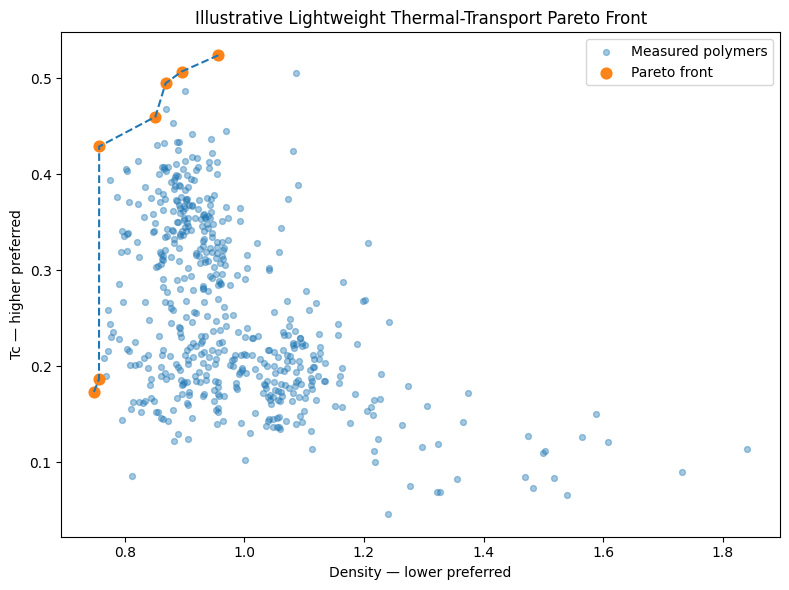

In [60]:
plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    pareto_data[
        "Density"
    ],
    pareto_data[
        "Tc"
    ],
    s=18,
    alpha=0.40,
    label="Measured polymers"
)

plt.scatter(
    pareto_front[
        "Density"
    ],
    pareto_front[
        "Tc"
    ],
    s=60,
    alpha=0.95,
    label="Pareto front"
)

plt.plot(
    pareto_front[
        "Density"
    ],
    pareto_front[
        "Tc"
    ],
    linestyle="--"
)

plt.xlabel(
    "Density — lower preferred"
)

plt.ylabel(
    "Tc — higher preferred"
)

plt.title(
    "Illustrative Lightweight Thermal-Transport Pareto Front"
)

plt.legend()

plt.tight_layout()
plt.show()

##  Chemistry of the Illustrative Pareto Front

The polymers on the Tc–Density Pareto front are compared with the complete Tc–Density–Rg population.

This identifies chemical characteristics enriched or depleted among polymers occupying the observed lightweight/high-Tc trade-off boundary.

The analysis is descriptive.

Because the Pareto front is derived from the same observed data, any apparent enrichment should be treated as a hypothesis for future experimental or computational validation rather than a discovered causal design rule.

In [61]:
# ============================================================
# Locate Pareto polymers in the master dataset
# ============================================================

id_to_row = dict(
    zip(
        metadata["id"],
        np.arange(
            len(metadata)
        )
    )
)

pareto_row_idx = np.array([
    id_to_row[x]
    for x in pareto_front[
        "id"
    ]
])


complete_core_row_idx = (
    complete_core_idx
)

In [62]:
pareto_descriptor_rows = []

for j, feature in enumerate(
    interpretable_feature_names
):

    pareto_values = (
        X_interpretable[
            pareto_row_idx,
            j
        ]
    )

    background_values = (
        X_interpretable[
            complete_core_row_idx,
            j
        ]
    )

    background_std = (
        np.std(
            background_values,
            ddof=1
        )
    )

    if background_std > 0:

        standardized_difference = (
            np.mean(
                pareto_values
            )
            -
            np.mean(
                background_values
            )
        ) / background_std

    else:

        standardized_difference = (
            np.nan
        )

    pareto_descriptor_rows.append({
        "Feature":
            feature,

        "Pareto_mean":
            np.mean(
                pareto_values
            ),

        "Background_mean":
            np.mean(
                background_values
            ),

        "Standardized_difference":
            standardized_difference,

        "Abs_standardized_difference":
            abs(
                standardized_difference
            )
            if np.isfinite(
                standardized_difference
            )
            else np.nan
    })


pareto_descriptor_comparison = (
    pd.DataFrame(
        pareto_descriptor_rows
    )
    .sort_values(
        "Abs_standardized_difference",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "CHEMICAL DESCRIPTORS ENRICHED ON THE "
    "Tc–DENSITY PARETO FRONT"
)

print(
    "=" * 120
)

display(
    pareto_descriptor_comparison
    .head(15)
    .round(4)
)

CHEMICAL DESCRIPTORS ENRICHED ON THE Tc–DENSITY PARETO FRONT


,Feature,Pareto_mean,Background_mean,Standardized_difference,Abs_standardized_difference
0,carbon_fraction,0.9529,0.833200,0.9511,0.9511
1,hetero_fraction,0.0471,0.166800,-0.9511,0.9511
2,density_carbonyl,0.0152,0.052500,-0.7932,0.7932
3,fg_c_c_double_bond,0.2857,0.077200,0.7250,0.7250
4,O_fraction,0.0471,0.104700,-0.6833,0.6833
5,n_C,22.7143,16.450100,0.6088,0.6088
6,N_fraction,0.0000,0.029200,-0.5969,0.5969
7,n_hetero,1.4286,3.035800,-0.5759,0.5759
8,n_N,0.0000,0.632800,-0.5656,0.5656
9,density_ester,0.0076,0.028600,-0.5128,0.5128


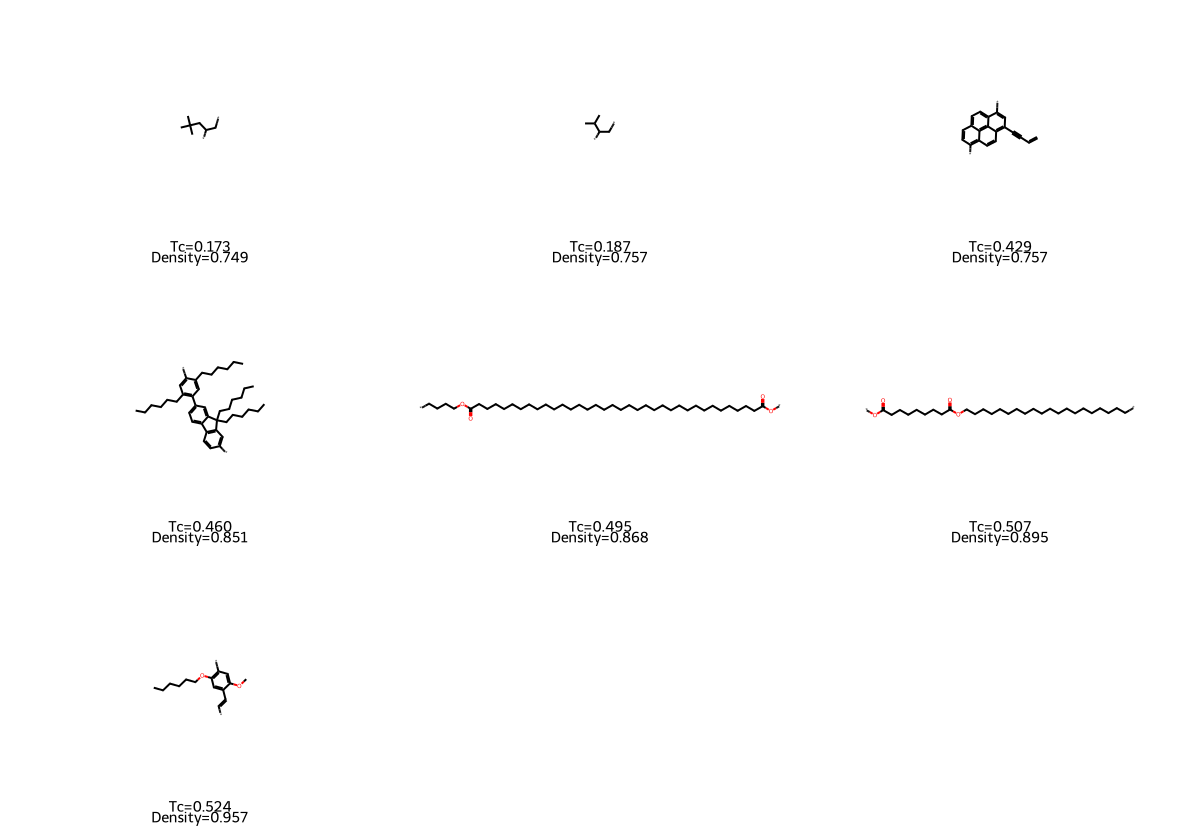

In [63]:
# ============================================================
# Draw illustrative Pareto-front polymers
# ============================================================

if len(
    pareto_front
) <= 25:

    pareto_mols = [
        Chem.MolFromSmiles(
            smiles
        )
        for smiles in pareto_front[
            "SMILES"
        ]
    ]

    pareto_legends = [
        (
            f"Tc={row.Tc:.3f}\n"
            f"Density={row.Density:.3f}"
        )
        for row in pareto_front.itertuples()
    ]

    pareto_image = (
        Draw.MolsToGridImage(
            pareto_mols,
            molsPerRow=3,
            subImgSize=(
                400,
                280
            ),
            legends=
                pareto_legends,
            useSVG=False
        )
    )

    display(
        pareto_image
    )

else:

    print(
        f"Pareto front contains "
        f"{len(pareto_front)} polymers; "
        f"structure grid skipped to avoid "
        f"an unreadable figure."
    )

In [64]:
# ============================================================
# Final property-specific scientific synthesis
# ============================================================

final_property_synthesis = pd.DataFrame({

    "Target": [
        "Tg",
        "FFV",
        "Tc",
        "Density",
        "Rg"
    ],

    "Primary_predictive_representation": [
        "Hybrid",
        "Hybrid",
        "Hybrid",
        "Interpretable",
        "Morgan r4"
    ],

    "Dominant_interpretation": [
        (
            "Ring density and aromaticity strongly "
            "associated with Tg; both global and local "
            "structure contribute."
        ),

        (
            "Oxygen/carbonyl chemistry is important, "
            "but local Morgan environments provide "
            "stronger predictive dependence."
        ),

        (
            "Prediction is dominated by specific local "
            "Morgan environments; major chemistry-domain "
            "generalization sensitivity."
        ),

        (
            "Global composition and interpretable "
            "descriptors capture most predictive signal."
        ),

        (
            "Local/topological environments dominate; "
            "global descriptor correlations are descriptive "
            "rather than part of the final model."
        )
    ],

    "Generalization_result": [
        (
            "No consistent dependence on Morgan "
            "nearest-neighbour similarity."
        ),

        (
            "Novelty increases typical error, but split "
            "comparisons are confounded by response extremes."
        ),

        (
            "Strong chemistry-separated performance loss."
        ),

        (
            "Moderate chemistry-related degradation "
            "while retaining high predictive performance."
        ),

        (
            "Moderate chemistry-domain sensitivity."
        )
    ],

    "Reliability_result": [
        "No Notebook 05 ensemble reliability model.",
        "No Notebook 05 ensemble reliability model.",
        (
            "Ensemble disagreement usefully ranks "
            "prediction difficulty."
        ),
        (
            "Both chemical support and ensemble "
            "disagreement are informative."
        ),
        (
            "Chemical support is more informative than "
            "ensemble disagreement."
        )
    ]
})


print(
    "FINAL PROPERTY-SPECIFIC SCIENTIFIC SYNTHESIS"
)

print(
    "=" * 150
)

display(
    final_property_synthesis
)

FINAL PROPERTY-SPECIFIC SCIENTIFIC SYNTHESIS


,Target,Primary_predictive_representation,Dominant_interpretation,Generalization_result,Reliability_result
0,Tg,Hybrid,Ring density and aromaticity strongly associat...,No consistent dependence on Morgan nearest-nei...,No Notebook 05 ensemble reliability model.
1,FFV,Hybrid,"Oxygen/carbonyl chemistry is important, but lo...","Novelty increases typical error, but split com...",No Notebook 05 ensemble reliability model.
2,Tc,Hybrid,Prediction is dominated by specific local Morg...,Strong chemistry-separated performance loss.,Ensemble disagreement usefully ranks predictio...
3,Density,Interpretable,Global composition and interpretable descripto...,Moderate chemistry-related degradation while r...,Both chemical support and ensemble disagreemen...
4,Rg,Morgan r4,Local/topological environments dominate; globa...,Moderate chemistry-domain sensitivity.,Chemical support is more informative than ense...


## Final Integrated Scientific Conclusions

The Polymer Informatics Atlas was developed as a six-notebook workflow progressing from chemical data auditing to predictive modelling, chemistry-aware generalization, uncertainty quantification, and final structure–property interpretation.

The final analysis shows that polymer properties cannot be represented adequately by one universal molecular representation, one model family, or one definition of predictive reliability.

### The five properties require different structural information

Glass-transition temperature, fractional free volume, thermal conductivity, Density, and radius of gyration exhibited distinct predictive behaviour.

**Tg** was best predicted using a Hybrid representation combining global descriptors and local Morgan structural environments.

Global structural rigidity was particularly important.

Ring density was the strongest interpretable model feature, and experimental Tg increased strongly with both ring density and aromatic fraction.

Local Morgan environments also contributed substantially, demonstrating that broad rigidity descriptors and more specific chemical topology provide complementary information.

---

**FFV** also required a Hybrid representation.

Global oxygen and carbonyl chemistry was important, with increasing oxygen fraction, carbonyl density, and ester character generally associated with lower observed FFV.

However, block-permutation analysis showed greater model dependence on local Morgan structure than on the entire interpretable descriptor block.

FFV therefore depends not only on elemental or functional-group composition but also on the local arrangement of those chemical environments.

---

**Tc** showed the strongest dependence on detailed local structure.

The Morgan block dominated Hybrid-model importance, and individual local environments produced very large decreases in predictive performance when permuted.

The most important validated Morgan feature produced an R² decrease of approximately 0.63.

Tc also suffered the strongest chemistry-separated generalization collapse among the five targets.

Thus, high random-split performance does not imply reliable extrapolation to structurally separated polymer families.

Tc is one of the clearest examples in the Atlas of a property that is predictable within supported chemical regions but strongly sensitive to local topology and chemical-domain shift.

---

**Density** represented the opposite predictive regime.

A linear Ridge model using only 36 interpretable descriptors achieved the strongest random-holdout performance in the project.

Composition-related descriptors — particularly heteroatom, carbon, halogen, and aromatic fractions — dominated the fitted model.

Density therefore provides the clearest example in this dataset of a polymer property whose predictive signal is captured predominantly by broad chemically interpretable descriptors rather than a high-dimensional local fingerprint.

---

**Rg** was best predicted using the Morgan representation alone.

Its final predictive model therefore depended explicitly on local/topological structural environments rather than the global descriptor block.

Two Morgan environments dominated the interpretation and showed opposite target associations.

Although several global descriptors correlate with Rg observationally, those descriptors were not inputs to the final selected predictor and should therefore be treated as descriptive chemistry rather than explanations of the fitted model.

---

### Important Morgan environments were chemically recoverable

The final Morgan representation was regenerated exactly from the archived Notebook 02 representation.

A random fingerprint audit produced zero mismatches, and recovery of 261,846 selected-bit environment occurrences produced zero fingerprint-count/environment-count mismatches.

Twenty-eight unique Morgan indices were selected for detailed chemical interpretation.

Among these:

- 16 showed low hashing ambiguity;
- 11 showed moderate ambiguity;
- only 1 showed high ambiguity.

Thus, most important hashed features possessed a strongly dominant atom-centred environment within this dataset.

Nevertheless, no selected hashed feature was interpreted as a universally unique chemical fragment.

Morgan environments are therefore described in terms of their dominant recovered chemistry rather than assigning a single absolute structural identity to every fingerprint index.

---

### Shared local environments reveal cross-property structural trade-offs

Several validated Morgan environments appeared in more than one property model.

Some showed opposite target associations across properties.

For example, structural environments associated with increasing Tc were sometimes associated with decreasing Tg or FFV.

These relationships suggest possible cross-property design trade-offs.

They should be treated as statistically supported hypotheses for polymer design rather than experimental causal rules.

---

### Chemical space is globally diverse but locally structured

The common Polymer Atlas combines interpretable descriptors and compressed Morgan structure without using target values.

The resulting unsupervised embedding shows a structured polymer landscape containing dense families, bridges between related chemistry, and isolated structural regions.

Property overlays are nonuniform across this space.

Tg, FFV, Tc, Density, and Rg each occupy different experimental and structural regions, reinforcing the conclusion that the five prediction tasks do not represent identical sampling of one homogeneous polymer population.

The Atlas coordinates are visualization coordinates rather than physical molecular variables.

No scientific conclusion depends on the numerical meaning of either UMAP axis.

---

### Prediction failures are also chemically structured

Projection of the frozen Notebook 03 holdout errors onto the Atlas showed that predictive error is not distributed identically across properties.

FFV prediction is accurate across most of its densely sampled domain but contains a small number of extreme failures.

Density similarly exhibits broadly low error with localized exceptions.

Tc contains chemically localized regions of substantially larger error, consistent with its chemistry-separated generalization penalty.

Rg also exhibits localized difficult regions and extreme failures.

Tg errors are distributed more broadly across its measured chemical domain.

Thus, a single global performance statistic is insufficient to describe polymer-model reliability.

---

### Chemistry-aware validation changes the interpretation of model quality

Random holdout performance was consistently more optimistic than a complete understanding of chemical generalization.

The most dramatic example was Tc, whose random-holdout R² exceeded 0.82 while chemistry-separated performance fell to approximately 0.33.

Density remained comparatively robust.

Rg showed intermediate chemical-domain sensitivity.

FFV showed a strong novelty-associated typical-error penalty, although direct split comparisons were influenced by differences in response distributions and extreme observations.

Tg did not show a consistent relationship between Morgan nearest-neighbour similarity and prediction error.

Chemical novelty therefore affects different polymer properties in different ways.

---

### Shared learning uses incomplete experimental data efficiently

Tc, Density, and Rg formed a strongly overlapping experimental block.

Masked multitask learning allowed polymers with partially missing labels to contribute to shared representation learning.

Masked multitask models consistently outperformed complete-case multitask models, demonstrating that partially labelled polymer measurements contain useful information.

However, gains over matched single-task neural models were small and seed dependent.

The principal benefit of multitask learning in this dataset is therefore efficient use of incomplete experimental records rather than a large universal accuracy increase.

---

### Predictive reliability is multidimensional

Notebook 05 demonstrated that chemical-domain support, neural-ensemble disagreement, and conformal calibration measure different aspects of reliability.

For Tc, ensemble disagreement predicted actual error even though nearest-neighbour chemical similarity did not.

For Density, chemical support, ensemble disagreement, and realized error were mutually consistent.

For Rg, chemical support was more informative than neural disagreement.

Consequently, no single reliability score is adequate for all polymer properties.

The most defensible predictive output combines:

**point prediction + calibrated conformal interval + model disagreement + chemical-domain support.**

---

### Conformal uncertainty provides the calibrated reliability layer

Nominal 90% fixed split-conformal intervals achieved approximately:

- 95.7% empirical coverage for Tc;
- 92.3% for Density;
- 98.5% for Rg.

Finite-sample confidence intervals showed that Tc and Density were compatible with the nominal coverage target, while Rg remained strongly conservative.

Directly scaling conformal intervals using ensemble disagreement did not improve the global coverage–efficiency trade-off.

Fixed absolute-residual split-conformal intervals were therefore retained as the primary calibrated interval method.

---

### Representative property archetypes reinforce the model interpretations

Representative high- and low-property structures were selected from experimental upper and lower deciles using proximity to their chemical-space centroids.

These archetypes support the statistical interpretation of the models.

High-Tg chemistry was substantially more aromatic and ring-rich than low-Tg chemistry.

High-Density chemistry contained substantially greater heteroatom, aromatic, and halogen character than the representative low-density structure.

FFV, Tc, and Rg archetypes displayed more topology-dependent structural differences, consistent with their stronger reliance on Morgan environments.

The archetypes summarize observed chemical regimes rather than defining universal structures for maximizing or minimizing a polymer property.

---

### Cross-property design involves genuine trade-offs

The 531 polymers with complete Tc, Density, and Rg measurements showed:

- moderate negative association between Tc and Density;
- moderate positive association between Tc and Rg;
- only weak direct association between Density and Rg.

An illustrative multi-objective design scenario — maximizing Tc while minimizing Density — produced a Pareto front containing seven observed polymers.

Relative to the complete measurement population, this small Pareto set was enriched in carbon-rich and C=C-containing chemistry and depleted in heteroatom-, oxygen-, carbonyl-, ester-, and amide-rich descriptors.

Because the Pareto set is small and the objective is application dependent, these differences are interpreted as design hypotheses rather than universal optimization rules.

---

### Final scientific conclusion

The central result of the Polymer Informatics Atlas is that **polymer-property prediction is property specific at every level**:

- the useful representation;
- the predictive model;
- the important chemistry;
- the response to chemical novelty;
- and the appropriate reliability signal.

Some properties, such as Density, are captured effectively by broad composition and interpretable structural descriptors.

Others, particularly Tc and Rg, depend much more strongly on detailed local molecular topology.

Hybrid representations are valuable for intermediate cases such as Tg and FFV.

Reliable polymer informatics therefore requires more than maximizing random-split predictive accuracy.

A scientifically defensible workflow should combine:

- chemically audited polymer representations;
- property-specific model selection;
- chemistry-aware generalization testing;
- explicit interpretation of structural drivers;
- calibrated predictive uncertainty;
- and structural-domain support.

The resulting Atlas is therefore not merely a collection of predictive models.

It is an integrated map of **polymer chemistry, structure–property relationships, model capability, generalization limits, and predictive reliability**.

## Limitations and Claim Boundaries

The Polymer Informatics Atlas provides a rigorous analysis of the available dataset, but several limitations define the appropriate scope of its conclusions.

### Observational rather than causal structure–property relationships

Feature importance, model coefficients, fingerprint associations, descriptor correlations, and Pareto enrichment analyses describe statistical relationships within the available dataset.

They do not establish that modifying a polymer by adding or removing a particular motif will causally change a property by a predictable amount.

Experimental validation remains necessary for causal design claims.

### Repeat-unit representation

Polymer structures are represented primarily through repeat-unit SMILES with wildcard polymerization connection points.

This representation captures repeat-unit chemistry and connectivity but does not explicitly encode all higher-level polymer variables such as:

- molecular-weight distribution;
- degree of polymerization;
- tacticity where unspecified;
- crystallinity;
- processing history;
- morphology;
- measurement conditions.

Some irreducible prediction error may therefore arise from physical information that is absent from the structural representation.

### Sparse and uneven target measurements

The five properties have highly unequal sample sizes and strongly different patterns of measurement overlap.

FFV is much more densely represented than the other properties.

Tc, Density, and Rg share a large measurement block, while Tg is largely independent.

Consequently, direct comparison of model performance or reliability between properties must account for differences in sample size and chemical coverage.

### Random holdout performance is not extrapolation performance

The Notebook 03 random holdouts estimate interpolation-like predictive performance under approximately random sampling.

Notebook 04 demonstrated that these estimates can be optimistic when chemically distinct polymer families are encountered.

No reported model should therefore be assumed reliable for arbitrary chemistry outside the measured structural domain.

### Hashed fingerprint interpretation

The Morgan representation is hashed.

Most selected important bits showed a strongly dominant recovered environment, but multiple underlying environments can contribute to the same hashed index.

Chemical labels assigned to Morgan features therefore refer to dominant representative environments rather than universal one-to-one feature identities.

### UMAP interpretation

The final Polymer Atlas is a nonlinear two-dimensional visualization.

UMAP is useful for displaying neighborhood structure but does not preserve every high-dimensional distance exactly.

The axes possess no direct physical interpretation, and scientific conclusions are not based solely on visual separation in the map.

### Neural-ensemble uncertainty

Variation among independently initialized neural networks measures model disagreement rather than complete predictive uncertainty.

It does not include every source of experimental, representation, or distributional uncertainty.

Its value was therefore tested empirically against realized prediction error rather than assumed.

### Conformal prediction

Split-conformal intervals provide marginal finite-sample coverage under exchangeability assumptions.

They do not guarantee the nominal coverage for every individual polymer family or every local region of chemical space.

Coverage within poorly represented chemical domains may differ from global coverage.

### Multi-objective design

The Tc–Density Pareto analysis is illustrative.

Different applications may prefer different directions or combinations of Tg, FFV, Tc, Density, Rg, mechanical behaviour, chemical stability, processability, cost, or other properties.

The seven-member Pareto front is therefore not a universal ranking of superior polymers.

### Future extension

Future work could incorporate:

- larger externally sourced polymer datasets;
- explicit processing and measurement-condition variables;
- molecular-weight and morphology descriptors;
- graph neural networks when sufficiently large data become available;
- uncertainty-aware active learning;
- experimentally validated polymer-design cycles;
- and prospective testing on truly external polymer families.

The current project provides the audited representation, generalization, interpretation, and reliability framework required for those extensions.

## Export Notebook 06

The final notebook exports the complete interpretation and Polymer Atlas layer for reproducibility, repository publication, downstream manuscript preparation, and scientific defense.

The export preserves the final chemical-space coordinates, model-interpretation tables, decoded Morgan environments, property archetypes, reliability integrations, multi-objective design results, and configuration required to reconstruct the final Atlas.

In [65]:
# ============================================================
# Create clean Notebook 06 output directory
# ============================================================

from pathlib import Path
import shutil
import json
import joblib

NB06_OUTPUT_DIR = Path(
    "polymer_atlas_notebook06_outputs"
)

if NB06_OUTPUT_DIR.exists():

    shutil.rmtree(
        NB06_OUTPUT_DIR
    )

NB06_OUTPUT_DIR.mkdir(
    exist_ok=True
)

FIGURE_DIR = (
    NB06_OUTPUT_DIR
    / "figures"
)

FIGURE_DIR.mkdir(
    exist_ok=True
)

print(
    f"Notebook 06 output directory: "
    f"{NB06_OUTPUT_DIR}"
)

Notebook 06 output directory: polymer_atlas_notebook06_outputs


In [66]:
# ============================================================
# Combine target-specific interpretation tables
# ============================================================

interpretable_importance_all = pd.concat(
    [
        table.assign(
            Target=target
        )
        for target, table in
        interpretable_importance_tables.items()
    ],
    ignore_index=True
)


descriptor_associations_all = pd.concat(
    [
        table.assign(
            Target=target
        )
        for target, table in
        descriptor_target_associations.items()
    ],
    ignore_index=True
)


morgan_training_screen_all = pd.concat(
    [
        table.assign(
            Target=target
        )
        for target, table in
        morgan_training_screen.items()
    ],
    ignore_index=True
)


morgan_permutation_importance_all = pd.concat(
    [
        table.assign(
            Target=target
        )
        for target, table in
        morgan_permutation_importance.items()
    ],
    ignore_index=True
)


atlas_error_all = pd.concat(
    [
        table.assign(
            Target=target
        )
        for target, table in
        atlas_error_tables.items()
    ],
    ignore_index=True
)


integrated_reliability_all = pd.concat(
    [
        table.assign(
            Target=target
        )
        for target, table in
        integrated_reliability_tables.items()
    ],
    ignore_index=True
)


print(
    "Combined interpretation tables prepared."
)

Combined interpretation tables prepared.


In [67]:
# ============================================================
# Export final scientific tables
# ============================================================

final_table_exports = {

    "integrated_property_evidence.csv":
        property_evidence,

    "model_reconstruction_audit.csv":
        model_reconstruction_audit,

    "hybrid_block_importance.csv":
        hybrid_block_importance,

    "density_standardized_ridge_coefficients.csv":
        density_coefficient_table,

    "interpretable_descriptor_importance_all_targets.csv":
        interpretable_importance_all,

    "descriptor_target_associations_all_targets.csv":
        descriptor_associations_all,

    "morgan_training_screen_all_targets.csv":
        morgan_training_screen_all,

    "morgan_validated_importance_all_targets.csv":
        morgan_permutation_importance_all,

    "selected_morgan_features.csv":
        selected_morgan_features,

    "morgan_bit_environment_summary.csv":
        bit_environment_summary,

    "morgan_ambiguity_class_summary.csv":
        ambiguity_class_summary,

    "cross_property_morgan_motif_atlas.csv":
        morgan_motif_atlas,

    "shared_morgan_features.csv":
        shared_morgan_features,

    "shared_morgan_direction_matrix.csv":
        shared_direction_matrix.reset_index(),

    "polymer_atlas_coordinates.csv":
        atlas_table,

    "holdout_error_atlas_tables.csv":
        atlas_error_all,

    "integrated_reliability_tables.csv":
        integrated_reliability_all,

    "property_archetypes.csv":
        property_archetypes,

    "property_archetype_profiles.csv":
        archetype_profiles,

    "complete_Tc_Density_Rg_block.csv":
        complete_core,

    "Tc_Density_pareto_front.csv":
        pareto_front,

    "pareto_descriptor_comparison.csv":
        pareto_descriptor_comparison,

    "final_property_scientific_synthesis.csv":
        final_property_synthesis
}


for filename, dataframe in (
    final_table_exports.items()
):

    dataframe.to_csv(
        NB06_OUTPUT_DIR
        / filename,
        index=False
    )


print(
    f"Core scientific tables exported: "
    f"{len(final_table_exports)}"
)

Core scientific tables exported: 23


In [68]:
# ============================================================
# Export raw decoded Morgan environments
# ============================================================

morgan_environment_occurrences.to_csv(
    NB06_OUTPUT_DIR
    / "decoded_morgan_environment_occurrences.csv.gz",
    index=False,
    compression="gzip"
)

print(
    "Compressed Morgan environment "
    "occurrence table exported."
)

print(
    f"Rows: "
    f"{len(morgan_environment_occurrences):,}"
)

Compressed Morgan environment occurrence table exported.
Rows: 261,846


In [69]:
# ============================================================
# Export final Atlas numerical arrays
# ============================================================

np.save(
    NB06_OUTPUT_DIR
    / "atlas_coordinates.npy",
    atlas_coordinates
)

np.save(
    NB06_OUTPUT_DIR
    / "atlas_integrated_representation.npy",
    X_atlas_integrated
)

print(
    "Atlas numerical arrays exported."
)

Atlas numerical arrays exported.


In [70]:
# ============================================================
# Export fitted unsupervised Atlas transformations
# ============================================================

joblib.dump(
    atlas_morgan_svd,
    NB06_OUTPUT_DIR
    / "atlas_morgan_svd.joblib"
)

joblib.dump(
    atlas_interpretable_scaler,
    NB06_OUTPUT_DIR
    / "atlas_interpretable_scaler.joblib"
)

joblib.dump(
    atlas_morgan_scaler,
    NB06_OUTPUT_DIR
    / "atlas_morgan_scaler.joblib"
)

joblib.dump(
    atlas_umap,
    NB06_OUTPUT_DIR
    / "atlas_umap.joblib"
)


print(
    "Atlas transformation objects exported."
)

Atlas transformation objects exported.


In [73]:
# ============================================================
# Robust image-saving helper for Colab / RDKit
# ============================================================

from pathlib import Path


def save_rdkit_image(image_object, output_path):
    """
    Save RDKit grid images robustly across:
    - IPython.display.Image
    - PIL.Image
    - raw PNG bytes
    """

    output_path = Path(output_path)

    # Raw bytes
    if isinstance(
        image_object,
        (bytes, bytearray, memoryview)
    ):

        output_path.write_bytes(
            bytes(image_object)
        )

    # IPython.display.Image
    elif hasattr(
        image_object,
        "data"
    ):

        image_data = (
            image_object.data
        )

        if isinstance(
            image_data,
            str
        ):
            image_data = (
                image_data.encode()
            )

        output_path.write_bytes(
            bytes(image_data)
        )

    # PIL image
    elif hasattr(
        image_object,
        "save"
    ):

        image_object.save(
            output_path
        )

    else:

        raise TypeError(
            "Unsupported image object type: "
            f"{type(image_object)}"
        )


print(
    "Robust RDKit image saver defined."
)

Robust RDKit image saver defined.


In [74]:
# ============================================================
# Export final representative chemistry images
# ============================================================

save_rdkit_image(
    archetype_image,
    FIGURE_DIR
    / "property_archetypes.png"
)


if "pareto_image" in globals():

    save_rdkit_image(
        pareto_image,
        FIGURE_DIR
        / "Tc_Density_pareto_structures.png"
    )


print(
    "Representative structure images exported."
)

print(
    "Archetype image exists:",
    (
        FIGURE_DIR
        / "property_archetypes.png"
    ).exists()
)

print(
    "Pareto image exists:",
    (
        FIGURE_DIR
        / "Tc_Density_pareto_structures.png"
    ).exists()
)

Representative structure images exported.
Archetype image exists: True
Pareto image exists: True


In [76]:
# ============================================================
# Robust export of representative Morgan-environment figures
# ============================================================

from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Draw


def save_rdkit_image(image_object, output_path):
    """
    Save RDKit grid images robustly across:
    - IPython.display.Image
    - PIL.Image
    - raw PNG bytes
    """

    output_path = Path(output_path)

    if isinstance(
        image_object,
        (bytes, bytearray, memoryview)
    ):

        output_path.write_bytes(
            bytes(image_object)
        )

    elif hasattr(
        image_object,
        "data"
    ):

        image_data = image_object.data

        if isinstance(
            image_data,
            str
        ):

            image_data = (
                image_data.encode()
            )

        output_path.write_bytes(
            bytes(image_data)
        )

    elif hasattr(
        image_object,
        "save"
    ):

        image_object.save(
            output_path
        )

    else:

        raise TypeError(
            "Unsupported image object type: "
            f"{type(image_object)}"
        )


print(
    "Robust RDKit image saver ready."
)


# ============================================================
# Export representative Morgan-environment figures
# ============================================================

TOP_VISUAL_BITS_PER_TARGET = 4


for target in [
    "Tg",
    "FFV",
    "Tc",
    "Rg"
]:

    print(
        "\n"
        + "=" * 90
    )

    print(
        f"Exporting {target} Morgan environments..."
    )


    target_features = (
        morgan_motif_atlas[
            morgan_motif_atlas[
                "Target"
            ] == target
        ]
        .head(
            TOP_VISUAL_BITS_PER_TARGET
        )
    )


    mols = []
    legends = []
    highlight_atoms = []
    highlight_bonds = []


    for _, feature_row in (
        target_features.iterrows()
    ):

        bit_idx = int(
            feature_row[
                "Morgan_index"
            ]
        )

        dominant_fragment = (
            feature_row[
                "Dominant_fragment"
            ]
        )

        dominant_radius = int(
            feature_row[
                "Dominant_radius"
            ]
        )


        occurrence = (
            morgan_environment_occurrences[
                (
                    morgan_environment_occurrences[
                        "Morgan_index"
                    ]
                    == bit_idx
                )
                &
                (
                    morgan_environment_occurrences[
                        "Fragment_SMILES"
                    ]
                    == dominant_fragment
                )
                &
                (
                    morgan_environment_occurrences[
                        "Radius"
                    ]
                    == dominant_radius
                )
            ]
            .iloc[0]
        )


        mol = Chem.MolFromSmiles(
            occurrence[
                "SMILES"
            ]
        )

        if mol is None:

            raise ValueError(
                f"Failed to parse representative SMILES "
                f"for target {target}, bit {bit_idx}"
            )


        atoms, bonds = (
            get_environment_atoms_bonds(
                mol,
                occurrence[
                    "Center_atom_index"
                ],
                occurrence[
                    "Radius"
                ]
            )
        )


        direction_symbol = (
            "+"
            if feature_row[
                "Train_Spearman_rho"
            ] > 0
            else "-"
        )


        legend = (
            f"Bit {bit_idx} | "
            f"{direction_symbol} {target}\n"
            f"R2 drop="
            f"{feature_row['Holdout_R2_Drop_Mean']:.3f}"
        )


        mols.append(
            mol
        )

        legends.append(
            legend
        )

        highlight_atoms.append(
            atoms
        )

        highlight_bonds.append(
            bonds
        )


    image = Draw.MolsToGridImage(
        mols,
        molsPerRow=2,
        subImgSize=(
            450,
            300
        ),
        legends=legends,
        highlightAtomLists=
            highlight_atoms,
        highlightBondLists=
            highlight_bonds,
        useSVG=False
    )


    output_path = (
        FIGURE_DIR
        / f"{target}_important_morgan_environments.png"
    )


    save_rdkit_image(
        image,
        output_path
    )


    print(
        f"Saved: {output_path}"
    )

    print(
        f"Exists: {output_path.exists()}"
    )

    print(
        f"Size: "
        f"{output_path.stat().st_size / 1024:.2f} KB"
    )


print(
    "\nAll representative Morgan environment "
    "figures exported successfully."
)

Robust RDKit image saver ready.

Exporting Tg Morgan environments...
Saved: polymer_atlas_notebook06_outputs/figures/Tg_important_morgan_environments.png
Exists: True
Size: 49.49 KB

Exporting FFV Morgan environments...
Saved: polymer_atlas_notebook06_outputs/figures/FFV_important_morgan_environments.png
Exists: True
Size: 62.22 KB

Exporting Tc Morgan environments...
Saved: polymer_atlas_notebook06_outputs/figures/Tc_important_morgan_environments.png
Exists: True
Size: 44.23 KB

Exporting Rg Morgan environments...
Saved: polymer_atlas_notebook06_outputs/figures/Rg_important_morgan_environments.png
Exists: True
Size: 51.46 KB

All representative Morgan environment figures exported successfully.


In [77]:
# ============================================================
# Save base Polymer Atlas figure
# ============================================================

plt.figure(
    figsize=(10, 8)
)

plt.scatter(
    atlas_table[
        "Atlas_1"
    ],
    atlas_table[
        "Atlas_2"
    ],
    s=8,
    alpha=0.45
)

plt.xlabel(
    "Polymer Atlas dimension 1"
)

plt.ylabel(
    "Polymer Atlas dimension 2"
)

plt.title(
    "Integrated Polymer Chemical-Space Atlas"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "integrated_polymer_atlas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [78]:
# ============================================================
# Save property-landscape figures
# ============================================================

for target in target_columns:

    available = (
        metadata[target]
        .notna()
        .to_numpy()
    )

    values = (
        metadata.loc[
            available,
            target
        ]
        .to_numpy(
            dtype=float
        )
    )

    coordinates = (
        atlas_coordinates[
            available
        ]
    )

    plt.figure(
        figsize=(10, 8)
    )

    plt.scatter(
        atlas_coordinates[:, 0],
        atlas_coordinates[:, 1],
        s=5,
        alpha=0.08
    )

    points = plt.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=values,
        s=18,
        alpha=0.85
    )

    plt.colorbar(
        points,
        label=target
    )

    plt.xlabel(
        "Polymer Atlas dimension 1"
    )

    plt.ylabel(
        "Polymer Atlas dimension 2"
    )

    plt.title(
        f"{target} — Experimental Property Landscape"
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR
        / f"{target}_property_landscape.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


print(
    "Property landscapes exported."
)

Property landscapes exported.


In [79]:
# ============================================================
# Save holdout-error landscapes
# ============================================================

for target in target_columns:

    combined = (
        atlas_error_tables[
            target
        ]
    )

    plt.figure(
        figsize=(10, 8)
    )

    plt.scatter(
        atlas_table[
            "Atlas_1"
        ],
        atlas_table[
            "Atlas_2"
        ],
        s=5,
        alpha=0.06
    )

    points = plt.scatter(
        combined[
            "Atlas_1"
        ],
        combined[
            "Atlas_2"
        ],
        c=combined[
            "Absolute_Error"
        ],
        s=35,
        alpha=0.90
    )

    plt.colorbar(
        points,
        label=(
            f"Absolute prediction error — "
            f"{target}"
        )
    )

    plt.xlabel(
        "Polymer Atlas dimension 1"
    )

    plt.ylabel(
        "Polymer Atlas dimension 2"
    )

    plt.title(
        f"{target} — Notebook 03 Holdout Error Landscape"
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR
        / f"{target}_holdout_error_landscape.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


print(
    "Holdout-error landscapes exported."
)

Holdout-error landscapes exported.


In [80]:
# ============================================================
# Save illustrative Pareto figure
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    pareto_data[
        "Density"
    ],
    pareto_data[
        "Tc"
    ],
    s=18,
    alpha=0.40,
    label="Measured polymers"
)

plt.scatter(
    pareto_front[
        "Density"
    ],
    pareto_front[
        "Tc"
    ],
    s=60,
    alpha=0.95,
    label="Pareto front"
)

plt.plot(
    pareto_front[
        "Density"
    ],
    pareto_front[
        "Tc"
    ],
    linestyle="--"
)

plt.xlabel(
    "Density — lower preferred"
)

plt.ylabel(
    "Tc — higher preferred"
)

plt.title(
    "Illustrative Lightweight Thermal-Transport Pareto Front"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "Tc_Density_pareto_front.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


print(
    "Pareto figure exported."
)

Pareto figure exported.


In [81]:
# ============================================================
# Notebook 06 scientific configuration
# ============================================================

notebook06_config = {

    "project":
        "Polymer Informatics Atlas",

    "notebook":
        "06_interpretation_and_final_polymer_atlas",

    "n_polymers":
        int(
            len(metadata)
        ),

    "targets":
        target_columns,

    "representations": {

        "interpretable_dimensions":
            int(
                X_interpretable.shape[1]
            ),

        "morgan_dimensions":
            int(
                X_morgan.shape[1]
            ),

        "hybrid_dimensions":
            int(
                X_hybrid.shape[1]
            )
    },

    "atlas": {

        "morgan_svd_components":
            int(
                ATLAS_MORGAN_COMPONENTS
            ),

        "morgan_svd_variance_retained":
            float(
                atlas_morgan_svd
                .explained_variance_ratio_
                .sum()
            ),

        "integrated_dimensions":
            int(
                X_atlas_integrated.shape[1]
            ),

        "umap_n_neighbors":
            30,

        "umap_min_dist":
            0.10,

        "umap_metric":
            "euclidean",

        "random_state":
            42
    },

    "morgan_interpretation": {

        "selected_unique_bits":
            int(
                len(
                    unique_selected_morgan_bits
                )
            ),

        "recovered_occurrences":
            int(
                len(
                    morgan_environment_occurrences
                )
            ),

        "count_mismatches":
            int(
                len(
                    bitinfo_count_mismatches
                )
            ),

        "low_ambiguity_bits":
            int(
                (
                    bit_environment_summary[
                        "Ambiguity_class"
                    ]
                    == "Low ambiguity"
                ).sum()
            ),

        "moderate_ambiguity_bits":
            int(
                (
                    bit_environment_summary[
                        "Ambiguity_class"
                    ]
                    == "Moderate ambiguity"
                ).sum()
            ),

        "high_ambiguity_bits":
            int(
                (
                    bit_environment_summary[
                        "Ambiguity_class"
                    ]
                    == "High ambiguity"
                ).sum()
            )
    },

    "cross_property_complete_block":
        int(
            len(
                complete_core
            )
        ),

    "illustrative_pareto_objective":
        (
            "maximize Tc while minimizing Density"
        ),

    "pareto_front_size":
        int(
            len(
                pareto_front
            )
        ),

    "principal_conclusion":
        (
            "Polymer-property prediction is property "
            "specific in representation requirements, "
            "structural drivers, chemical-domain "
            "generalization, and reliability behaviour."
        ),

    "final_reliability_principle":
        (
            "A defensible polymer prediction should combine "
            "point prediction, calibrated uncertainty, "
            "model disagreement where informative, and "
            "chemical-domain support."
        )
}


with open(
    NB06_OUTPUT_DIR
    / "notebook06_config.json",
    "w"
) as f:

    json.dump(
        notebook06_config,
        f,
        indent=2
    )


print(
    "Notebook 06 configuration exported."
)

Notebook 06 configuration exported.


In [82]:
# ============================================================
# Notebook 06 final export audit
# ============================================================

print(
    "NOTEBOOK 06 FINAL EXPORT AUDIT"
)

print(
    "=" * 105
)

exported_files = sorted(
    NB06_OUTPUT_DIR.rglob(
        "*"
    )
)

file_count = 0
total_size = 0

for path in exported_files:

    if path.is_file():

        file_count += 1

        size = (
            path.stat().st_size
        )

        total_size += size

        relative_path = (
            path.relative_to(
                NB06_OUTPUT_DIR
            )
        )

        print(
            f"{str(relative_path):68s} "
            f"{size / 1024:.2f} KB"
        )


print(
    "\n"
    + "=" * 105
)

print(
    f"Total exported files: "
    f"{file_count}"
)

print(
    f"Total output size: "
    f"{total_size / (1024**2):.2f} MB"
)

print(
    "\nNotebook 06 scientific workflow complete."
)

NOTEBOOK 06 FINAL EXPORT AUDIT
Tc_Density_pareto_front.csv                                          0.60 KB
atlas_coordinates.npy                                                62.41 KB
atlas_integrated_representation.npy                                  3114.58 KB
atlas_interpretable_scaler.joblib                                    1.44 KB
atlas_morgan_scaler.joblib                                           2.10 KB
atlas_morgan_svd.joblib                                              513.48 KB
atlas_umap.joblib                                                    17349.74 KB
complete_Tc_Density_Rg_block.csv                                     39.06 KB
cross_property_morgan_motif_atlas.csv                                7.33 KB
decoded_morgan_environment_occurrences.csv.gz                        2583.30 KB
density_standardized_ridge_coefficients.csv                          1.66 KB
descriptor_target_associations_all_targets.csv                       15.67 KB
figures/Density_holdout_error_

In [83]:
# ============================================================
# Create definitive Notebook 06 archive
# ============================================================

archive_path = shutil.make_archive(
    "polymer_atlas_notebook06_outputs",
    "zip",
    root_dir=NB06_OUTPUT_DIR
)

print(
    "Notebook 06 archive created:"
)

print(
    archive_path
)

Notebook 06 archive created:
/content/polymer_atlas_notebook06_outputs.zip


In [84]:
from google.colab import files

files.download(
    "polymer_atlas_notebook06_outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>